In [1]:
import torch
import torchvision

from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F

In [2]:
# 定义规则→趋势方向的映射（医学逻辑，仅需指定正负向，无需数值）
RULE_TRENDS = {
    0: "positive",   # 规则0（年龄高）→ 等级升高（正向）
    1: "positive",   # 规则1（吸烟）→ 等级升高（正向）
    2: "positive",   # 规则2（气短）→ 等级升高（正向）
    3: "positive",   # 规则3（生物燃料）→ 等级升高（正向）
    4: "negative",   # 规则4（COPD-SQ低）→ 等级降低（负向）
    5: "positive",   # 规则5（咳嗽）→ 等级升高（正向）
    6: "positive",   # 规则6（舌形胖大）→ 等级升高（正向）
    7: "positive",   # 规则7（苔白）→ 等级升高（正向）
    8: "positive"    # 规则8（齿痕舌）→ 等级升高（正向）
}

# -----------------------
# 2) Rule-Guided COPD Model
# -----------------------
class COPDMultiModel_RuleGuided(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, modal_slices, rule_feat_dim=0,
                 n_heads=4, n_layers=1, dropout=0.2):
        super().__init__()
        self.modal_slices = modal_slices
        self.modal_names = list(modal_slices.keys())
        self.hidden_dim = hidden_dim
        self.n_mods = len(self.modal_names)
        self.num_heads = n_heads
        self.output_dim = output_dim

        # per-modal encoder：添加输入归一化+Dropout，避免单模态特征溢出
        self.modal_encoders = nn.ModuleDict({
            m: nn.Sequential(
                nn.LayerNorm(end - start),  # 输入归一化（关键！）
                nn.Linear(end - start, hidden_dim),
                nn.ReLU(),  
                nn.LayerNorm(hidden_dim),  # 中间归一化
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim)  # 输出归一化（匹配 Transformer 输入要求）
            )
            for m, (start, end) in modal_slices.items()
        })

        # cross-modal transformer：添加层归一化+调整 Dropout
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            #dim_feedforward=hidden_dim * 4,
            batch_first=True,
            norm_first=True,  # 先归一化再计算（更稳定）
            dropout=dropout,
            layer_norm_eps=1e-4,
            bias=True,
            activation="relu"  
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
       
        self.attention_fusion = nn.MultiheadAttention(
            embed_dim=hidden_dim, 
            num_heads=n_heads,  #
            batch_first=True,
            dropout=dropout
        )
       
        self.modal_prior_fuse = nn.Sequential(
            nn.LayerNorm(hidden_dim*2 ),
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )
      
        # 3. 规则+趋势→样本级分类先验（核心：预测样本的分类倾向）
        self.rule_trend_prior = nn.Sequential(
            nn.LayerNorm(rule_feat_dim*2 ),  # 
            nn.Linear(rule_feat_dim*2, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            #nn.Dropout(dropout),
            #nn.Linear(hidden_dim, hidden_dim),  # 输出分类倾向（和最终分类维度一致）
            #nn.Softmax(dim=1)  # 输出概率分布，代表“规则+趋势认为该样本属于某分类的概率”
        )

        # 分支1：融合分支 → hidden_dim（用于注意力融合，保持好效果）
        self.rule_trend_fusion = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )

         # 分支2：损失分支 → output_dim（用于KL损失计算，规则引导）
        self.rule_trend_loss = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),  # 中间归一化
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=1)  # 输出概率分布，用于KL损失
        )
 

        # final classifier：添加更多归一化+调整 Dropout
        self.fusion_classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),  # 模态融合特征 + 分类先验
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim//2),
            nn.Linear(hidden_dim//2, output_dim)
        )

    def forward(self, x, feature_slices, copd_b, device):
        rule_feats, trend_feats = get_rule_truths2(x, feature_slices, copd_b, device)

        tokens = []
        for m in self.modal_names:
            start, end = self.modal_slices[m]
            xm = x[:, start:end]
            emb = self.modal_encoders[m](xm)
            tokens.append(emb)
        tokens = torch.stack(tokens, dim=1)  # [B, M, H]

        fused_modal = self.transformer(tokens)  # [B, M, H]
        fused_modal_vec = fused_modal.mean(dim=1)  # [B, H]：聚合模态特征
    
        ## ===================== 第二步：规则+趋势→样本分类先验 =====================
        if rule_feats is not None and trend_feats is not None:
            # 拼接规则特征和趋势特征（样本级特征，非模态级）
            rule_trend_feat = torch.cat([rule_feats, trend_feats], dim=1)  # [B, 18]
            check_nan("rule_trend_feat", rule_trend_feat)
            
            # 2. 共享层提取核心特征
            shared_feat = self.rule_trend_prior(rule_trend_feat)  # [B, H]
            
            # 3. 分支1：融合用先验（hidden_dim，用于注意力融合）
            sample_prior_fusion = self.rule_trend_fusion(shared_feat)  # [B, H]
            
            # 4. 分支2：损失用先验（output_dim，用于KL损失）
            sample_prior = self.rule_trend_loss(shared_feat)  # [B, output_dim]
            check_nan("sample_prior_loss", sample_prior)
        
        # 步骤1：分类先验维度对齐
        #sample_prior_aligned = self.prior_proj(sample_prior)  # [B, output_dim]→[B, hidden_dim]
        
        # 步骤2：注意力加权融合（query=模态特征，key/value=分类先验）
        # 调整形状：[B, hidden_dim] → [B, 1, hidden_dim]（适配MultiheadAttention）        
        modal_feat = fused_modal_vec.unsqueeze(1)  # [B, 1, hidden_dim]
        prior_feat = sample_prior_fusion.unsqueeze(1)  # [B, 1, hidden_dim]
        
        # 注意力计算：模态特征作为查询，分类先验作为键值，学习融合权重
        fusion_feat, attn_weights = self.attention_fusion(
            query=prior_feat,
            key=modal_feat,
            value=modal_feat
        )
        fusion_feat = fusion_feat.squeeze(1)  # [B, hidden_dim]

        fusion_feat = torch.cat([fused_modal_vec, fusion_feat], dim=1)  # [B, 2H] #fused_modal_vec + fusion_feat  #
        fusion_feat = self.modal_prior_fuse(fusion_feat)                        # [B, H]

        # ===================== 第三步：融合“模态特征+分类先验”做最终预测 =====================
        # 拼接：数据驱动的模态特征 + 规则趋势的分类先验
        #fusion_feat = torch.cat([fused_modal_vec, sample_prior], dim=1)  # [B, H + output_dim]
        #check_nan("fusion_feat", fusion_feat)

        '''
        rule_gate = torch.sigmoid(self.rule_gate(rule_feats))  # [B, H]
        fusion_feat = fusion_feat * rule_gate  # [B, H]
        
        gamma = self.trend_gamma(trend_feats)  # [B, H]
        beta = self.trend_beta(trend_feats)    # [B, H]
        fusion_feat = gamma * fusion_feat + beta        
        '''
 
        # 最终分类预测
        logits = self.fusion_classifier(fusion_feat)
        #logits = self.fusion_classifier(fused_modal_vec)
        check_nan("final_logits", logits)
        
        # 返回预测结果 + 样本分类先验（用于观察规则+趋势的作用）
        return logits, sample_prior 

def check_nan(name, tensor, rule_feats=None):
    if torch.isnan(tensor).any():
        print(f"❌ NaN found in {name}, tensor {tensor},  value {rule_feats}")
    if torch.isinf(tensor).any():
        print(f"❌ Inf found in {name}")




In [3]:
舌色_labels = ['淡红舌', '淡白舌', '枯白舌', '红舌', '舌尖红', '舌边尖红', '暗红舌', '紫红舌', '绛舌', '淡紫舌', '紫暗舌', '绛紫舌', '瘀点舌', '瘀斑舌', '青紫']
舌形_labels = ['正常', '胖舌', '瘦舌', '老舌', '嫩舌', '肿胀舌', '齿痕舌', '点刺舌', '裂纹舌']
舌态_labels = ['正常', '歪斜', '强硬', '短缩', '萎软', '颤动']
苔质_labels = ['薄苔', '厚苔', '腻苔', '腐苔', '偏苔', '剥落苔', '地图舌', '镜面舌', '花剥苔', '类剥苔', '润苔', '滑苔', '燥苔', '糙苔']
苔色_labels = ['白苔', '黄白相兼苔', '黄苔', '浅黄苔', '深黄苔', '焦黄苔', '灰黑苔']
舌下脉络_labels = ['正常', '短而细，色淡', '粗胀，色青紫', '脉络曲张，青紫色较淡', '脉络曲张超过舌下脉的1/2，青紫色重']

面色_labels = ['面红黄隐隐明润含蓄', '面色淡白', '面色苍白', '面色晄白', '面色淡黄', '面色萎黄', '面色黄而鲜明', '面色黄而晦暗', '面色淡青', '面色青灰', 
             '面色青黄', '面色青紫', '面色通红', '面色暗红', '面色黑而黯淡', '面色黑而干焦', '面色黧黑', '面色略晦暗', '面色晦暗']
唇色_labels = ['红润', '淡白', '暗红', '赤肿', '青黑', '青紫', '口唇颜色暗', '口唇颜色暗,并且散在（瘀点）瘀斑']
局部特征_labels = ['无', '两颧潮红', '眼眶周围暗黑']
面部光泽_labels = ['少量光泽', '有光泽', '无光泽']

体质_labels = ['平和质', '阳虚质', '痰湿质', '湿热质', '气虚质', '阴虚质', '血瘀质', '特禀质', '气郁质', '基本是平和质', '血瘀质体质倾向',
             '阳虚质体质倾向', '湿热质体质倾向', '气虚质体质倾向', '痰湿质体质倾向', '气郁质体质倾向', '阴虚质体质倾向']

肺功能_labels = ['肺通气功能正常', '轻度通气功能障碍', '中度通气功能障碍', '重度通气功能障碍', ]

label_zh2en = {
 
    "constitution": {
        "平和质" : "Balanced constitution",
        "阳虚质" : "Yang-deficient constitution",
        "痰湿质" : "Phlegm-damp constitution",
        "湿热质" : "Damp-heat constitution",
        "气虚质" : "Qi-deficient constitution",
        "阴虚质" : "Yin-deficient constitution",
        "血瘀质" : "Blood-stasis constitution",
        "特禀质" : "Special constitution",
        "气郁质" : "Qi-stagnation constitution",
        "基本是平和质" : "Predominantly balanced constitution",
        "血瘀质体质倾向" : "Tendency toward blood-stasis constitution",
        "阳虚质体质倾向" : "Tendency toward yang-deficient constitution",
        "湿热质体质倾向" : "Tendency toward damp-heat constitution",
        "气虚质体质倾向" : "Tendency toward qi-deficient constitution"
    },
    "tongueColor": {
        "淡红舌": "Light red tongue",
        "淡白舌": "Pale tongue",
        "枯白舌": "Withered pale tongue",
        "红舌": "Red tongue",
        "舌尖红": "Red tip of tongue",
        "舌边尖红": "Red edges and tip of tongue",
        "暗红舌": "Dark red tongue",
        "紫红舌": "Magenta tongue",
        "绛舌": "Crimson tongue",
        "淡紫舌": "Light purple tongue",
        "紫暗舌": "Purple-dark tongue",
        "绛紫舌": "Crimson-purple tongue",
        "瘀点舌": "Tongue with petechiae",
        "瘀斑舌": "Tongue with ecchymosis"
    },
    
    "tongueShape": {
        "正常": "Normal",
        "胖舌": "Swollen tongue",
        "瘦舌": "Thin tongue",
        "老舌": "Old-looking tongue",
        "嫩舌": "Tender tongue",
        "肿胀舌": "Edematous tongue",
        "齿痕舌": "Tongue with tooth marks",
        "点刺舌": "Tongue with prickles",
        "裂纹舌": "Fissured tongue"
    },

    "tongueCondition": {
        "正常": "Normal",
        "歪斜": "Deviated",
        "强硬": "Stiff",
        "短缩": "Shortened",
        "萎软": "Flaccid",
        "颤动": "Tremulous"
    },
    
    "coatingTexture": {
        "薄苔": "Thin coating",
        "厚苔": "Thick coating",
        "腻苔": "Greasy coating",
        "腐苔": "Putrid coating",
        "偏苔": "Asymmetric coating",
        "剥落苔": "Desquamated coating",
        "地图舌": "Geographic tongue",
        "镜面舌": "Mirror tongue",
        "花剥苔": "Patchy desquamated coating",
        "类剥苔": "Quasi-desquamated coating",
        "润苔": "Moist coating",
        "滑苔": "Slippery coating",
        "燥苔": "Dry coating",
        "糙苔": "Rough coating"
    },

    "coatingColor": {
        "白苔": "White coating",
        "黄白相兼苔": "Mixed yellow and white coating",
        "黄苔": "Yellow coating",
        "浅黄苔": "Light yellow coating",
        "深黄苔": "Dark yellow coating",
        "焦黄苔": "Scorched yellow coating",
        "灰黑苔": "Gray-black coating"
    },

    "faceColor": {
        "面红黄隐隐明润含蓄": "Subtly reddish-yellow, bright and moist complexion",
        "面色淡白": "Pale complexion",
        "面色苍白": "Pallid complexion",
        "面色晄白": "Pale and shiny complexion",
        "面色淡黄": "Light yellow complexion",
        "面色萎黄": "Sallow and dull complexion",
        "面色黄而鲜明": "Bright yellow complexion",
        "面色黄而晦暗": "Dull yellow complexion",
        "面色淡青" : "Light cyan complexion",
        "面色青灰" : "Bluish-gray complexion",
        "面色青黄": "Cyan-yellow complexion",
        "面色青紫": "Cyan-purple complexion",
        "面色通红": "Bright red complexion",
        "面色暗红": "Dark red complexion",
        "面色黑而黯淡" : "Dull black complexion",
        "面色黑而干焦" : "Dry scorched black complexion",
        "面色黧黑" : "Dark brown complexion",
        "面色略晦暗" : "Slightly dull complexion",
        "面色晦暗" : "Dull complexion"
    },

    "lipColor": {
        "红润": "Ruddy",
        "淡白": "Pale",
        "暗红": "Dark red",
        "赤肿": "Red and swollen",
        "青黑": "Cyan-black",
        "青紫": "Cyan-purple",
        "口唇颜色暗": "Dark lip color",
        "口唇颜色暗,并且散在（瘀点）瘀斑": "Dark lip color with scattered petechiae/ecchymosis"
    },

    # 局部特征
    "localFeature": {
        "无": "Normal",
        "两颧潮红": "Flushed cheekbones",
        "眼眶周围暗黑": "Dark black around the orbits"
    },

    "faceGloss": {
        "少量光泽": "Slight luster",
        "有光泽": "Lustrous",
        "无光泽": "Dull"
    },

    
}


le_舌色 = LabelEncoder()
le_舌色.fit(舌色_labels)
舌色_mapping = dict(zip(舌色_labels, range(len(舌色_labels))))

le_舌形 = LabelEncoder()
le_舌形.fit(舌形_labels)
舌形_mapping = dict(zip(舌形_labels, range(len(舌形_labels))))

le_舌态 = LabelEncoder()
le_舌态.fit(舌态_labels)
舌态_mapping = dict(zip(舌态_labels, range(len(舌态_labels))))

le_苔质 = LabelEncoder()
le_苔质.fit(苔质_labels)
苔质_mapping = dict(zip(苔质_labels, range(len(苔质_labels))))

le_苔色 = LabelEncoder()
le_苔色.fit(苔色_labels)
苔色_mapping = dict(zip(苔色_labels, range(len(苔色_labels))))

le_舌下脉络 = LabelEncoder()
le_舌下脉络.fit(舌下脉络_labels)
舌下脉络_mapping = dict(zip(舌下脉络_labels, range(len(舌下脉络_labels))))

le_面色 = LabelEncoder()
le_面色.fit(面色_labels)
面色_mapping = dict(zip(面色_labels, range(len(面色_labels))))

le_唇色 = LabelEncoder()
le_唇色.fit(唇色_labels)
唇色_mapping = dict(zip(唇色_labels, range(len(唇色_labels))))

le_局部特征 = LabelEncoder()
le_局部特征.fit(局部特征_labels)
局部特征_mapping = dict(zip(局部特征_labels, range(len(局部特征_labels))))

le_面部光泽 = LabelEncoder()
le_面部光泽.fit(面部光泽_labels)
面部光泽_mapping = dict(zip(面部光泽_labels, range(len(面部光泽_labels))))

le_体质 = LabelEncoder()
le_体质.fit(体质_labels)
体质_mapping = dict(zip(体质_labels, range(len(体质_labels))))

le_肺功能 = LabelEncoder()
le_肺功能.fit(肺功能_labels)
肺功能_mapping = dict(zip(肺功能_labels, range(len(肺功能_labels))))

print("肺功能_mapping ", 肺功能_mapping)

def encode_labels(value, mapping, isNoSplit = False):
    if isNoSplit :
        encoded = [mapping[value]]
    else :
        labels = [v.strip() for v in str(value).split(",")]        
        encoded = [mapping[label] for label in labels]
    # 按位“或”运算，将多个标签合并为一个数字
    return sum(2 ** i for i in encoded)

def decode_labels(encoded_value, mapping):
    # 获取所有标签的二进制表示
    decoded_labels = []
    for label, code in mapping.items():
        if encoded_value & (2 ** code):  # 检查当前标签是否存在（通过按位与运算）
            decoded_labels.append(label)
    return decoded_labels


def decode_multihot(vec, mapping, threshold=0.5):
    """
    vec: 形如 [0,1,0,1,...] 的 multi-hot 向量 (list / np.array / torch.Tensor)
    mapping: {'淡红舌':0, '淡白舌':1, ...}
    threshold: 大于这个值视为“该标签存在”
    返回: ['淡红舌', '淡白舌', ...]
    """
    if isinstance(vec, torch.Tensor):
        vec = vec.detach().cpu().numpy()

    decoded = []
    for label, idx in mapping.items():
        if idx < len(vec) and vec[idx] > threshold:
            decoded.append(label)
    return decoded

def multi_hot_encode(value, mapping, is_no_split=False):
    """
    value: 原始字符串，比如 '淡红舌,淡白舌'
    mapping: {'淡红舌':0, '淡白舌':1, ...}
    is_no_split: True 表示只有一个标签（不按逗号切）
    返回: 长度 = len(mapping) 的 0/1 向量 (np.float32)
    """
    num_classes = len(mapping)
    vec = np.zeros(num_classes, dtype=np.float32)

    if pd.isna(value) or str(value).strip() == "":
        return vec

    if is_no_split:
        labels = [str(value).strip()]
    else:
        value_str = str(value).replace("，", ",")
        labels = [v.strip() for v in value_str.split(",")]

    for lab in labels:
        if lab in mapping:
            idx = mapping[lab]
            vec[idx] = 1.0
        else:
            print(f"[multi_hot_encode] 未知标签: {lab}")
    return vec

class MultimodalDataset(Dataset):
    def __init__(self, data_file, image_dir, transform=None):
        self.df = pd.read_excel(data_file) 
        self.image_dir = image_dir
        self.transform = transform

        # 对每一行的舌形、舌色、面色进行编码
        '''
        self.df['舌形'] = self.df['舌形'].apply(lambda x: encode_labels(x, 舌形_mapping))
        self.df['舌色'] = self.df['舌色'].apply(lambda x: encode_labels(x, 舌色_mapping))
        self.df['舌态'] = self.df['舌态'].apply(lambda x: encode_labels(x, 舌态_mapping))
        self.df['苔质'] = self.df['苔质'].apply(lambda x: encode_labels(x, 苔质_mapping))
        self.df['苔色'] = self.df['苔色'].apply(lambda x: encode_labels(x, 苔色_mapping))

        self.df['面色'] = self.df['面色'].apply(lambda x: encode_labels(x, 面色_mapping))
        self.df['唇色'] = self.df['唇色'].apply(lambda x: encode_labels(x, 唇色_mapping, True))
        self.df['局部特征'] = self.df['局部特征'].apply(lambda x: encode_labels(x, 局部特征_mapping))
        self.df['面部光泽'] = self.df['面部光泽'].apply(lambda x: encode_labels(x, 面部光泽_mapping))

        self.df['主体质'] = self.df['主体质'].apply(lambda x: encode_labels(x, 体质_mapping))
        '''
        self.df['最终诊断意见'] = self.df['最终诊断意见'].apply(lambda x: -1 if pd.isna(x) or str(x).strip() == '' or str(x).strip() == 'nan' else 肺功能_mapping[x])
        
        # 提前把所有 图片加载到内存
        print("Preloading images into memory...")        


    def __len__(self):
        return len(self.df)

    def safe_str(self, value):
        return value if pd.notna(value) else " "

    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]
    
            #生理数据
            spo2 = row['血氧']
            rr = row['呼吸率']
   
            # ----------- 生理(连续)特征：性别、年龄、BMI -----------
            gender = self.to_numeric(row['性别'])
            age = self.to_numeric(row['age'])
            bmi = self.to_numeric(row['bmi'])
    
            #生活习惯
            smokingHistory = self.safe_str(row['吸烟指数'])
            FHRD = row['呼吸疾病家族史']
            biofuelsHistory = row['生物燃料接触史']
            shortnessOfBreath = row['是否气促']
            cough = row['咳嗽']

            copdSQ =  row['COPD-SQ得分']
            constitution = row['主体质']

            #舌面
            faceColor = row['面色']
            lipColor = row['唇色']
            localFeat = row['局部特征']
            faceGloss = row['面部光泽']

            tongueColor = row['舌色']
            tongueShape = row['舌形']
            tongueCondition = row['舌态']
            coatingTexture = row['苔质']
            coatingColor = row['苔色']

            isCopd = row['最终诊断意见']

            # 体质、多标签
            constitution_vec = multi_hot_encode(constitution, 体质_mapping)
            # 面色、多标签
            faceColor_vec = multi_hot_encode(faceColor, 面色_mapping)
            # 唇色，通常一个标签，可以 is_no_split=True
            lipColor_vec = multi_hot_encode(lipColor, 唇色_mapping, is_no_split=True)
            # 局部特征，多标签
            localFeat_vec = multi_hot_encode(localFeat, 局部特征_mapping)
            # 面部光泽
            faceGloss_vec = multi_hot_encode(faceGloss, 面部光泽_mapping)

            # 舌象相关
            tongueColor_vec = multi_hot_encode(tongueColor, 舌色_mapping)
            tongueShape_vec = multi_hot_encode(tongueShape, 舌形_mapping)
            tongueCondition_vec = multi_hot_encode(tongueCondition, 舌态_mapping)
            coatingTexture_vec = multi_hot_encode(coatingTexture, 苔质_mapping)
            coatingColor_vec = multi_hot_encode(coatingColor, 苔色_mapping)
           
            result = {
                'gender': torch.tensor([gender], dtype=torch.float32),
                'age': torch.tensor([age], dtype=torch.float32),
                'BMI': torch.tensor([bmi], dtype=torch.float32),
                
                'smokingHistory': torch.tensor([smokingHistory], dtype=torch.float32),
                'FHRD': torch.tensor([FHRD], dtype=torch.float32),
                'biofuelsHistory': torch.tensor([biofuelsHistory], dtype=torch.float32),
                'shortnessOfBreath': torch.tensor([shortnessOfBreath], dtype=torch.float32),
                'cough': torch.tensor([cough], dtype=torch.float32),
                'copdSQ': torch.tensor([copdSQ], dtype=torch.float32),
                'constitution': torch.tensor(constitution_vec, dtype=torch.float32),
                'faceColor': torch.tensor(faceColor_vec, dtype=torch.float32),
                'lipColor': torch.tensor(lipColor_vec, dtype=torch.float32),
                'localFeat': torch.tensor(localFeat_vec, dtype=torch.float32),
                'faceGloss': torch.tensor(faceGloss_vec, dtype=torch.float32),

                'tongueColor': torch.tensor(tongueColor_vec, dtype=torch.float32),
                'tongueShape': torch.tensor(tongueShape_vec, dtype=torch.float32),
                'tongueCondition': torch.tensor(tongueCondition_vec, dtype=torch.float32),
                'coatingTexture': torch.tensor(coatingTexture_vec, dtype=torch.float32),
                'coatingColor': torch.tensor(coatingColor_vec, dtype=torch.float32),

                'isCopd': torch.tensor(isCopd, dtype=torch.long),
            }
    
            return result
        except Exception as e:
            print(f"\n❌ 错误发生在 idx={idx}")
            print(self.df.iloc[idx])  # 打印该行内容
            raise e


    def to_numeric(self, value):
        if pd.isna(value):  # 处理NaN/None
            return 0.0
        if isinstance(value, str):
            # 移除字符串中的非数字字符（如单位、空格）
            value = value.strip().replace('%', '').replace('mmHg', '').replace('次/分', '').replace('/', '').replace('kg', '')
            try:
                return float(value)  # 尝试转为浮点数
            except ValueError:
                return 0.0  # 转换失败返回0
        return float(value)  # 本身是数值型则直接转换

肺功能_mapping  {'肺通气功能正常': 0, '轻度通气功能障碍': 1, '中度通气功能障碍': 2, '重度通气功能障碍': 3}


In [4]:
# 数据加载
dataset = MultimodalDataset(r"D:\code\data\copd_patient\copd_tcm_out.xlsx", r"D:\workdir\中医\中医诊断\数据集\COPD\汇总数据\image")
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)  # 80% 作为训练集
test_size = dataset_size - train_size  # 20% 作为测试集
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

#model = COPDMultiModel_RuleGuided(17, 128, len(肺功能_labels))


Preloading images into memory...


In [5]:
# Basic and Rule Define
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import torch
import ltn
import torch
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold

categorical_features = ["faceColor", "constitution", "tongueColor", "tongueShape", "coatingTexture"]
feature_mappings = {
    "faceColor": 面色_mapping,
    "constitution": 体质_mapping,
    "tongueColor": 舌色_mapping,
    "tongueShape": 舌形_mapping,
    "coatingTexture": 苔质_mapping,  # 或者根据你数据命名
}
feature_names = [
    "gender", "age",  "BMI", "smokingHistory", "FHRD", "biofuelsHistory", "shortnessOfBreath", 'cough', #"COPD-SQ Score",#
    "constitution", "faceColor", "lipColor", "localFeat", "faceGloss", "tongueColor", "tongueShape", 'tongueCondition', "coatingTexture", "coatingColor"
]

feature_dims = {
    "gender": 1,
    "age": 1,
    "BMI": 1,
    "smokingHistory": 1,
    "FHRD": 1,
    "biofuelsHistory": 1,
    "shortnessOfBreath": 1,
    "cough": 1,
    "copdSQ": 1,

    "constitution": len(体质_labels),
    "faceColor": len(面色_labels),
    "lipColor": len(唇色_labels),
    "localFeat": len(局部特征_labels),
    "faceGloss": len(面部光泽_labels),

    "tongueColor": len(舌色_labels),
    "tongueShape": len(舌形_labels),
    "tongueCondition": len(舌态_labels),
    "coatingTexture": len(苔质_labels),
    "coatingColor": len(苔色_labels),
}

class CopdClass(nn.Module):
    def forward(self, x):
        return F.softmax(x, dim=1)


# 定义谓词
P_copd = ltn.Predicate(CopdClass())  # COPD 概率

# =========================================================
# 1. 定义逻辑函数与规则 (Lukasiewicz 逻辑)
# =========================================================
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Or = ltn.Connective(ltn.fuzzy_ops.OrProbSum())
Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())

def g_age_high(x, feature_slices):
    age = get_scalar_feature(x, feature_slices, "age")   # [B]
    return torch.sigmoid((age - 60) / 6)

def g_smoke(x, feature_slices):
    smoking = get_scalar_feature(x, feature_slices, "smokingHistory")
    return torch.sigmoid((smoking - 2.5) * 1.5)

def g_shortbreath(x, feature_slices):
    short_breath = get_scalar_feature(x, feature_slices, "shortnessOfBreath")
    return torch.sigmoid((short_breath - 2) * 2)

def g_biofuel(x, feature_slices):
    bio = get_scalar_feature(x, feature_slices, "biofuelsHistory")
    return torch.sigmoid((bio - 1.5) * 4)

def g_cough(x, feature_slices):
    cough = get_scalar_feature(x, feature_slices, "cough")
    return torch.sigmoid((cough - 1.5) * 4)

def g_copd_sq_low(copd_sq_batch):
    """
    COPD-SQ 分数低于16 -> 趋向 0级概率高
    copd_sq_batch: [B] or [B,1]
    """
    s = copd_sq_batch.view(-1)               # [B]
    k = 2.0
    return torch.sigmoid((16 - s) / k)       # [B]

def g_coatingColorWhite(x, feature_slices):
    """
    判断苔色是否包含 '白苔'
    x: [B, D]
    返回: [B]，在 0~1 之间（sigmoid平滑）
    """
    start, end = feature_slices["coatingColor"]   # e.g.  [...] 14维
    feats = x[:, start:end]                      # [B, K]，multi-hot
    if "白苔" not in 苔色_mapping:
        raise ValueError("苔色_mapping 中未定义 '白苔'")
    idx = 苔色_mapping["白苔"]
    has_white = feats[:, idx]                    # [B]，0/1
    return torch.sigmoid((has_white - 0.5) * 10)


def g_mapping_has_value(x, feature_slices, feature_name, mapping, value):
    """
    x: [B, D]
    feature_name: 比如 'tongueShape'
    mapping: 对应的 mapping，如 舌形_mapping
    value: 想检测的标签，如 '胖舌'、'齿痕舌'
    返回: [B]，0~1
    """
    if value not in mapping:
        raise ValueError(f"{feature_name} 的 mapping 中未定义 {value}")
    start, end = feature_slices[feature_name]
    feats = x[:, start:end]           # [B, K] multi-hot
    idx = mapping[value]
    has_val = feats[:, idx]           # [B]
    return torch.sigmoid((has_val - 0.5) * 10)


def aggregate_logic_truth(rules, alpha=0.8, beta=0.2):
    """
    混合聚合逻辑真值:
      - alpha: 平均项权重
      - beta: 平滑最小项权重
    """
    rule_values = torch.stack([r.value for r in rules], dim=0)  # shape [n_rules, batch_size]
    
    # 平均项：整体规则平均真值
    avg_truth = rule_values.mean()

    # 平滑最小项：强调弱规则（使用softmin代替hard min）
    softmin_truth = -torch.logsumexp(-rule_values, dim=0).mean()  # Soft-Min 聚合

    # 混合聚合
    final_truth = alpha * avg_truth + beta * softmin_truth
    return final_truth

def p_mean(truths, p=4):
    return (truths.pow(p).mean()).pow(1/p)

def soft_and_loss(rule_vals):
    eps = 1e-6
    
    # [R,B,1] -> [B,1] 先对规则维度做几何平均
    geo_per_sample = torch.exp(torch.mean(torch.log(rule_vals.clamp(min=eps)), dim=0))
    # 再对 batch 求 mean
    logic_truth = geo_per_sample.mean()
    logic_loss = 1 - logic_truth
    return logic_loss

def weighted_soft_and_loss(rule_vals, rule_weights):
    eps = 1e-6

    rule_weights = torch.tensor(
        rule_weights,
        dtype=rule_vals.dtype,
        device=rule_vals.device
    )

    rule_weights = rule_weights / (rule_weights.sum() + eps)
    w = rule_weights.view(-1, 1, 1)

    weighted_log_truth = torch.sum(
        w * torch.log(rule_vals.clamp(min=eps)),
        dim=0
    )

    geo_per_sample = torch.exp(weighted_log_truth)
    logic_truth = geo_per_sample.mean()
    logic_loss = 1.0 - logic_truth

    return logic_loss    


def ensure_ltn_value_2d(var):
    """
    保证 ltn.Variable / connective 的 value 是 [B, 1]
    """
    if var.value.dim() == 1:
        var.value = var.value.unsqueeze(1)
    return var


def soft_or_ltn_vars(*vars_):
    """
    多个 ltn.Variable / connective 之间做 soft OR。

    输入：
        多个 ltn.Variable 或 LTN connective 结果

    输出：
        一个 OR 后的 LTN 变量，value shape 为 [B, 1]
    """
    if len(vars_) == 0:
        raise ValueError("soft_or_ltn_vars 至少需要一个输入变量")

    out = ensure_ltn_value_2d(vars_[0])

    for v in vars_[1:]:
        v = ensure_ltn_value_2d(v)
        out = Or(out, v)
        out = ensure_ltn_value_2d(out)

    return out    

def semantic_loss(rule_vals):
    eps = 1e-6
    # ---- Semantic Loss ----
    # 方法1：先对规则、样本做均值，再取 -log
    sat_level = rule_vals.mean()
    semantic_loss = -torch.log(torch.clamp(sat_level, min=eps))
    return semantic_loss

# =========================================================
# 2. 定义逻辑规则 (医学常识)
# =========================================================
def logic_rules(probs, batch_x, feature_slices, copd_sq_batch=None, device=None):
    pred_class = torch.argmax(probs, dim=1)  
    # 各等级概率
    prob_level_vars = [ltn.Variable('x', probs[:, i:i+1].to(device)) for i in range(2)]

    x = batch_x.to(device)

    age_high = g_age_high(x, feature_slices)
    smoke = g_smoke(x, feature_slices)
    short_breath = g_shortbreath(x, feature_slices)
    biofuel = g_biofuel(x, feature_slices)
    
    copd_sq_low = g_copd_sq_low(copd_sq_batch.to(device))
    
    coat_white = g_coatingColorWhite(x, feature_slices)
    cough = g_cough(x, feature_slices)
    tongue_fat = g_mapping_has_value(x, feature_slices, "tongueShape", 舌形_mapping, "胖舌")
    tongue_teeth = g_mapping_has_value(x, feature_slices, "tongueShape", 舌形_mapping, "齿痕舌")

    # 用 ltn.Variable 包装
    age_high_var = ltn.Variable('x', age_high.to(device))
    smoke_var = ltn.Variable('x', smoke.to(device))
    short_breath_var = ltn.Variable('x',  short_breath.to(device))
    biofuel_var = ltn.Variable('x', biofuel.to(device))
    copd_sq_low_var = ltn.Variable('x', copd_sq_low.to(device))
    coating_color_var = ltn.Variable('x', coat_white.to(device))
    cough_always_var = ltn.Variable('x', cough.to(device))
    tongueShapeFat_var = ltn.Variable('x', tongue_fat.to(device))
    tongueShapeTeethPrinted_var = ltn.Variable('x', tongue_teeth.to(device))
    
    # 逻辑规则
    #r_age_3 = Implies(age_high_var, prob_level_vars[3])
    not_level_0 = Not(prob_level_vars[0])
    not_level_0.value = not_level_0.value.unsqueeze(1)
    r_age_not0 = Implies(age_high_var,  not_level_0)
    
    #r_smoke_3 = Implies(smoke_var, prob_level_vars[3])
    r_smoke_not0 = Implies(smoke_var, not_level_0)
    
    and_var = And(age_high_var, short_breath_var)
    and_var.value = and_var.value.unsqueeze(1)
    r_and_var_3 = Implies(and_var, prob_level_vars[1])

    r_biofuel_var_3 = Implies(biofuel_var, not_level_0)

    r_copd_sq_var_0 = Implies(copd_sq_low_var, prob_level_vars[0])


        # =====================================================
    # 1. 三个证候风险模式：规则内部 AND
    # =====================================================

    # 肺气虚：咳嗽 AND 苔白 AND 气促
    and_cough_coating_var = And(cough_always_var, coating_color_var)
    and_cough_coating_var = ensure_ltn_value_2d(and_cough_coating_var)

    feiqixu_risk_var = And(and_cough_coating_var, short_breath_var)
    feiqixu_risk_var = ensure_ltn_value_2d(feiqixu_risk_var)

    # 肺脾气虚：胖舌 AND 齿痕舌 AND 苔白
    and_pangda_chihen_var = And(tongueShapeFat_var, tongueShapeTeethPrinted_var)
    and_pangda_chihen_var = ensure_ltn_value_2d(and_pangda_chihen_var)

    feipixu_risk_var = And(and_pangda_chihen_var, coating_color_var)
    feipixu_risk_var = ensure_ltn_value_2d(feipixu_risk_var)

    # 肺肾气虚：胖舌 AND 齿痕舌 AND 苔白 AND 气促
    and_pangda_chihen_var2 = And(tongueShapeFat_var, tongueShapeTeethPrinted_var)
    and_pangda_chihen_var2 = ensure_ltn_value_2d(and_pangda_chihen_var2)

    and_pangda_chihen_coating_var = And(and_pangda_chihen_var2, coating_color_var)
    and_pangda_chihen_coating_var = ensure_ltn_value_2d(and_pangda_chihen_coating_var)

    feishenxu_risk_var = And(and_pangda_chihen_coating_var, short_breath_var)
    feishenxu_risk_var = ensure_ltn_value_2d(feishenxu_risk_var)


    # =========================
    # 2. 新增：体质规则特征
    # =========================
    constitution_qixu = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "气虚质"
    )

    constitution_tanshi = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "痰湿质"
    )

    constitution_yangxu = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "阳虚质"
    )

    constitution_xueyu = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "血瘀质"
    )

    constitution_shire = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "湿热质"
    )

    constitution_pinghe = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "平和质"
    )

    constitution_qixu_var = ltn.Variable('x', constitution_qixu.to(device))
    constitution_tanshi_var = ltn.Variable('x', constitution_tanshi.to(device))
    constitution_yangxu_var = ltn.Variable('x', constitution_yangxu.to(device))
    constitution_xueyu_var = ltn.Variable('x', constitution_xueyu.to(device))
    constitution_shire_var = ltn.Variable('x', constitution_shire.to(device))
    constitution_pinghe_var = ltn.Variable('x', constitution_pinghe.to(device))


    # =========================
    # 6. 体质相关规则：规则内部 AND，规则之间 OR
    # =========================

    # 规则模式1：气虚质 AND 气促
    and_qixu_shortbreath_var = And(constitution_qixu_var, short_breath_var)
    and_qixu_shortbreath_var = ensure_ltn_value_2d(and_qixu_shortbreath_var)

    # 规则模式2：气虚质 AND 咳嗽
    and_qixu_cough_var = And(constitution_qixu_var, cough_always_var)
    and_qixu_cough_var = ensure_ltn_value_2d(and_qixu_cough_var)

    # 规则模式3：痰湿质 AND 胖舌
    and_tanshi_fat_var = And(constitution_tanshi_var, tongueShapeFat_var)
    and_tanshi_fat_var = ensure_ltn_value_2d(and_tanshi_fat_var)

    # 规则模式4：痰湿质 AND 苔白
    and_tanshi_coating_var = And(constitution_tanshi_var, coating_color_var)
    and_tanshi_coating_var = ensure_ltn_value_2d(and_tanshi_coating_var)

    # 规则模式5：痰湿质 AND 咳嗽
    and_tanshi_cough_var = And(constitution_tanshi_var, cough_always_var)
    and_tanshi_cough_var = ensure_ltn_value_2d(and_tanshi_cough_var)

    # 规则模式6：阳虚质 AND 气促
    and_yangxu_shortbreath_var = And(constitution_yangxu_var, short_breath_var)
    and_yangxu_shortbreath_var = ensure_ltn_value_2d(and_yangxu_shortbreath_var)

    # 规则模式7：血瘀质 AND 气促
    and_xueyu_shortbreath_var = And(constitution_xueyu_var, short_breath_var)
    and_xueyu_shortbreath_var = ensure_ltn_value_2d(and_xueyu_shortbreath_var)

    # 规则模式8：湿热质 AND 咳嗽
    and_shire_cough_var = And(constitution_shire_var, cough_always_var)
    and_shire_cough_var = ensure_ltn_value_2d(and_shire_cough_var)

    # -----------------------------------------------------
    # 关键修改：
    # 多个体质风险模式之间用 OR 聚合
    # 任一体质风险模式成立，都提示 abnormal 风险增加
    # -----------------------------------------------------
    tcm_any_risk_var = soft_or_ltn_vars(
        feiqixu_risk_var,
        feipixu_risk_var,
        feishenxu_risk_var,
        
        and_qixu_shortbreath_var,
        and_qixu_cough_var,
        and_tanshi_fat_var,
        and_tanshi_coating_var,
        and_tanshi_cough_var,
        and_yangxu_shortbreath_var,
        and_xueyu_shortbreath_var,
        and_shire_cough_var
    )

    # 综合体质风险规则：
    # 任一体质风险模式成立 -> 不应预测为正常
    r_tcm_any_risk  = Implies(
        tcm_any_risk_var,
        not_level_0
    )

      
    rule_vals = torch.stack([
                r_age_not0.value,          # [B,1]
                r_smoke_not0.value,
                r_and_var_3.value,
                r_biofuel_var_3.value, 
                r_copd_sq_var_0.value, 

                r_tcm_any_risk.value
          
            ], dim=0)                      # [R,B,1]

    rule_weights = [
        1.0,  # 年龄高 -> abnormal
        1.0,  # 吸烟 -> abnormal
        1.5,  # 年龄高 + 气促 -> abnormal
        1.0,  # 生物燃料 -> abnormal
        0.2,  # COPD-SQ低 -> normal，筛查任务下弱化
        4.0   # 中医综合风险 OR，增强敏感度
    ]

    logic_loss = weighted_soft_and_loss(rule_vals, rule_weights)
     
    #logic_loss = soft_and_loss(rule_vals)

   
    return logic_loss

def get_scalar_feature(x, feature_slices, name):
    """
    x: [B, D]
    feature_slices: {'age': (start,end), ...}
    name: 特征名，比如 "age"
    返回: [B] 的 1D 向量
    """
    #print("x shape", x.shape)
    start, end = feature_slices[name]
    feat = x[:, start:end]          # [B, 1]
    return feat.squeeze(-1)         # [B]


# =========================================================
# M1/M2/M3 实验用：规则向量开关
# - M1/M2：set_rule_features_enabled(False)，get_rule_truths2 返回全0
# - M3：set_rule_features_enabled(True)，使用原规则向量
# =========================================================
USE_RULE_FEATURES = True

def set_rule_features_enabled(flag: bool):
    global USE_RULE_FEATURES
    USE_RULE_FEATURES = bool(flag)

def get_rule_truths2(X, feature_slices, copd_sq_batch=None, device=None):
    """
    X: [B, D]，整合后的特征向量
    feature_slices: 每个特征在 X 里的 (start,end)，例如 {"age":(1,2), "tongueShape":(xx,yy), ...}
    copd_sq_batch: [B] or [B,1]
    返回:
      - rule_feats: [B, 9]
      - trend_feats: [B, 9]
    """

    device = X.device if device is None else device
    x = X.to(device)
    B = x.size(0)

    # M1/M2 关闭规则向量时，保持 rule_feat_dim=9 不变，直接返回全0
    if not USE_RULE_FEATURES:
        rule_feats = torch.zeros((B, 9), device=device)
        trend_feats = torch.zeros((B, 9), device=device)
        return rule_feats, trend_feats

    rule_feats_list = []

    # 1. 年龄高
    age_high = g_age_high(x, feature_slices)          # [B]
    rule_feats_list.append(age_high)

    # 2. 吸烟
    smoke = g_smoke(x, feature_slices)                # [B]
    rule_feats_list.append(smoke)

    # 3. 气短
    short_breath = g_shortbreath(x, feature_slices)   # [B]
    rule_feats_list.append(short_breath)

    # 4. 生物燃料接触史
    biofuel = g_biofuel(x, feature_slices)            # [B]
    rule_feats_list.append(biofuel)

    # 5. COPD-SQ 低
    if copd_sq_batch is not None:
        copd_sq_low = g_copd_sq_low(copd_sq_batch)    # [B]
    else:
        copd_sq_low = torch.zeros(B, device=device)
    rule_feats_list.append(copd_sq_low)

    # 6. 咳嗽
    cough = g_cough(x, feature_slices)                # [B]
    rule_feats_list.append(cough)

    # 7. 舌形胖舌
    tongue_fat = g_mapping_has_value(
        x, feature_slices, "tongueShape", 舌形_mapping, "胖舌"
    )                                                # [B]
    rule_feats_list.append(tongue_fat)

    # 8. 苔白
    coating_white = g_coatingColorWhite(x, feature_slices)   # [B]
    rule_feats_list.append(coating_white)

    # 9. 齿痕舌
    tongue_teeth = g_mapping_has_value(
        x, feature_slices, "tongueShape", 舌形_mapping, "齿痕舌"
    )                                                # [B]
    rule_feats_list.append(tongue_teeth)

    # 现在每个 rule_feats_list[i] 都是 [B]，stack 后就是 [B, 9]
    rule_feats = torch.stack(rule_feats_list, dim=1)  # [B, 9]

    # -------- 趋势特征：根据 RULE_TRENDS 仅做正/负方向映射 --------
    trend_feats = torch.zeros_like(rule_feats)        # [B, 9]
    for rule_id in range(rule_feats.size(1)):
        trend_dir = RULE_TRENDS.get(rule_id, "positive")
        if trend_dir == "positive":
            trend_feats[:, rule_id] = rule_feats[:, rule_id]
        elif trend_dir == "negative":
            trend_feats[:, rule_id] = 1.0 - rule_feats[:, rule_id]
        else:
            # 其他复杂趋势可以自定义，这里先保持为0
            trend_feats[:, rule_id] = rule_feats[:, rule_id]

    return rule_feats, trend_feats




# ---------------------------------------------------------
# A. logic_rules 里的 8 条真实规则名称
# ---------------------------------------------------------
LOGIC_RULE_NAMES = [
    "L0_age_high_to_abnormal",
    "L1_smoke_to_abnormal",
    "L2_age_high_shortbreath_to_abnormal",
    "L3_biofuel_to_abnormal",
    "L4_copd_sq_low_to_normal",
    "L5_cough_white_coating_to_abnormal",
    "L6_fat_teeth_white_to_abnormal",
    "L7_fat_teeth_white_shortbreath_to_abnormal",

    "L8_qixu_shortbreath_to_abnormal",
    "L9_qixu_cough_to_abnormal",
    "L10_tanshi_fat_tongue_to_abnormal",
    "L11_tanshi_white_coating_to_abnormal",
    "L12_tanshi_cough_to_abnormal",
    "L13_yangxu_shortbreath_to_abnormal",
    "L14_xueyu_shortbreath_to_abnormal",
    "L15_shire_cough_to_abnormal",
]

LOGIC_RULE_TARGETS = [
    "abnormal",  # L0 age_high -> not normal
    "abnormal",  # L1 smoke -> not normal
    "abnormal",  # L2 age_high + short_breath -> abnormal
    "abnormal",  # L3 biofuel -> not normal
    "normal",    # L4 copd_sq_low -> normal
    "abnormal",  # L5 cough + white coating -> not normal
    "abnormal",  # L6 fat tongue + teeth mark + white coating -> not normal
    "abnormal",  # L7 fat tongue + teeth mark + white coating + short breath -> not normal

    # 新增 8 条体质规则方向
    "abnormal",  # L8 气虚质 + 气促 -> abnormal
    "abnormal",  # L9 气虚质 + 咳嗽 -> abnormal
    "abnormal",  # L10 痰湿质 + 胖舌 -> abnormal
    "abnormal",  # L11 痰湿质 + 白苔 -> abnormal
    "abnormal",  # L12 痰湿质 + 咳嗽 -> abnormal
    "abnormal",  # L13 阳虚质 + 气促 -> abnormal
    "abnormal",  # L14 血瘀质 + 气促 -> abnormal
    "abnormal",  # L15 湿热质 + 咳嗽 -> abnormal

]


# ---------------------------------------------------------
# B. get_rule_truths2 里的 9 个规则特征名称
# 注意：这些不是组合规则，而是 rule_feats 的 9 个原子/趋势特征
# ---------------------------------------------------------
TRUTH_RULE_NAMES = [
    "T0_age_high",
    "T1_smoke",
    "T2_short_breath",
    "T3_biofuel",
    "T4_copd_sq_low",
    "T5_cough",
    "T6_tongue_fat",
    "T7_coating_white",
    "T8_tongue_teeth",
]

TRUTH_RULE_TARGETS = [
    "abnormal",  # age_high
    "abnormal",  # smoke
    "abnormal",  # short_breath
    "abnormal",  # biofuel
    "normal",    # copd_sq_low
    "abnormal",  # cough
    "abnormal",  # tongue_fat, weak abnormal direction
    "abnormal",  # coating_white, weak abnormal direction
    "abnormal",  # tongue_teeth, weak abnormal direction
]


def build_X_y_copd_from_dataset(dataset, feature_names):
    """
    从 dataset 中构建：
    X: [N, D]
    y: [-1, 0, 1]
       -1 = 未标注
        0 = 正常
        1 = 异常
    copd_sq_array: [N]

    注意：
    这里严格按照 feature_names 拼接特征，避免 sample.values() 顺序不稳定。
    """

    X = []
    y = []
    copd_sq_list = []

    for i in range(len(dataset)):
        sample = dataset[i]

        label = int(sample["isCopd"].item())

        if label < 0:
            bin_label = -1
        else:
            bin_label = 0 if label == 0 else 1

        if "copdSQ" in sample:
            copd_sq_val = float(sample["copdSQ"].item())
        else:
            copd_sq_val = np.nan

        feat_list = []

        for fname in feature_names:
            if fname not in sample:
                raise KeyError(f"样本 {i} 缺少字段: {fname}")

            v = sample[fname]

            if not torch.is_tensor(v):
                v = torch.tensor([v], dtype=torch.float32)

            feat_list.append(v.float().view(-1))

        x = torch.cat(feat_list, dim=0).numpy()

        X.append(x)
        y.append(bin_label)
        copd_sq_list.append(copd_sq_val)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=int)
    copd_sq_array = np.array(copd_sq_list, dtype=float)

    return X, y, copd_sq_array


def compute_logic_rule_activations(X_t, feature_slices, copd_t=None, device=None):
    """
    单独计算 logic_rules(...) 里 8 条规则的“前件激活强度”。

    注意：
    这里统计的是规则前件 activation，不是 ltn.Implies 后的 truth。
    因为 rule activation / violation report 的目的，是看：
        这条规则在数据中是否经常被触发；
        触发后真实标签是否符合该规则方向。

    返回：
    logic_rule_feats: [B, 8]
    """

    if device is None:
        device = X_t.device

    x = X_t.to(device)
    B = x.size(0)

    age_high = g_age_high(x, feature_slices).view(-1)
    smoke = g_smoke(x, feature_slices).view(-1)
    short_breath = g_shortbreath(x, feature_slices).view(-1)
    biofuel = g_biofuel(x, feature_slices).view(-1)
    cough = g_cough(x, feature_slices).view(-1)

    if copd_t is not None:
        copd_sq_low = g_copd_sq_low(copd_t.to(device)).view(-1)
    else:
        copd_sq_low = torch.zeros(B, device=device)

    coating_white = g_coatingColorWhite(x, feature_slices).view(-1)

    tongue_fat = g_mapping_has_value(
        x,
        feature_slices,
        "tongueShape",
        舌形_mapping,
        "胖舌"
    ).view(-1)

    tongue_teeth = g_mapping_has_value(
        x,
        feature_slices,
        "tongueShape",
        舌形_mapping,
        "齿痕舌"
    ).view(-1)

    # =========================
    # 2. 新增体质规则特征
    # =========================
    constitution_qixu = g_mapping_has_value(
        x,
        feature_slices,
        "constitution",
        体质_mapping,
        "气虚质"
    ).view(-1)

    constitution_tanshi = g_mapping_has_value(
        x,
        feature_slices,
        "constitution",
        体质_mapping,
        "痰湿质"
    ).view(-1)

    constitution_yangxu = g_mapping_has_value(
        x,
        feature_slices,
        "constitution",
        体质_mapping,
        "阳虚质"
    ).view(-1)

    constitution_xueyu = g_mapping_has_value(
        x,
        feature_slices,
        "constitution",
        体质_mapping,
        "血瘀质"
    ).view(-1)

    constitution_shire = g_mapping_has_value(
        x,
        feature_slices,
        "constitution",
        体质_mapping,
        "湿热质"
    ).view(-1)

    # -----------------------------------------------------
    # 与 logic_rules(...) 对齐的 8 条规则前件
    # -----------------------------------------------------
    L0_age_high = age_high

    L1_smoke = smoke

    L2_age_high_shortbreath = age_high * short_breath

    L3_biofuel = biofuel

    L4_copd_sq_low = copd_sq_low

    L5_cough_white = cough * coating_white

    L6_fat_teeth_white = tongue_fat * tongue_teeth * coating_white

    L7_fat_teeth_white_shortbreath = (
        tongue_fat * tongue_teeth * coating_white * short_breath
    )

    # =========================
    # 4. 与 logic_rules(...) 对齐的新增 8 条体质规则前件
    # =========================

    # L8: 气虚质 + 气促 -> 异常
    L8_qixu_shortbreath = constitution_qixu * short_breath

    # L9: 气虚质 + 咳嗽 -> 异常
    L9_qixu_cough = constitution_qixu * cough

    # L10: 痰湿质 + 胖舌 -> 异常
    L10_tanshi_fat = constitution_tanshi * tongue_fat

    # L11: 痰湿质 + 白苔 -> 异常
    L11_tanshi_coating = constitution_tanshi * coating_white

    # L12: 痰湿质 + 咳嗽 -> 异常
    L12_tanshi_cough = constitution_tanshi * cough

    # L13: 阳虚质 + 气促 -> 异常
    L13_yangxu_shortbreath = constitution_yangxu * short_breath

    # L14: 血瘀质 + 气促 -> 异常
    L14_xueyu_shortbreath = constitution_xueyu * short_breath

    # L15: 湿热质 + 咳嗽 -> 异常
    L15_shire_cough = constitution_shire * cough

    logic_rule_feats = torch.stack(
        [
            L0_age_high,
            L1_smoke,
            L2_age_high_shortbreath,
            L3_biofuel,
            L4_copd_sq_low,
            L5_cough_white,
            L6_fat_teeth_white,
            L7_fat_teeth_white_shortbreath,

            L8_qixu_shortbreath,
            L9_qixu_cough,
            L10_tanshi_fat,
            L11_tanshi_coating,
            L12_tanshi_cough,
            L13_yangxu_shortbreath,
            L14_xueyu_shortbreath,
            L15_shire_cough,
        ],
        dim=1
    )

    return logic_rule_feats


def compute_get_rule_truths2_features(X_t, feature_slices, copd_t=None, device=None):
    """
    调用你已有的 get_rule_truths2(...)，
    返回其中的 rule_feats 和 trend_feats。

    rule_feats: [B, 9]
    trend_feats: [B, 9]
    """

    if device is None:
        device = X_t.device

    # 如果前面用了 M1/M2 关闭规则向量，这里强制打开，以便分析 M3 规则特征
    if "set_rule_features_enabled" in globals():
        set_rule_features_enabled(True)

    with torch.no_grad():
        rule_feats, trend_feats = get_rule_truths2(
            X_t.to(device),
            feature_slices,
            copd_t.to(device) if copd_t is not None else None,
            device
        )

    return rule_feats, trend_feats


def make_rule_report_from_matrix(
    rule_matrix,
    y,
    rule_names,
    rule_targets,
    threshold=0.5,
    report_name="rule_report",
    save_path=None
):
    """
    通用规则报告函数。

    rule_matrix: [N, R]，每列是一条规则或一个规则特征的激活强度
    y: [N]，-1 未标注，0 正常，1 异常
    rule_names: 长度 R
    rule_targets: 长度 R，每个元素是 "normal" 或 "abnormal"
    threshold: 激活阈值

    输出：
    DataFrame，包括 activation rate、violation rate、lift 等。
    """

    if torch.is_tensor(rule_matrix):
        rule_np = rule_matrix.detach().cpu().numpy()
    else:
        rule_np = np.asarray(rule_matrix)

    y = np.asarray(y)

    if rule_np.ndim != 2:
        raise ValueError(f"rule_matrix 必须是二维数组 [N, R]，当前 shape={rule_np.shape}")

    n_samples, n_rules = rule_np.shape

    if len(rule_names) != n_rules:
        raise ValueError(
            f"rule_names 长度 {len(rule_names)} 与 rule_matrix 规则数 {n_rules} 不一致"
        )

    if len(rule_targets) != n_rules:
        raise ValueError(
            f"rule_targets 长度 {len(rule_targets)} 与 rule_matrix 规则数 {n_rules} 不一致"
        )

    labeled_mask = y >= 0
    n_labeled = int(labeled_mask.sum())

    if n_labeled == 0:
        raise ValueError("没有有标签样本，无法计算 violation_rate。")

    baseline_pos_rate = float(np.mean(y[labeled_mask] == 1))
    baseline_neg_rate = float(np.mean(y[labeled_mask] == 0))

    rows = []

    for j in range(n_rules):
        rule_name = rule_names[j]
        target = rule_targets[j]

        r = rule_np[:, j]
        active_all = r >= threshold
        active_labeled = active_all & labeled_mask

        n_active_all = int(active_all.sum())
        n_active_labeled = int(active_labeled.sum())

        mean_activation = float(np.mean(r))
        activation_rate_all = n_active_all / max(n_samples, 1)
        activation_rate_labeled = n_active_labeled / max(n_labeled, 1)

        if n_active_labeled > 0:
            y_active = y[active_labeled]
            pos_rate_active = float(np.mean(y_active == 1))
            neg_rate_active = float(np.mean(y_active == 0))
        else:
            pos_rate_active = np.nan
            neg_rate_active = np.nan

        if target == "normal":
            target_rate_when_active = neg_rate_active
            baseline_target_rate = baseline_neg_rate
            violation_rate = pos_rate_active
        elif target == "abnormal":
            target_rate_when_active = pos_rate_active
            baseline_target_rate = baseline_pos_rate
            violation_rate = neg_rate_active
        else:
            target_rate_when_active = np.nan
            baseline_target_rate = np.nan
            violation_rate = np.nan

        if np.isnan(target_rate_when_active):
            lift = np.nan
        else:
            lift = target_rate_when_active - baseline_target_rate

        rows.append(
            {
                "report_name": report_name,
                "rule_id": j,
                "rule_name": rule_name,
                "target": target,
                "mean_activation": mean_activation,
                "activation_rate_all": activation_rate_all,
                "activation_rate_labeled": activation_rate_labeled,
                "n_active_all": n_active_all,
                "n_active_labeled": n_active_labeled,
                "target_rate_when_active": target_rate_when_active,
                "baseline_target_rate": baseline_target_rate,
                "lift": lift,
                "violation_rate": violation_rate,
                "threshold": threshold,
                "baseline_abnormal_rate": baseline_pos_rate,
                "baseline_normal_rate": baseline_neg_rate,
                "n_labeled": n_labeled,
                "n_total": n_samples,
            }
        )

    report_df = pd.DataFrame(rows)

    if save_path is not None:
        report_df.to_excel(save_path, index=False)
        print(f"{report_name} 已保存：{save_path}")

    print("\n" + "=" * 100)
    print(f"{report_name}")
    print("=" * 100)
    print(report_df)

    return report_df


def plot_rule_report(
    report_df,
    title="Rule activation and violation rate",
    save_path=None
):
    """
    画每条规则的：
    - 有标签样本激活率 activation_rate_labeled
    - 违反率 violation_rate
    """

    plot_df = report_df.copy()

    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(13, 5))

    plt.bar(
        x - width / 2,
        plot_df["activation_rate_labeled"],
        width,
        label="Activation rate in labeled samples"
    )

    plt.bar(
        x + width / 2,
        plot_df["violation_rate"],
        width,
        label="Violation rate"
    )

    plt.xticks(x, plot_df["rule_name"], rotation=45, ha="right")
    plt.ylabel("Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)
        print(f"图已保存：{save_path}")

    plt.show()


def run_dual_rule_activation_violation_report(
    dataset,
    feature_names,
    feature_slices,
    threshold=0.5,
    device=None,
    output_prefix="M3",
    output_dir="."
):
    """
    一次性分别统计两套规则：

    1. logic_rules(...) 对应的 8 条 logic 规则前件激活率与违反率
    2. get_rule_truths2(...) 对应的 9 个 rule_feats 激活率与违反率

    输出文件：
    - {output_prefix}_logic_rules_activation_violation.xlsx
    - {output_prefix}_get_rule_truths2_activation_violation.xlsx
    - {output_prefix}_dual_rule_reports.xlsx
    - {output_prefix}_logic_rules_activation_violation.png
    - {output_prefix}_get_rule_truths2_activation_violation.png
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    os.makedirs(output_dir, exist_ok=True)

    X, y, copd_sq_array = build_X_y_copd_from_dataset(dataset, feature_names)

    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    copd_t = torch.tensor(copd_sq_array, dtype=torch.float32, device=device)

    # -----------------------------------------------------
    # 1. logic_rules 的 8 条规则
    # -----------------------------------------------------
    with torch.no_grad():
        logic_rule_feats = compute_logic_rule_activations(
            X_t=X_t,
            feature_slices=feature_slices,
            copd_t=copd_t,
            device=device
        )

    logic_report_path = os.path.join(
        output_dir,
        f"{output_prefix}_logic_rules_activation_violation.xlsx"
    )

    logic_report = make_rule_report_from_matrix(
        rule_matrix=logic_rule_feats,
        y=y,
        rule_names=LOGIC_RULE_NAMES,
        rule_targets=LOGIC_RULE_TARGETS,
        threshold=threshold,
        report_name=f"{output_prefix}_logic_rules",
        save_path=logic_report_path
    )

    logic_plot_path = os.path.join(
        output_dir,
        f"{output_prefix}_logic_rules_activation_violation.png"
    )

    plot_rule_report(
        report_df=logic_report,
        title=f"{output_prefix}: logic_rules activation and violation rate",
        save_path=logic_plot_path
    )

    # -----------------------------------------------------
    # 2. get_rule_truths2 的 9 个 rule_feats
    # -----------------------------------------------------
    with torch.no_grad():
        truth_rule_feats, truth_trend_feats = compute_get_rule_truths2_features(
            X_t=X_t,
            feature_slices=feature_slices,
            copd_t=copd_t,
            device=device
        )

    truth_report_path = os.path.join(
        output_dir,
        f"{output_prefix}_get_rule_truths2_activation_violation.xlsx"
    )

    truth_report = make_rule_report_from_matrix(
        rule_matrix=truth_rule_feats,
        y=y,
        rule_names=TRUTH_RULE_NAMES,
        rule_targets=TRUTH_RULE_TARGETS,
        threshold=threshold,
        report_name=f"{output_prefix}_get_rule_truths2",
        save_path=truth_report_path
    )

    truth_plot_path = os.path.join(
        output_dir,
        f"{output_prefix}_get_rule_truths2_activation_violation.png"
    )

    plot_rule_report(
        report_df=truth_report,
        title=f"{output_prefix}: get_rule_truths2 activation and violation rate",
        save_path=truth_plot_path
    )

    # -----------------------------------------------------
    # 3. 合并保存到一个 Excel 的两个 sheet
    # -----------------------------------------------------
    combined_path = os.path.join(
        output_dir,
        f"{output_prefix}_dual_rule_reports.xlsx"
    )

    with pd.ExcelWriter(combined_path) as writer:
        logic_report.to_excel(writer, sheet_name="logic_rules", index=False)
        truth_report.to_excel(writer, sheet_name="get_rule_truths2", index=False)

    print("\n" + "=" * 100)
    print("两套规则统计完成")
    print(f"logic_rules 报告：{logic_report_path}")
    print(f"get_rule_truths2 报告：{truth_report_path}")
    print(f"合并报告：{combined_path}")
    print("=" * 100)

    return {
        "logic_report": logic_report,
        "get_rule_truths2_report": truth_report,
        "logic_rule_feats": logic_rule_feats.detach().cpu().numpy(),
        "get_rule_truths2_rule_feats": truth_rule_feats.detach().cpu().numpy(),
        "get_rule_truths2_trend_feats": truth_trend_feats.detach().cpu().numpy(),
    }

input_dim: 109
feature_slices: {'gender': (0, 1), 'age': (1, 2), 'BMI': (2, 3), 'smokingHistory': (3, 4), 'FHRD': (4, 5), 'biofuelsHistory': (5, 6), 'shortnessOfBreath': (6, 7), 'cough': (7, 8), 'constitution': (8, 25), 'faceColor': (25, 44), 'lipColor': (44, 52), 'localFeat': (52, 55), 'faceGloss': (55, 58), 'tongueColor': (58, 73), 'tongueShape': (73, 82), 'tongueCondition': (82, 88), 'coatingTexture': (88, 102), 'coatingColor': (102, 109)}
modal_slices_example: {'clinical': (0, 3), 'copdSQ': (3, 8), 'tcm_const': (8, 25), 'tcm_face': (25, 58), 'tcm_tongue': (58, 109)}
Checking controlled dataset: M1_modern_no_rule

Modern features:
gender               original=tensor([1.]) controlled=tensor([1.])
age                  original=tensor([42.]) controlled=tensor([42.])
BMI                  original=tensor([23.8800]) controlled=tensor([23.8800])
smokingHistory       original=tensor([1.]) controlled=tensor([1.])
shortnessOfBreath    original=tensor([1.]) controlled=tensor([1.])
cough      

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=1.3922 pred_loss=1.3922 logic_loss=-0.0000 val_auc=0.795  val_acc=0.321  val_score score=0.715  best score=0.722
Epoch [20/320] | loss=1.1121 | pred_loss=1.1121 | logic_loss=-0.0000
Epoch [20/320] loss=1.1121 pred_loss=1.1121 logic_loss=-0.0000 val_auc=0.813  val_acc=0.786  val_score score=0.828  best score=0.854
Epoch [30/320] loss=0.2150 pred_loss=0.2150 logic_loss=-0.0000 val_auc=0.825  val_acc=0.571  val_score score=0.801  best score=0.858
Epoch [40/320] | loss=1.6340 | pred_loss=1.6340 | logic_loss=-0.0000
Epoch [40/320] loss=1.6340 pred_loss=1.6340 logic_loss=-0.0000 val_auc=0.848  val_acc=0.679  val_score score=0.809  best score=0.858
Epoch [50/320] loss=0.3382 pred_loss=0.3382 logic_loss=-0.0000 val_auc=0.848  val_acc=0.786  val_score score=0.842  best score=0.858
Epoch [60/320] | loss=0.0606 | pred_loss=0.0606 | logic_loss=-0.0000
Epoch [60/320] loss=0.0606 pred_loss=0.0606 logic_loss=-0.0000 val_auc=0.912  val_acc=0.786  val_score score=0.867  best score=0

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.3379 pred_loss=0.3379 logic_loss=0.0000 val_auc=0.889  val_acc=0.357  val_score score=0.763  best score=0.769
Epoch [20/320] | loss=0.2583 | pred_loss=0.2583 | logic_loss=-0.0000
Epoch [20/320] loss=0.2583 pred_loss=0.2583 logic_loss=-0.0000 val_auc=0.844  val_acc=0.821  val_score score=0.854  best score=0.855
Epoch [30/320] loss=0.0952 pred_loss=0.0952 logic_loss=-0.0000 val_auc=0.872  val_acc=0.714  val_score score=0.833  best score=0.879
Epoch [40/320] | loss=0.0469 | pred_loss=0.0469 | logic_loss=0.0000
Epoch [40/320] loss=0.0469 pred_loss=0.0469 logic_loss=0.0000 val_auc=0.883  val_acc=0.821  val_score score=0.870  best score=0.879
Epoch [50/320] loss=0.8246 pred_loss=0.8246 logic_loss=0.0000 val_auc=0.861  val_acc=0.857  val_score score=0.872  best score=0.889
Epoch [60/320] | loss=0.0923 | pred_loss=0.0923 | logic_loss=0.0000
Epoch [60/320] loss=0.0923 pred_loss=0.0923 logic_loss=0.0000 val_auc=0.861  val_acc=0.821  val_score score=0.861  best score=0.889
E

...

Epoch [10/320] loss=0.1570 pred_loss=0.1570 logic_loss=0.0000 val_auc=0.861  val_acc=0.571  val_score score=0.786  best score=0.812
Epoch [20/320] | loss=0.1798 | pred_loss=0.1798 | logic_loss=0.0000
Epoch [20/320] loss=0.1798 pred_loss=0.1798 logic_loss=0.0000 val_auc=0.861  val_acc=0.571  val_score score=0.786  best score=0.827
Epoch [30/320] loss=0.1151 pred_loss=0.1151 logic_loss=0.0000 val_auc=0.878  val_acc=0.714  val_score score=0.835  best score=0.855
Epoch [40/320] | loss=0.2237 | pred_loss=0.2237 | logic_loss=0.0000
Epoch [40/320] loss=0.2237 pred_loss=0.2237 logic_loss=0.0000 val_auc=0.817  val_acc=0.750  val_score score=0.762  best score=0.859
Epoch [50/320] loss=0.0585 pred_loss=0.0585 logic_loss=0.0000 val_auc=0.717  val_acc=0.750  val_score score=0.722  best score=0.859
Epoch [60/320] | loss=1.4130 | pred_loss=1.4130 | logic_loss=0.0000
Epoch [60/320] loss=1.4130 pred_loss=1.4130 logic_loss=0.0000 val_auc=0.850  val_acc=0.607  val_score score=0.792  best score=0.859
Epoc

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.4739 pred_loss=0.4739 logic_loss=-0.0000 val_auc=0.930  val_acc=0.393  val_score score=0.790  best score=0.745
Epoch [20/320] | loss=0.1131 | pred_loss=0.1131 | logic_loss=-0.0000
Epoch [20/320] loss=0.1131 pred_loss=0.1131 logic_loss=-0.0000 val_auc=0.871  val_acc=0.643  val_score score=0.841  best score=0.876
Epoch [30/320] loss=0.0472 pred_loss=0.0472 logic_loss=-0.0000 val_auc=0.754  val_acc=0.643  val_score score=0.795  best score=0.883
Epoch [40/320] | loss=0.1810 | pred_loss=0.1810 | logic_loss=-0.0000
Epoch [40/320] loss=0.1810 pred_loss=0.1810 logic_loss=-0.0000 val_auc=0.754  val_acc=0.679  val_score score=0.772  best score=0.892
Epoch [50/320] loss=0.0985 pred_loss=0.0985 logic_loss=-0.0000 val_auc=0.901  val_acc=0.821  val_score score=0.873  best score=0.892
Epoch [60/320] | loss=0.0803 | pred_loss=0.0803 | logic_loss=-0.0000
Epoch [60/320] loss=0.0803 pred_loss=0.0803 logic_loss=-0.0000 val_auc=0.906  val_acc=0.786  val_score score=0.865  best score=0

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.3374 pred_loss=0.3374 logic_loss=-0.0000 val_auc=0.865  val_acc=0.607  val_score score=0.795  best score=0.736
Epoch [20/320] | loss=0.1754 | pred_loss=0.1754 | logic_loss=0.0000
Epoch [20/320] loss=0.1754 pred_loss=0.1754 logic_loss=0.0000 val_auc=0.889  val_acc=0.643  val_score score=0.815  best score=0.843
Epoch [30/320] loss=0.2974 pred_loss=0.2974 logic_loss=0.0000 val_auc=0.877  val_acc=0.643  val_score score=0.810  best score=0.877
Epoch [40/320] | loss=0.1327 | pred_loss=0.1327 | logic_loss=0.0000
Epoch [40/320] loss=0.1327 pred_loss=0.1327 logic_loss=0.0000 val_auc=0.848  val_acc=0.786  val_score score=0.842  best score=0.877
Epoch [50/320] loss=0.6579 pred_loss=0.6579 logic_loss=0.0000 val_auc=0.895  val_acc=0.786  val_score score=0.860  best score=0.884
Epoch [60/320] | loss=0.1157 | pred_loss=0.1157 | logic_loss=0.0000
Epoch [60/320] loss=0.1157 pred_loss=0.1157 logic_loss=0.0000 val_auc=0.930  val_acc=0.714  val_score score=0.886  best score=0.884
Epo

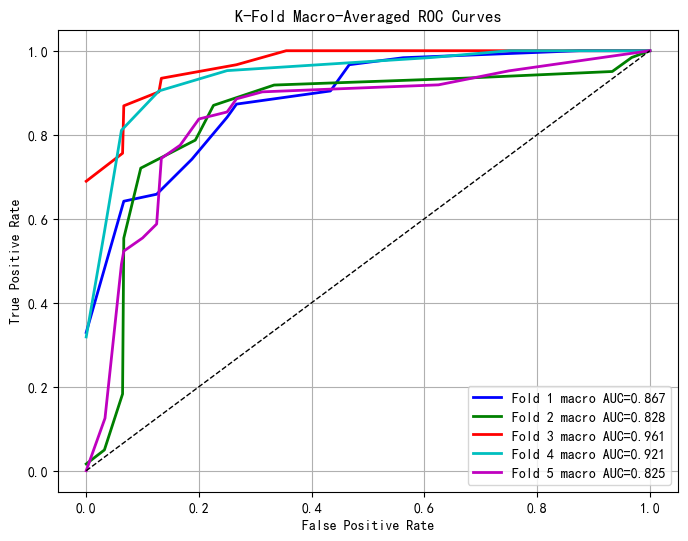

avg_shap_all_folds  (110,)

===== Overall Feature Importance (Mean SHAP) =====
              Feature  MeanSHAP
1                 age  0.847227
3      smokingHistory  0.763982
6   shortnessOfBreath  0.748543
2                 BMI  0.351082
7               cough  0.339082
4                FHRD  0.249650
5     biofuelsHistory  0.046469
0              gender  0.033745
8        constitution  0.000000
9           faceColor  0.000000
10           lipColor  0.000000
11          localFeat  0.000000
12          faceGloss  0.000000
13        tongueColor  0.000000
14        tongueShape  0.000000
15    tongueCondition  0.000000
16     coatingTexture  0.000000
17       coatingColor  0.000000


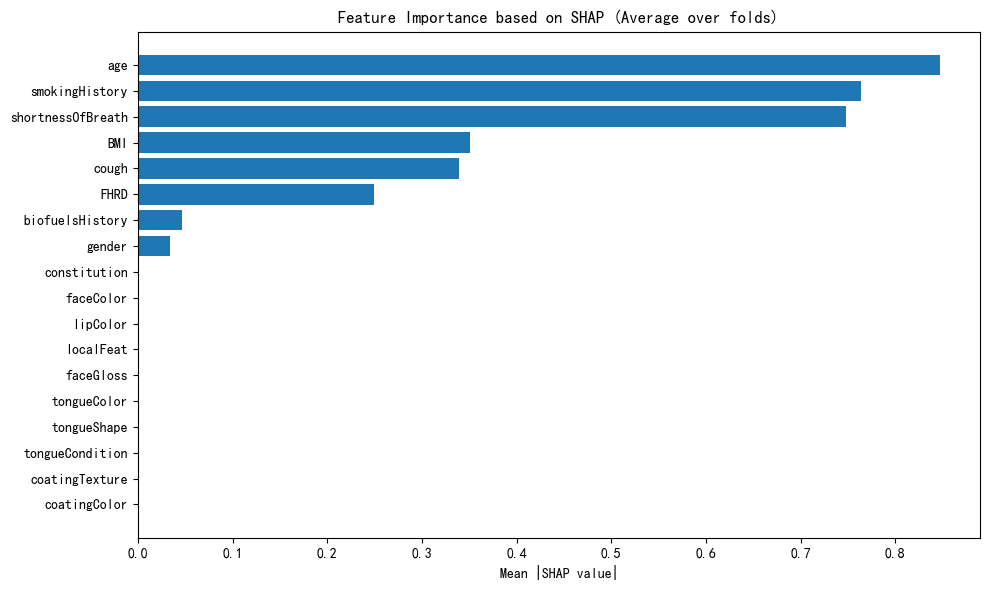


===== Overall Feature Importance (Class 0) =====
              Feature  MeanSHAP
1                 age  0.892857
3      smokingHistory  0.814661
6   shortnessOfBreath  0.809930
2                 BMI  0.369537
7               cough  0.355845
4                FHRD  0.267856
5     biofuelsHistory  0.048646
0              gender  0.035686
8        constitution  0.000000
9           faceColor  0.000000
10           lipColor  0.000000
11          localFeat  0.000000
12          faceGloss  0.000000
13        tongueColor  0.000000
14        tongueShape  0.000000
15    tongueCondition  0.000000
16     coatingTexture  0.000000
17       coatingColor  0.000000


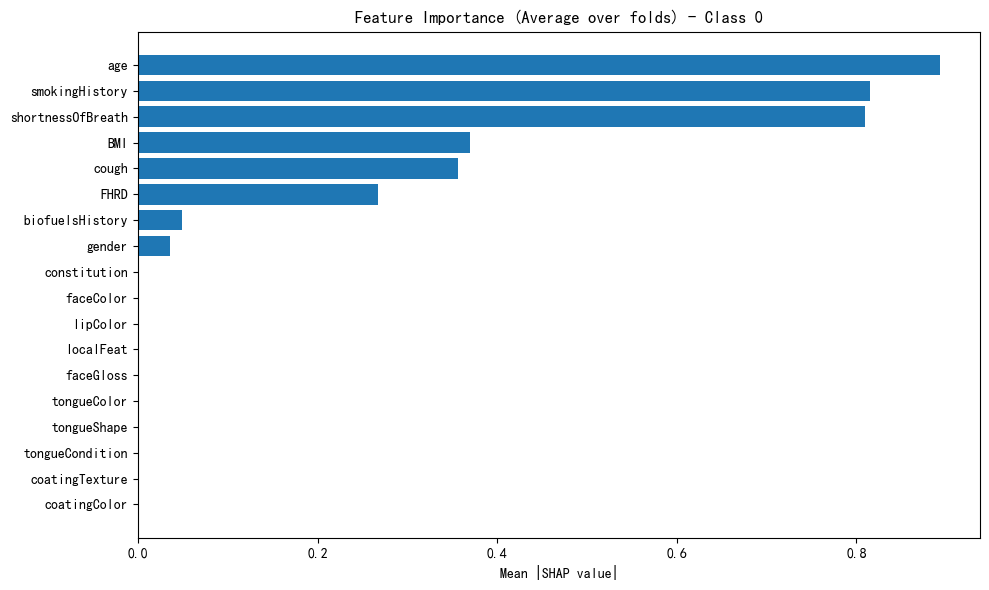


===== Overall Feature Importance (Class 1) =====
              Feature  MeanSHAP
1                 age  0.801596
3      smokingHistory  0.713303
6   shortnessOfBreath  0.687155
2                 BMI  0.332626
7               cough  0.322319
4                FHRD  0.231445
5     biofuelsHistory  0.044292
0              gender  0.031803
8        constitution  0.000000
9           faceColor  0.000000
10           lipColor  0.000000
11          localFeat  0.000000
12          faceGloss  0.000000
13        tongueColor  0.000000
14        tongueShape  0.000000
15    tongueCondition  0.000000
16     coatingTexture  0.000000
17       coatingColor  0.000000


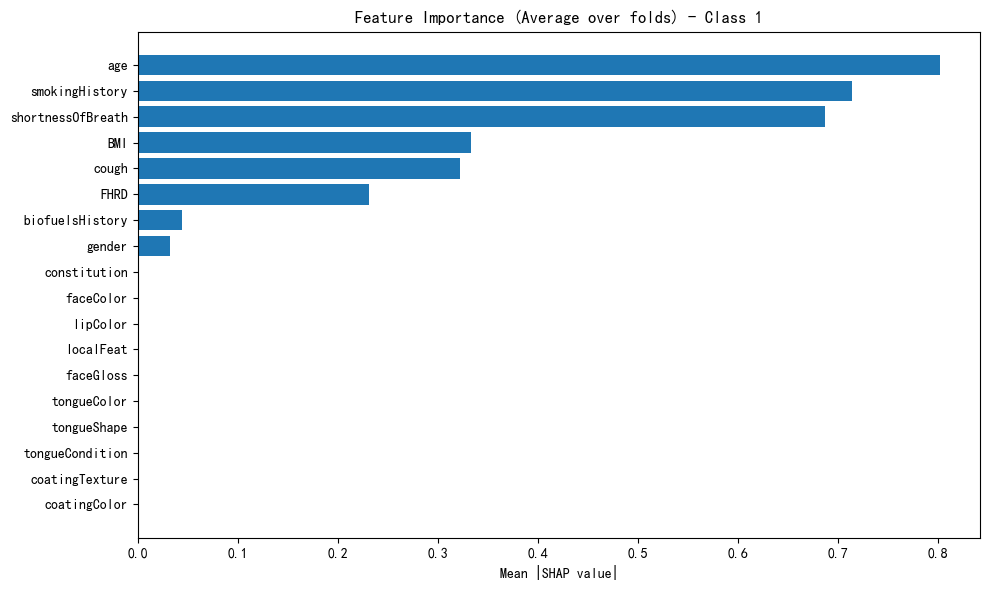

shap_values_all  (1629, 110, 2)
all_data  (1629, 110)

=== faceColor (slice=25:44) ===

=== constitution (slice=8:25) ===

=== tongueColor (slice=58:73) ===

=== tongueShape (slice=73:82) ===

=== coatingTexture (slice=88:102) ===

=== coatingColor (slice=102:109) ===

=== lipColor (slice=44:52) ===

Running M2: 现代医学+中医 | 规则=无 | lambda_logic=0.0, lambda_prior=0.0
Dataset name: M2_modern_tcm_no_rule
USE_RULE_FEATURES: False
X.shape (1629, 109)
y.shape (1629,)
label distribution: {-1: 1398, 0: 153, 1: 78}

===== Fold 1/5 =====
class_weights: tensor([ 0.7548, 14.8113], device='cuda:0')


d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=1.8004 pred_loss=1.8004 logic_loss=-0.0000 val_auc=0.848  val_acc=0.607  val_score score=0.821  best score=0.935
Epoch [20/320] | loss=0.3267 | pred_loss=0.3267 | logic_loss=0.0000
Epoch [20/320] loss=0.3267 pred_loss=0.3267 logic_loss=0.0000 val_auc=0.971  val_acc=0.821  val_score score=0.901  best score=0.940
Epoch [30/320] loss=0.1324 pred_loss=0.1324 logic_loss=-0.0000 val_auc=0.947  val_acc=0.821  val_score score=0.892  best score=0.940
Epoch [40/320] | loss=0.0270 | pred_loss=0.0270 | logic_loss=-0.0000
Epoch [40/320] loss=0.0270 pred_loss=0.0270 logic_loss=-0.0000 val_auc=0.906  val_acc=0.786  val_score score=0.865  best score=0.940
Epoch [50/320] loss=0.0329 pred_loss=0.0329 logic_loss=-0.0000 val_auc=0.959  val_acc=0.821  val_score score=0.897  best score=0.940
Epoch [60/320] | loss=0.0055 | pred_loss=0.0055 | logic_loss=-0.0000
Epoch [60/320] loss=0.0055 pred_loss=0.0055 logic_loss=-0.0000 val_auc=0.959  val_acc=0.857  val_score score=0.907  best score=0.9

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.2627 pred_loss=0.2627 logic_loss=-0.0000 val_auc=0.950  val_acc=0.536  val_score score=0.841  best score=0.942
Epoch [20/320] | loss=0.0630 | pred_loss=0.0630 | logic_loss=-0.0000
Epoch [20/320] loss=0.0630 pred_loss=0.0630 logic_loss=-0.0000 val_auc=0.872  val_acc=0.857  val_score score=0.876  best score=0.942
Epoch [30/320] loss=0.0774 pred_loss=0.0774 logic_loss=-0.0000 val_auc=0.961  val_acc=0.857  val_score score=0.912  best score=0.942
Epoch [40/320] | loss=0.0128 | pred_loss=0.0128 | logic_loss=-0.0000
Epoch [40/320] loss=0.0128 pred_loss=0.0128 logic_loss=-0.0000 val_auc=0.911  val_acc=0.929  val_score score=0.913  best score=0.942
Epoch [50/320] loss=0.0407 pred_loss=0.0407 logic_loss=-0.0000 val_auc=0.861  val_acc=0.929  val_score score=0.893  best score=0.942
Epoch [60/320] | loss=0.0379 | pred_loss=0.0379 | logic_loss=-0.0000
Epoch [60/320] loss=0.0379 pred_loss=0.0379 logic_loss=-0.0000 val_auc=0.911  val_acc=0.893  val_score score=0.902  best score=0

...

Epoch [10/320] loss=0.0899 pred_loss=0.0899 logic_loss=0.0000 val_auc=0.906  val_acc=0.929  val_score score=0.911  best score=0.881
Epoch [20/320] | loss=0.3233 | pred_loss=0.3233 | logic_loss=0.0000
Epoch [20/320] loss=0.3233 pred_loss=0.3233 logic_loss=0.0000 val_auc=0.933  val_acc=0.857  val_score score=0.870  best score=0.911
Epoch [30/320] loss=0.2166 pred_loss=0.2166 logic_loss=0.0000 val_auc=0.917  val_acc=0.929  val_score score=0.885  best score=0.953
Epoch [40/320] | loss=0.1557 | pred_loss=0.1557 | logic_loss=0.0000
Epoch [40/320] loss=0.1557 pred_loss=0.1557 logic_loss=0.0000 val_auc=0.900  val_acc=0.893  val_score score=0.868  best score=0.953
Epoch [50/320] loss=0.0132 pred_loss=0.0132 logic_loss=0.0000 val_auc=0.956  val_acc=0.929  val_score score=0.901  best score=0.953
Epoch [60/320] | loss=0.0373 | pred_loss=0.0373 | logic_loss=0.0000
Epoch [60/320] loss=0.0373 pred_loss=0.0373 logic_loss=0.0000 val_auc=0.989  val_acc=0.929  val_score score=0.914  best score=0.953
Epoc

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.1155 pred_loss=0.1155 logic_loss=-0.0000 val_auc=0.895  val_acc=0.357  val_score score=0.765  best score=0.869
Epoch [20/320] | loss=0.0253 | pred_loss=0.0253 | logic_loss=0.0000
Epoch [20/320] loss=0.0253 pred_loss=0.0253 logic_loss=0.0000 val_auc=0.830  val_acc=0.786  val_score score=0.835  best score=0.914
Epoch [30/320] loss=0.0640 pred_loss=0.0640 logic_loss=0.0000 val_auc=0.912  val_acc=0.821  val_score score=0.845  best score=0.914
Epoch [40/320] | loss=0.0304 | pred_loss=0.0304 | logic_loss=-0.0000
Epoch [40/320] loss=0.0304 pred_loss=0.0304 logic_loss=-0.0000 val_auc=0.918  val_acc=0.750  val_score score=0.826  best score=0.914
Epoch [50/320] loss=0.0332 pred_loss=0.0332 logic_loss=0.0000 val_auc=0.930  val_acc=0.821  val_score score=0.885  best score=0.914
Epoch [60/320] | loss=5.2184 | pred_loss=5.2184 | logic_loss=0.0000
Epoch [60/320] loss=5.2184 pred_loss=5.2184 logic_loss=0.0000 val_auc=0.889  val_acc=0.821  val_score score=0.835  best score=0.914
E

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.2315 pred_loss=0.2315 logic_loss=-0.0000 val_auc=0.918  val_acc=0.643  val_score score=0.827  best score=0.873
Epoch [20/320] | loss=0.0778 | pred_loss=0.0778 | logic_loss=0.0000
Epoch [20/320] loss=0.0778 pred_loss=0.0778 logic_loss=0.0000 val_auc=0.918  val_acc=0.821  val_score score=0.880  best score=0.891
Epoch [30/320] loss=0.0753 pred_loss=0.0753 logic_loss=0.0000 val_auc=0.936  val_acc=0.821  val_score score=0.887  best score=0.896
Epoch [40/320] | loss=0.0202 | pred_loss=0.0202 | logic_loss=0.0000
Epoch [40/320] loss=0.0202 pred_loss=0.0202 logic_loss=0.0000 val_auc=0.860  val_acc=0.750  val_score score=0.836  best score=0.896
Epoch [50/320] loss=0.0487 pred_loss=0.0487 logic_loss=0.0000 val_auc=0.860  val_acc=0.786  val_score score=0.846  best score=0.896
Epoch [60/320] | loss=0.0051 | pred_loss=0.0051 | logic_loss=0.0000
Epoch [60/320] loss=0.0051 pred_loss=0.0051 logic_loss=0.0000 val_auc=0.906  val_acc=0.821  val_score score=0.876  best score=0.896
Epo

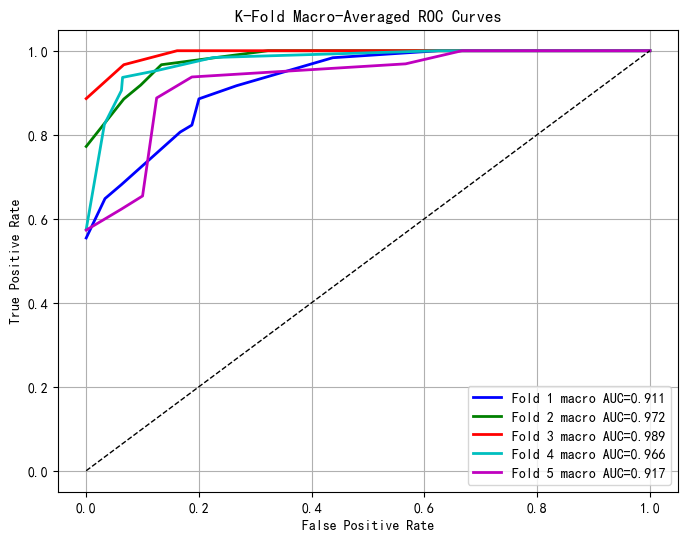

avg_shap_all_folds  (110,)

===== Overall Feature Importance (Mean SHAP) =====
              Feature  MeanSHAP
6   shortnessOfBreath  1.320331
14        tongueShape  0.966280
3      smokingHistory  0.793474
1                 age  0.713854
8        constitution  0.692053
7               cough  0.612130
17       coatingColor  0.545832
16     coatingTexture  0.531667
13        tongueColor  0.449434
10           lipColor  0.400378
9           faceColor  0.389960
12          faceGloss  0.353333
2                 BMI  0.259098
4                FHRD  0.199140
11          localFeat  0.148482
5     biofuelsHistory  0.066217
0              gender  0.025224
15    tongueCondition  0.018342


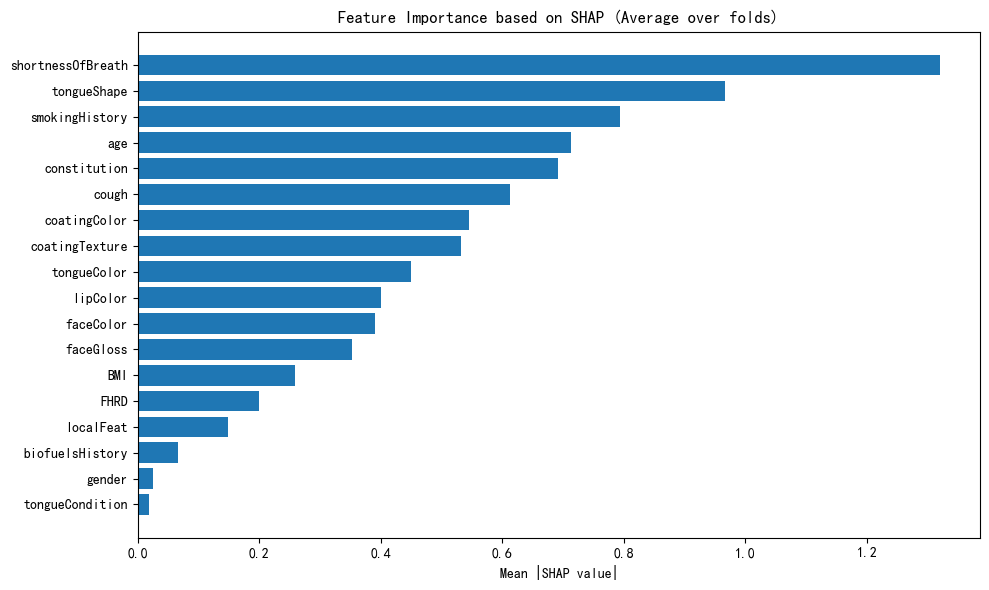


===== Overall Feature Importance (Class 0) =====
              Feature  MeanSHAP
6   shortnessOfBreath  1.213862
14        tongueShape  0.925034
3      smokingHistory  0.717817
1                 age  0.706185
8        constitution  0.669380
7               cough  0.546600
17       coatingColor  0.529676
16     coatingTexture  0.520106
13        tongueColor  0.430516
10           lipColor  0.381473
9           faceColor  0.380995
12          faceGloss  0.354980
2                 BMI  0.256194
4                FHRD  0.193888
11          localFeat  0.137752
5     biofuelsHistory  0.062576
0              gender  0.024931
15    tongueCondition  0.018236


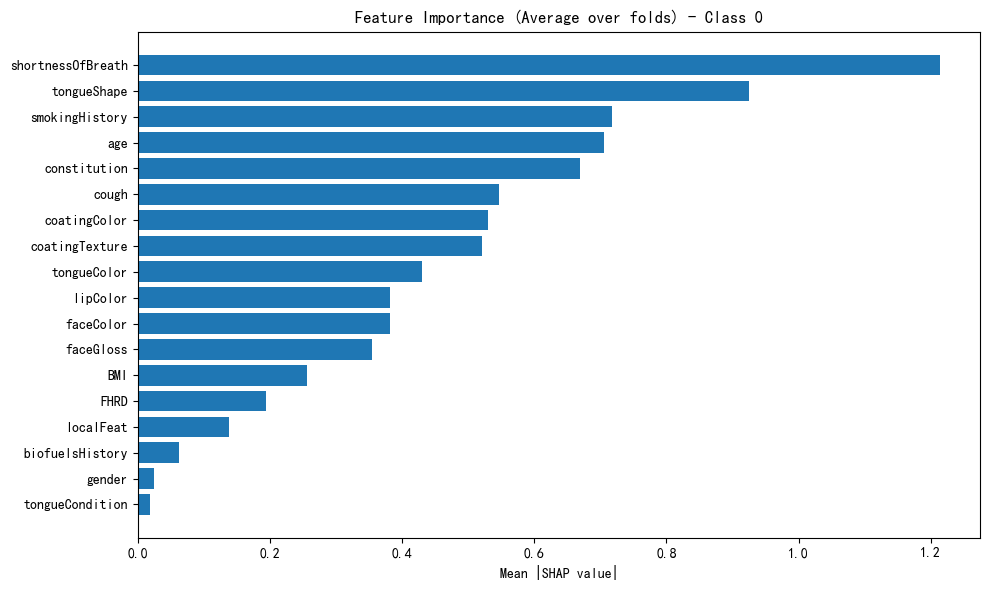


===== Overall Feature Importance (Class 1) =====
              Feature  MeanSHAP
6   shortnessOfBreath  1.426801
14        tongueShape  1.007527
3      smokingHistory  0.869131
1                 age  0.721522
8        constitution  0.714726
7               cough  0.677660
17       coatingColor  0.561988
16     coatingTexture  0.543227
13        tongueColor  0.468353
10           lipColor  0.419283
9           faceColor  0.398925
12          faceGloss  0.351685
2                 BMI  0.262001
4                FHRD  0.204392
11          localFeat  0.159212
5     biofuelsHistory  0.069857
0              gender  0.025517
15    tongueCondition  0.018447


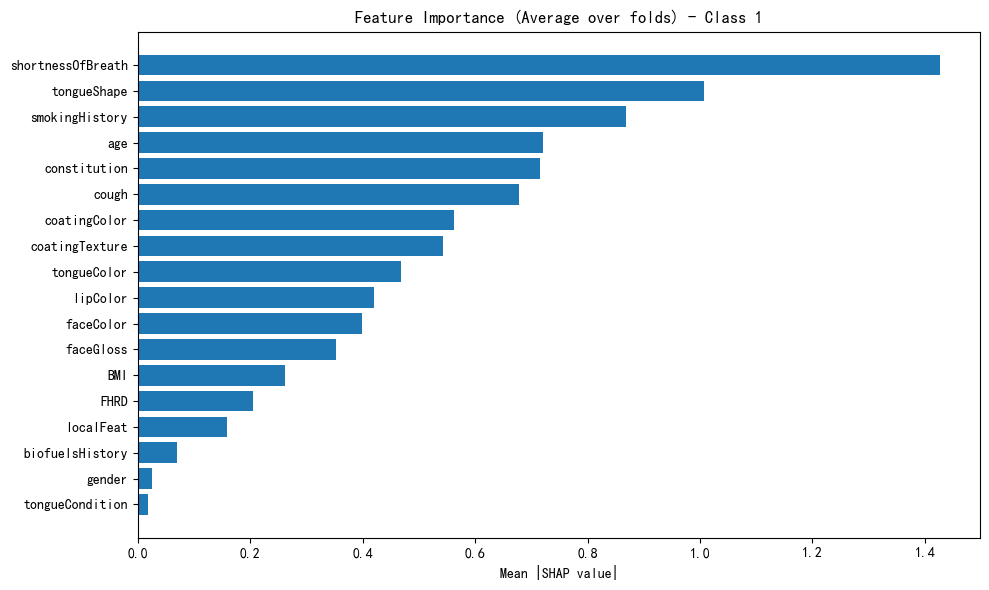

shap_values_all  (1629, 110, 2)
all_data  (1629, 110)

=== faceColor (slice=25:44) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


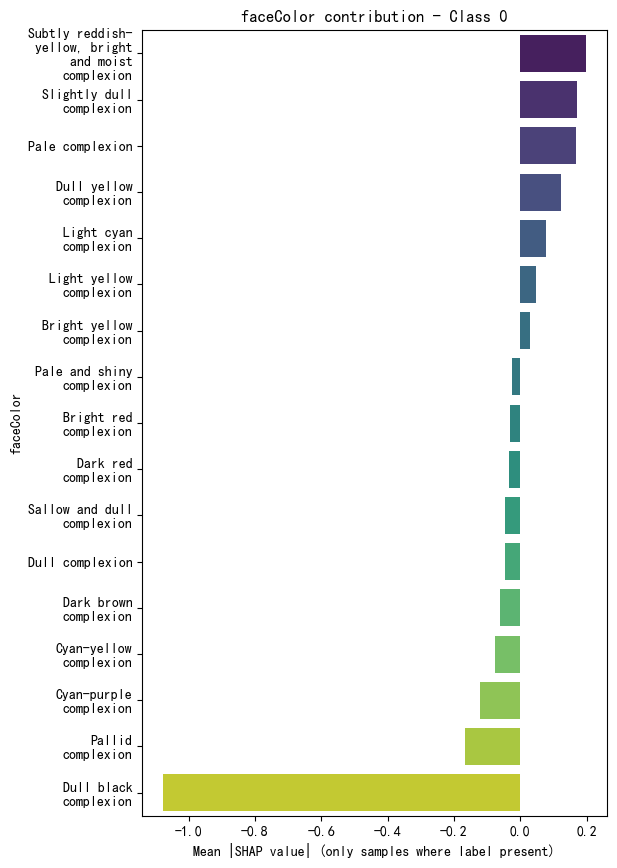

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


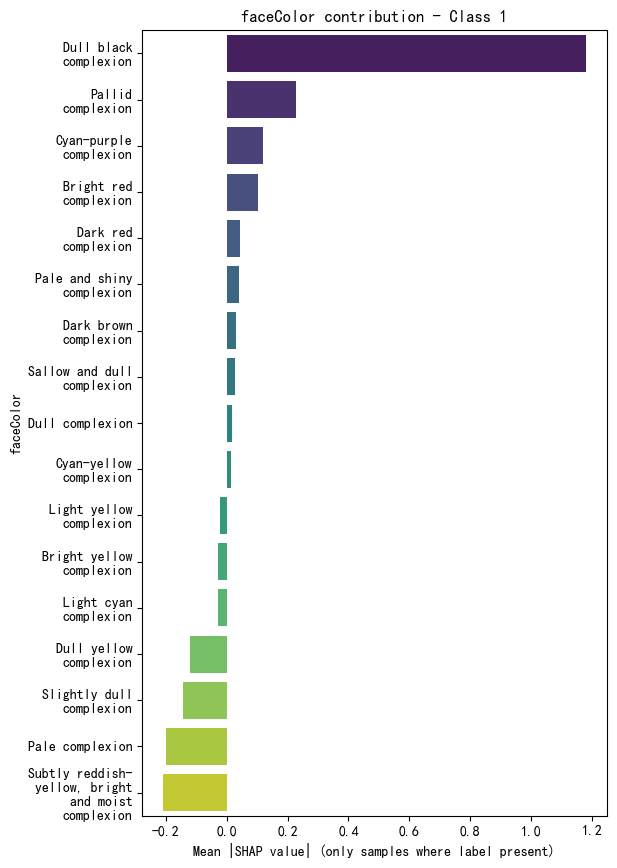

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== constitution (slice=8:25) ===


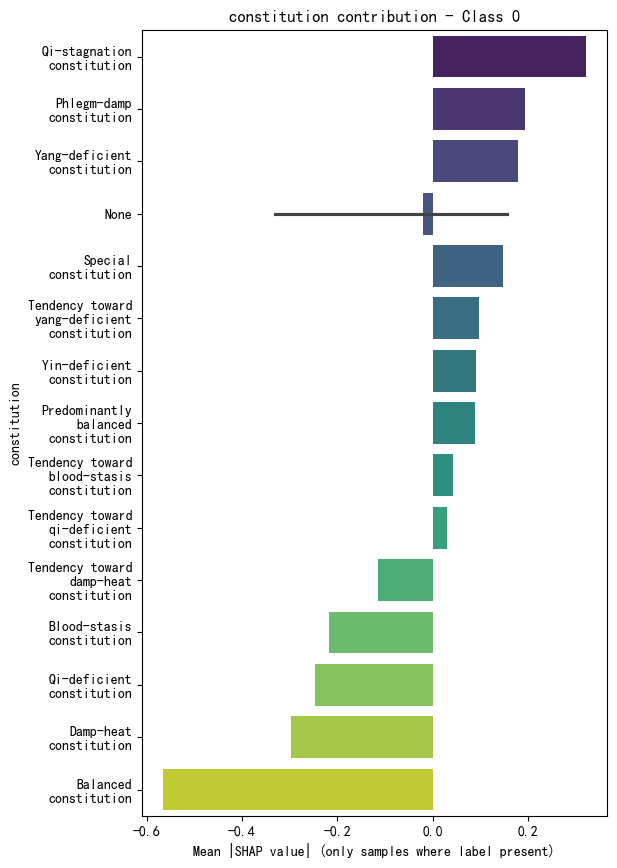

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


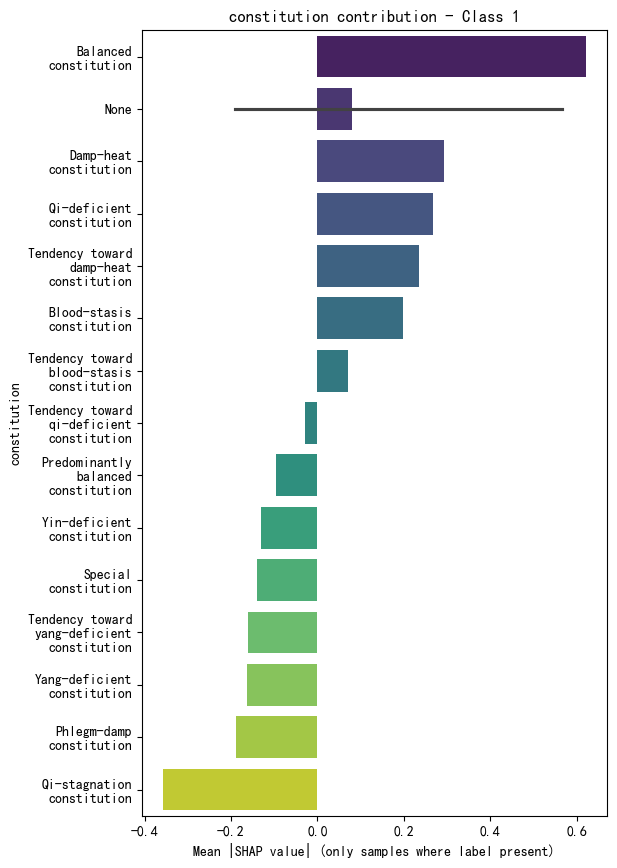

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== tongueColor (slice=58:73) ===


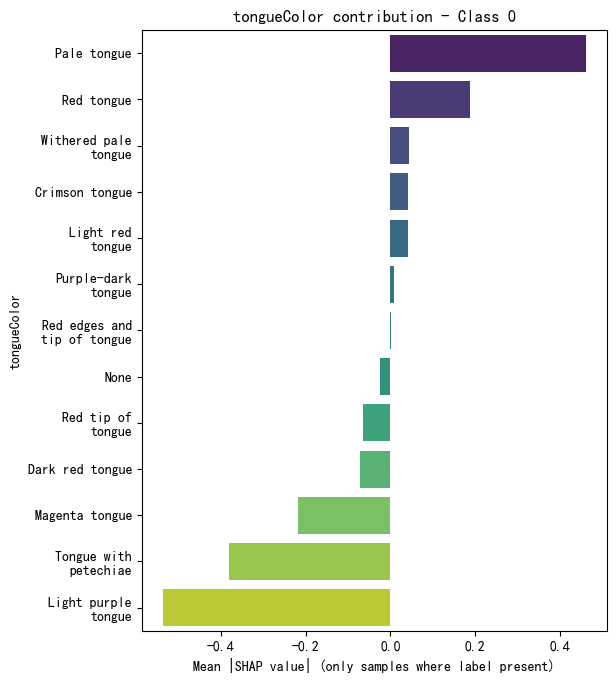

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


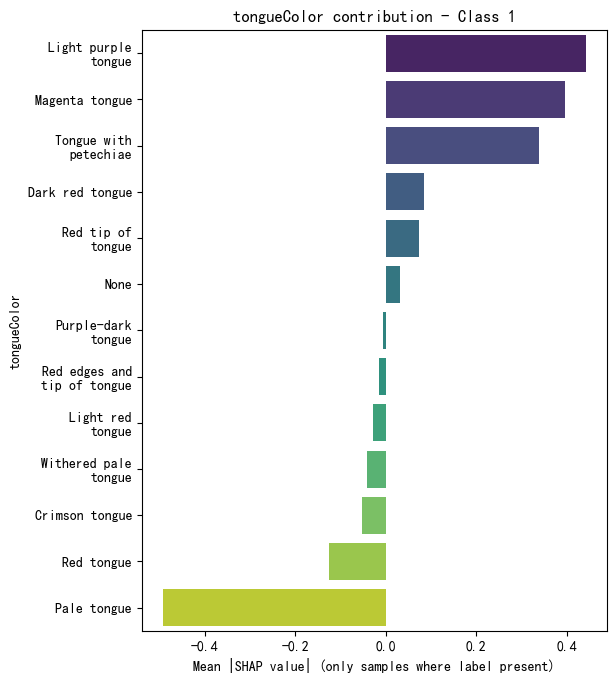

<Figure size 600x400 with 0 Axes>


=== tongueShape (slice=73:82) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


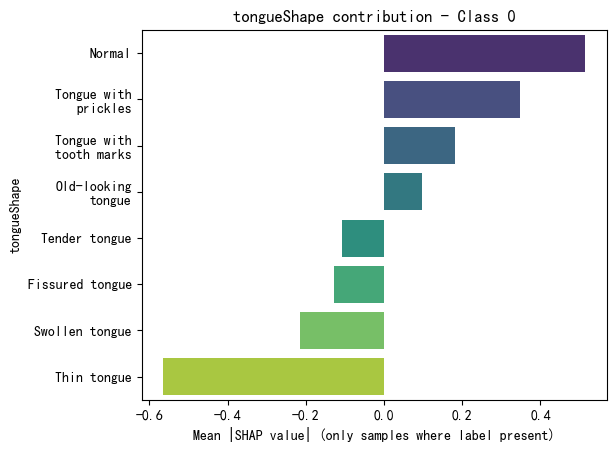

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


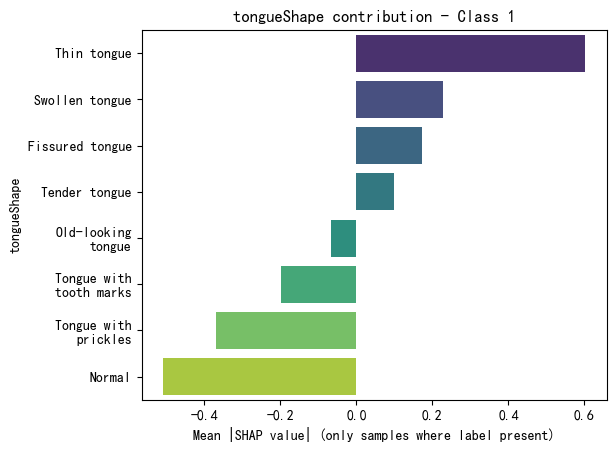

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== coatingTexture (slice=88:102) ===


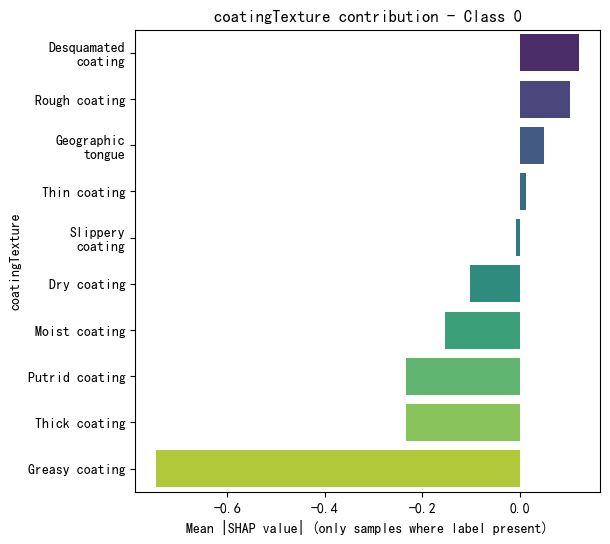

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


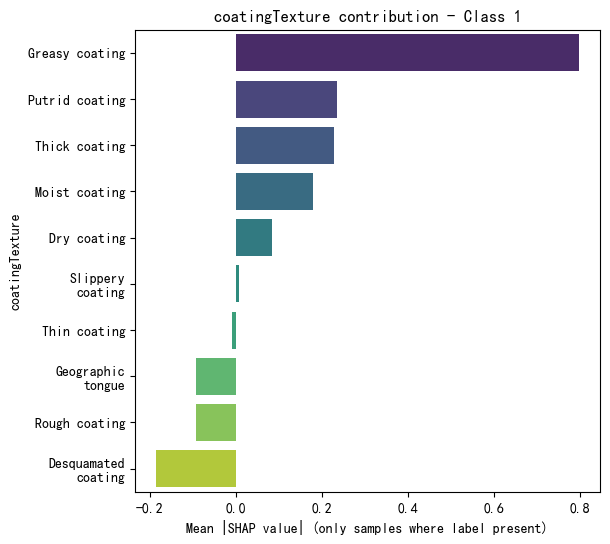

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== coatingColor (slice=102:109) ===


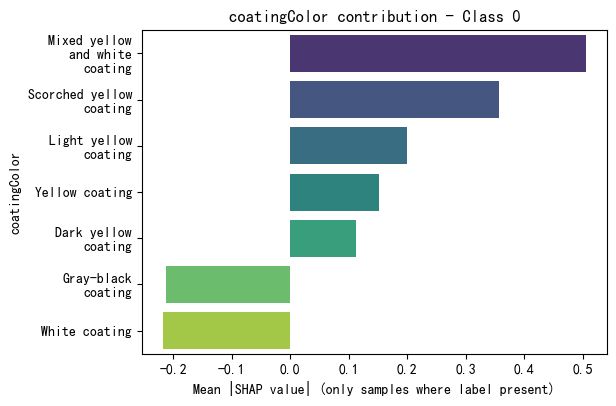

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


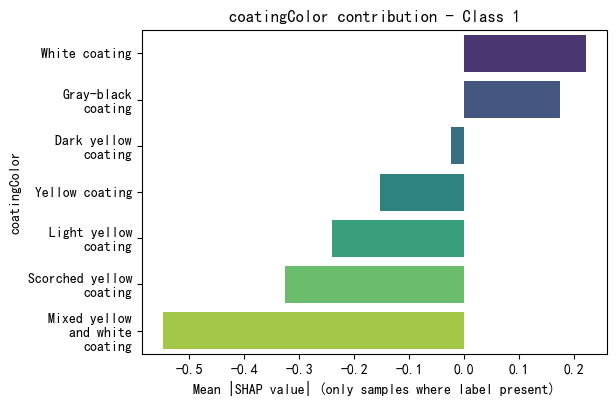

<Figure size 600x400 with 0 Axes>


=== lipColor (slice=44:52) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


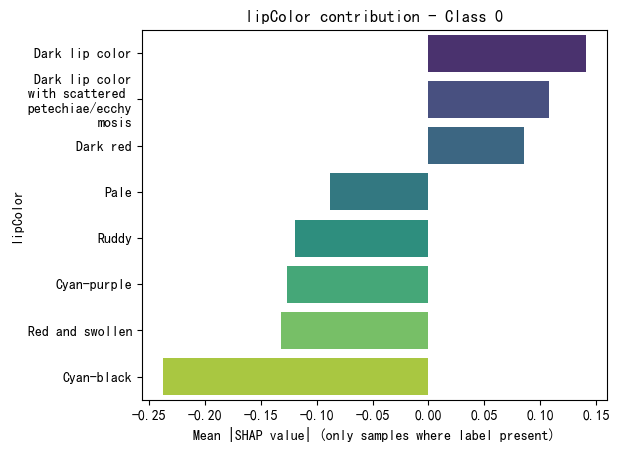

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


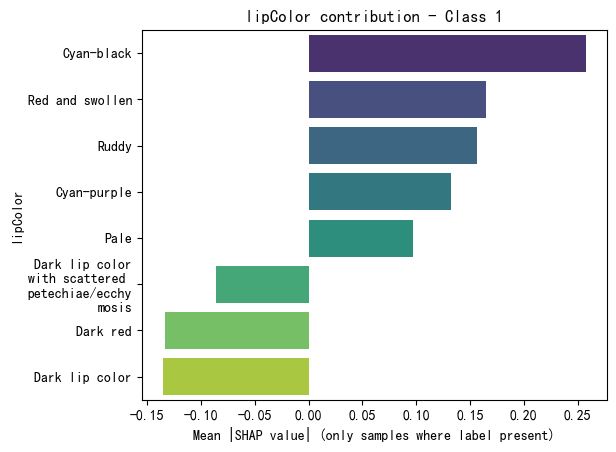

<Figure size 600x400 with 0 Axes>


Running M3: 现代医学+中医 | 规则=有规则 | lambda_logic=0.8, lambda_prior=0.7
Dataset name: M3_modern_tcm_rule
USE_RULE_FEATURES: True
X.shape (1629, 109)
y.shape (1629,)
label distribution: {-1: 1398, 0: 153, 1: 78}

===== Fold 1/5 =====
class_weights: tensor([ 0.7548, 14.8113], device='cuda:0')


d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.7035 pred_loss=0.5421 logic_loss=0.2018 val_auc=0.953  val_acc=0.929  val_score score=0.927  best score=0.930
Epoch [20/320] | loss=0.5754 | pred_loss=0.4268 | logic_loss=0.1859
Epoch [20/320] loss=0.5754 pred_loss=0.4268 logic_loss=0.1859 val_auc=0.947  val_acc=0.714  val_score score=0.860  best score=0.930
Epoch [30/320] loss=0.3606 pred_loss=0.2199 logic_loss=0.1759 val_auc=0.947  val_acc=0.643  val_score score=0.872  best score=0.930
Epoch [40/320] | loss=0.3621 | pred_loss=0.2216 | logic_loss=0.1756
Epoch [40/320] loss=0.3621 pred_loss=0.2216 logic_loss=0.1756 val_auc=0.947  val_acc=0.714  val_score score=0.860  best score=0.930
Epoch [50/320] loss=0.1986 pred_loss=0.0719 logic_loss=0.1584 val_auc=0.971  val_acc=0.643  val_score score=0.881  best score=0.930
Epoch [60/320] | loss=0.1743 | pred_loss=0.0521 | logic_loss=0.1528
Epoch [60/320] loss=0.1743 pred_loss=0.0521 logic_loss=0.1528 val_auc=0.959  val_acc=0.750  val_score score=0.875  best score=0.966
Epoc

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


...

Epoch [10/320] loss=0.5252 pred_loss=0.3857 logic_loss=0.1744 val_auc=0.956  val_acc=0.357  val_score score=0.789  best score=0.870
Epoch [20/320] | loss=0.4708 | pred_loss=0.3409 | logic_loss=0.1624
Epoch [20/320] loss=0.4708 pred_loss=0.3409 logic_loss=0.1624 val_auc=0.989  val_acc=0.857  val_score score=0.953  best score=0.948
Epoch [30/320] loss=0.3615 pred_loss=0.2227 logic_loss=0.1734 val_auc=0.900  val_acc=0.821  val_score score=0.846  best score=0.953
Epoch [40/320] | loss=0.3119 | pred_loss=0.1826 | logic_loss=0.1617
Epoch [40/320] loss=0.3119 pred_loss=0.1826 logic_loss=0.1617 val_auc=0.956  val_acc=0.857  val_score score=0.879  best score=0.953
Epoch [50/320] loss=0.3033 pred_loss=0.2030 logic_loss=0.1253 val_auc=0.900  val_acc=0.857  val_score score=0.827  best score=0.953
Epoch [60/320] | loss=0.7611 | pred_loss=0.6113 | logic_loss=0.1872
Epoch [60/320] loss=0.7611 pred_loss=0.6113 logic_loss=0.1872 val_auc=0.917  val_acc=0.857  val_score score=0.894  best score=0.953
Epoc

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.3166 pred_loss=0.1809 logic_loss=0.1696 val_auc=0.936  val_acc=0.464  val_score score=0.814  best score=0.883
Epoch [20/320] | loss=0.3820 | pred_loss=0.2429 | logic_loss=0.1739
Epoch [20/320] loss=0.3820 pred_loss=0.2429 logic_loss=0.1739 val_auc=0.924  val_acc=0.750  val_score score=0.895  best score=0.937
Epoch [30/320] loss=0.2506 pred_loss=0.1176 logic_loss=0.1663 val_auc=0.947  val_acc=0.821  val_score score=0.892  best score=0.941
Epoch [40/320] | loss=0.1873 | pred_loss=0.0426 | logic_loss=0.1808
Epoch [40/320] loss=0.1873 pred_loss=0.0426 logic_loss=0.1808 val_auc=0.947  val_acc=0.750  val_score score=0.871  best score=0.962
Epoch [50/320] loss=0.2095 pred_loss=0.0425 logic_loss=0.2088 val_auc=0.965  val_acc=0.857  val_score score=0.943  best score=0.972
Epoch [60/320] | loss=1.1079 | pred_loss=0.9612 | logic_loss=0.1834
Epoch [60/320] loss=1.1079 pred_loss=0.9612 logic_loss=0.1834 val_auc=0.971  val_acc=0.857  val_score score=0.912  best score=0.972
Epoc

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.5351 pred_loss=0.3876 logic_loss=0.1844 val_auc=0.912  val_acc=0.750  val_score score=0.857  best score=0.863
Epoch [20/320] | loss=0.3567 | pred_loss=0.2210 | logic_loss=0.1697
Epoch [20/320] loss=0.3567 pred_loss=0.2210 logic_loss=0.1697 val_auc=0.930  val_acc=0.857  val_score score=0.896  best score=0.896
Epoch [30/320] loss=0.6552 pred_loss=0.5063 logic_loss=0.1861 val_auc=0.795  val_acc=0.893  val_score score=0.819  best score=0.905
Epoch [40/320] | loss=0.4389 | pred_loss=0.2899 | logic_loss=0.1862
Epoch [40/320] loss=0.4389 pred_loss=0.2899 logic_loss=0.1862 val_auc=0.936  val_acc=0.821  val_score score=0.887  best score=0.920
Epoch [50/320] loss=0.6725 pred_loss=0.5251 logic_loss=0.1842 val_auc=0.959  val_acc=0.821  val_score score=0.897  best score=0.920
Epoch [60/320] | loss=0.4522 | pred_loss=0.2864 | logic_loss=0.2073
Epoch [60/320] loss=0.4522 pred_loss=0.2864 logic_loss=0.2073 val_auc=0.959  val_acc=0.929  val_score score=0.929  best score=0.920
Epoc

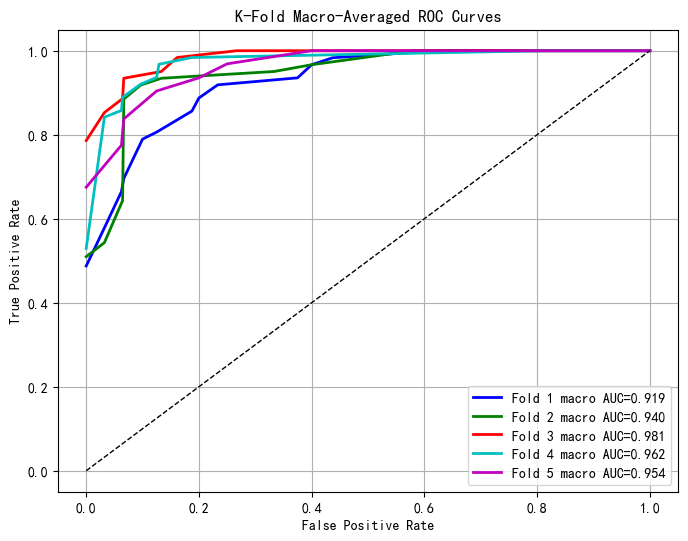

avg_shap_all_folds  (110,)

===== Overall Feature Importance (Mean SHAP) =====
              Feature  MeanSHAP
6   shortnessOfBreath  0.681455
1                 age  0.555860
14        tongueShape  0.475723
3      smokingHistory  0.441195
8        constitution  0.413684
17       coatingColor  0.386544
13        tongueColor  0.268691
16     coatingTexture  0.262356
7               cough  0.237254
10           lipColor  0.225768
2                 BMI  0.214327
9           faceColor  0.206293
12          faceGloss  0.144622
4                FHRD  0.129611
11          localFeat  0.049387
5     biofuelsHistory  0.048233
0              gender  0.021455
15    tongueCondition  0.009868


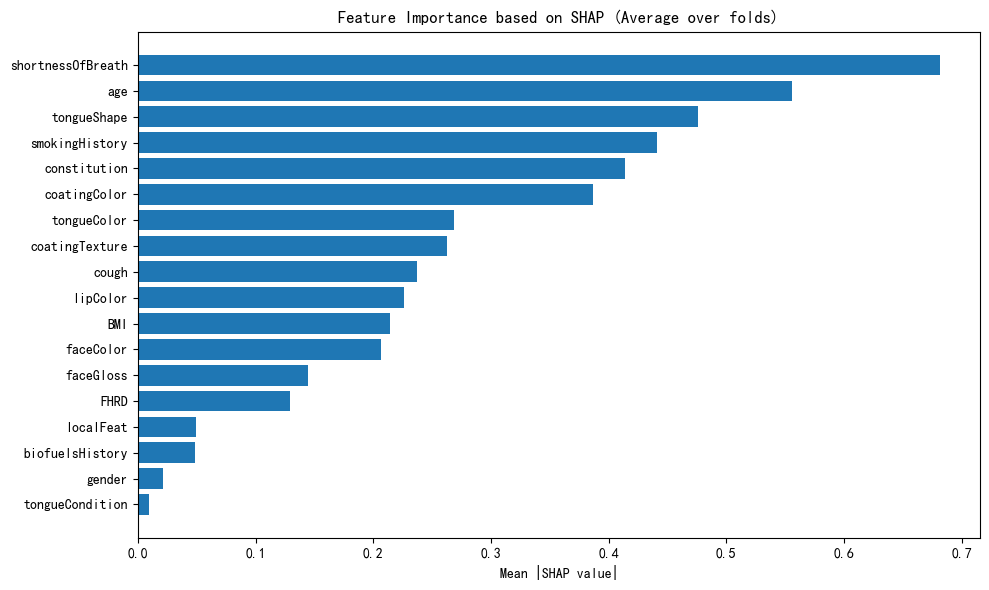


===== Overall Feature Importance (Class 0) =====
              Feature  MeanSHAP
6   shortnessOfBreath  0.669271
1                 age  0.545350
14        tongueShape  0.455796
3      smokingHistory  0.416153
8        constitution  0.394952
17       coatingColor  0.365697
16     coatingTexture  0.253207
13        tongueColor  0.237262
10           lipColor  0.234240
7               cough  0.219006
9           faceColor  0.208595
2                 BMI  0.206665
12          faceGloss  0.150886
4                FHRD  0.119358
11          localFeat  0.047134
5     biofuelsHistory  0.046418
0              gender  0.020789
15    tongueCondition  0.009446


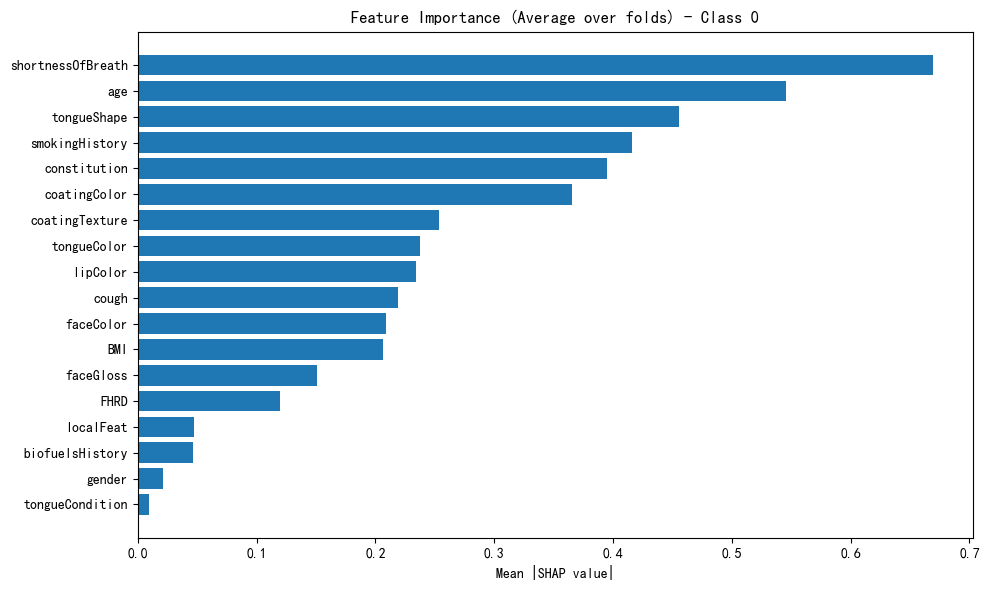


===== Overall Feature Importance (Class 1) =====
              Feature  MeanSHAP
6   shortnessOfBreath  0.693639
1                 age  0.566371
14        tongueShape  0.495650
3      smokingHistory  0.466237
8        constitution  0.432416
17       coatingColor  0.407392
13        tongueColor  0.300119
16     coatingTexture  0.271505
7               cough  0.255503
2                 BMI  0.221989
10           lipColor  0.217297
9           faceColor  0.203991
4                FHRD  0.139865
12          faceGloss  0.138358
11          localFeat  0.051641
5     biofuelsHistory  0.050048
0              gender  0.022122
15    tongueCondition  0.010290


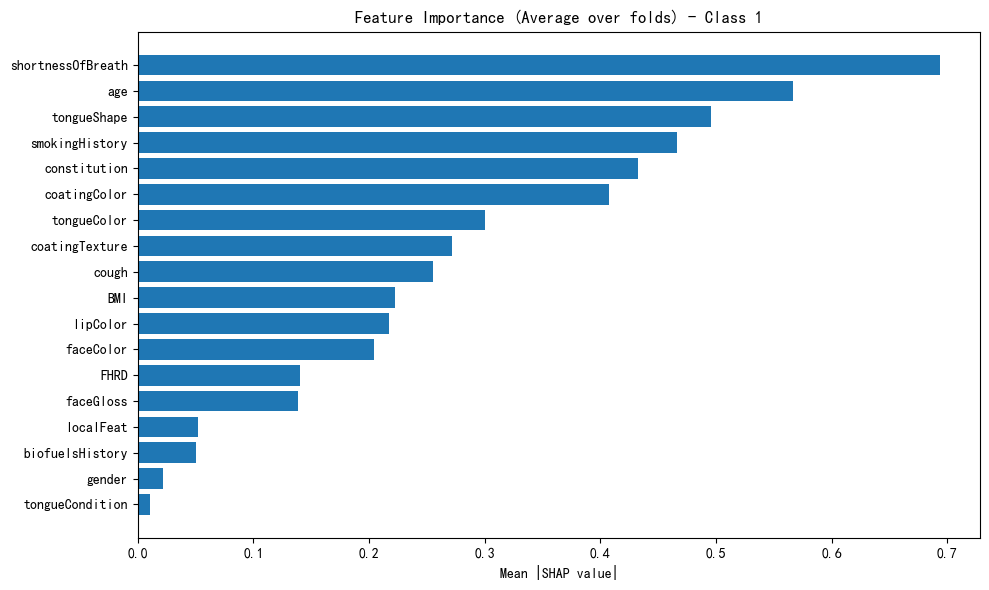

shap_values_all  (1629, 110, 2)
all_data  (1629, 110)

=== faceColor (slice=25:44) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


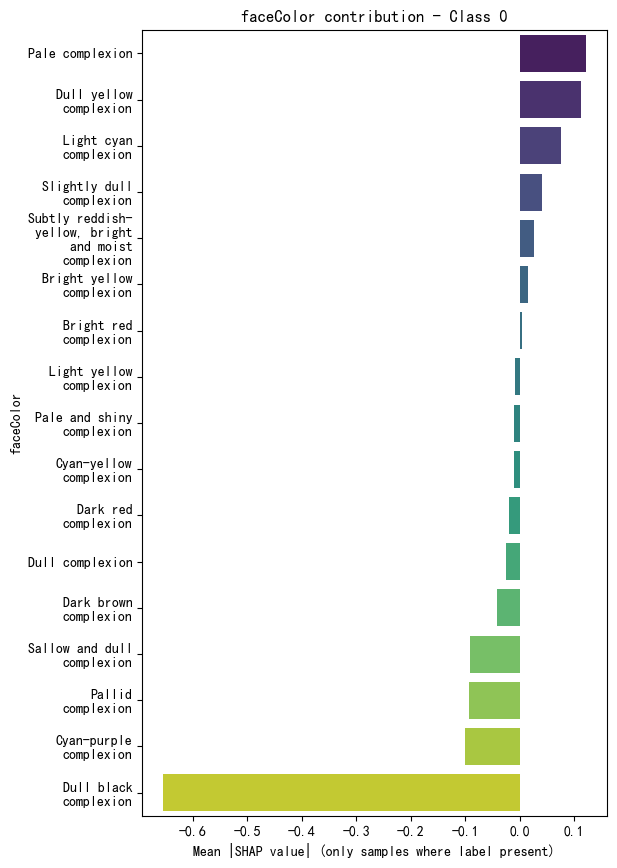

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


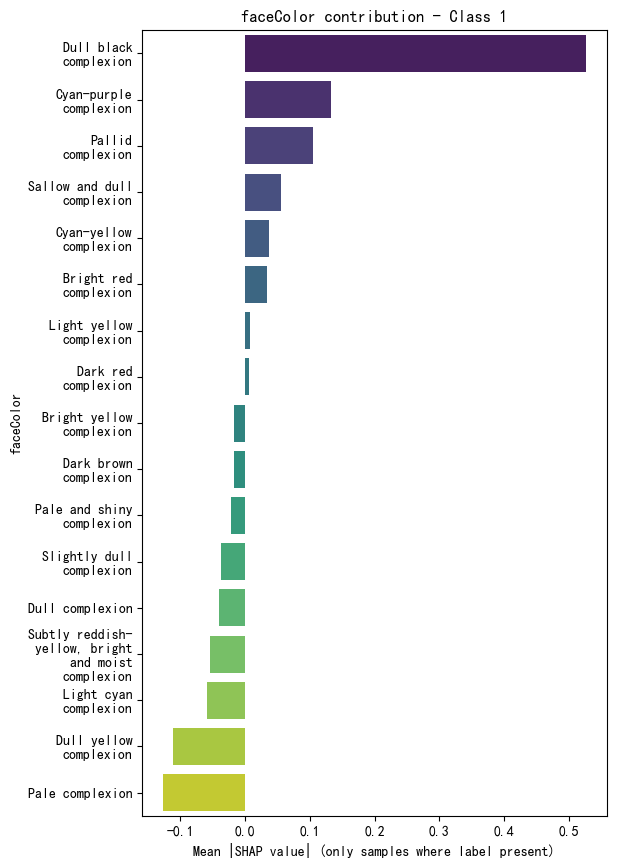

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== constitution (slice=8:25) ===


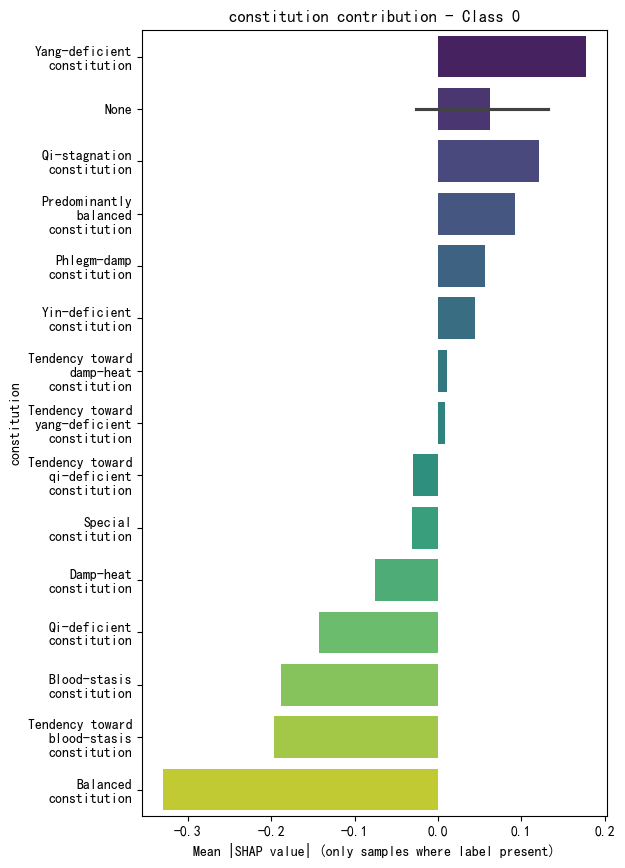

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


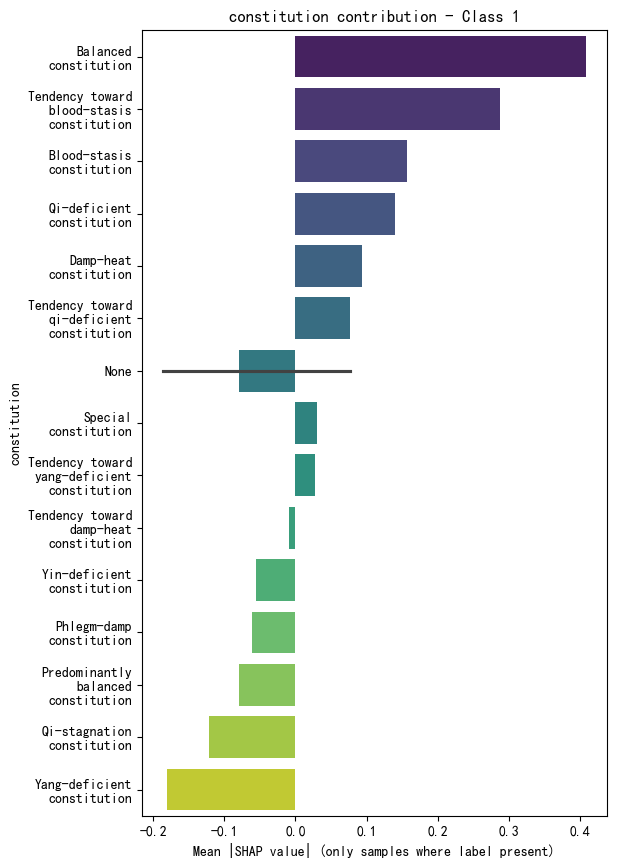

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== tongueColor (slice=58:73) ===


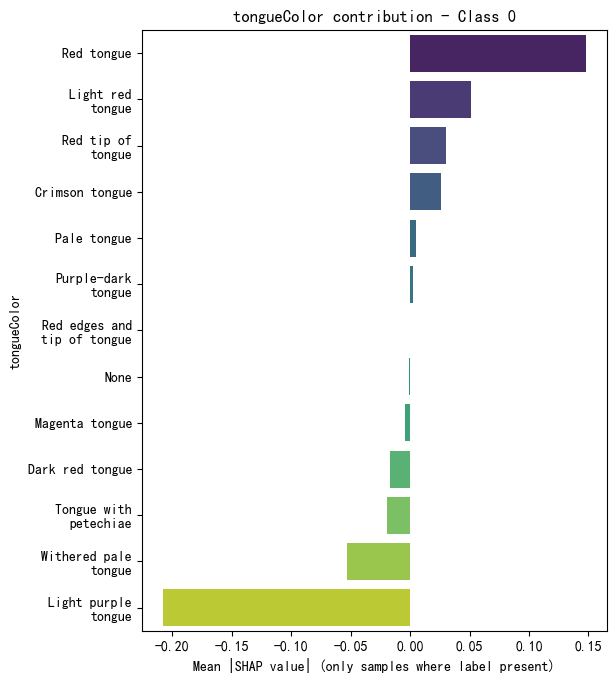

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


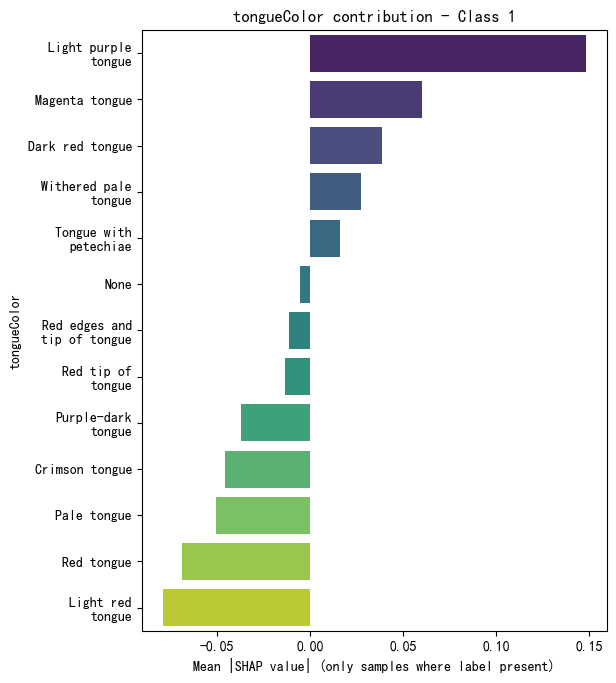

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== tongueShape (slice=73:82) ===


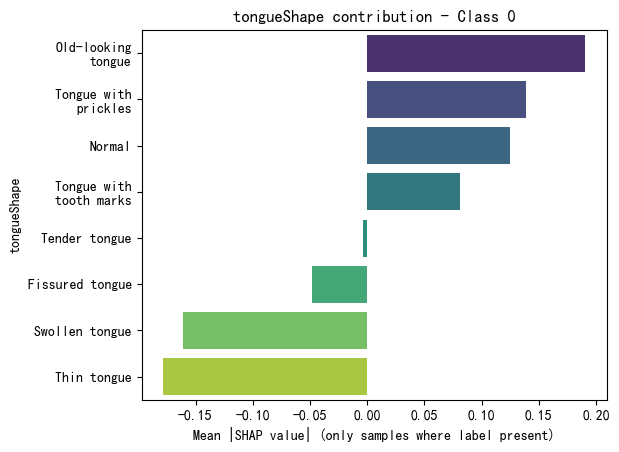

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


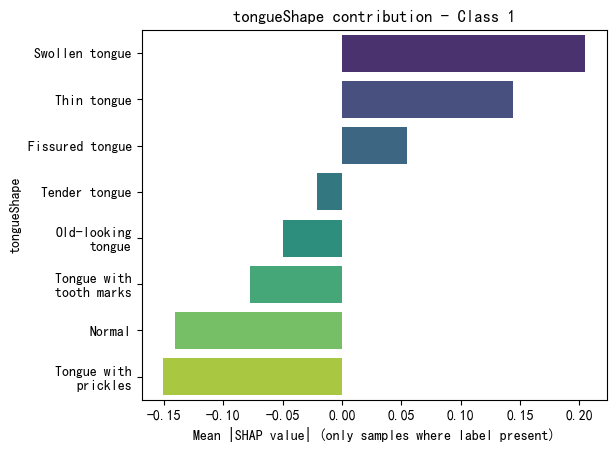

<Figure size 600x400 with 0 Axes>


=== coatingTexture (slice=88:102) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


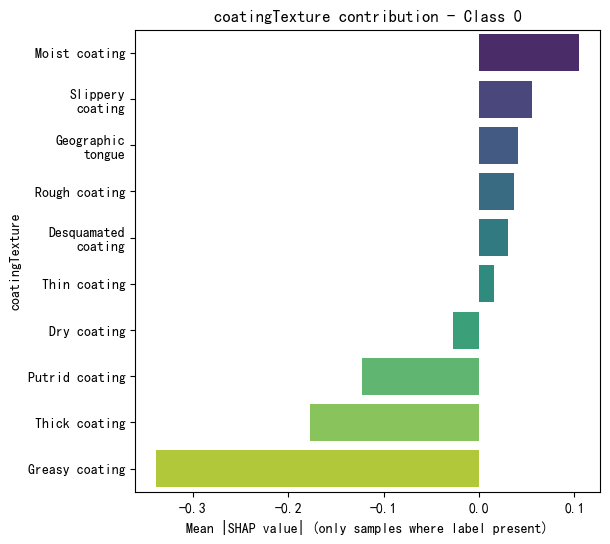

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


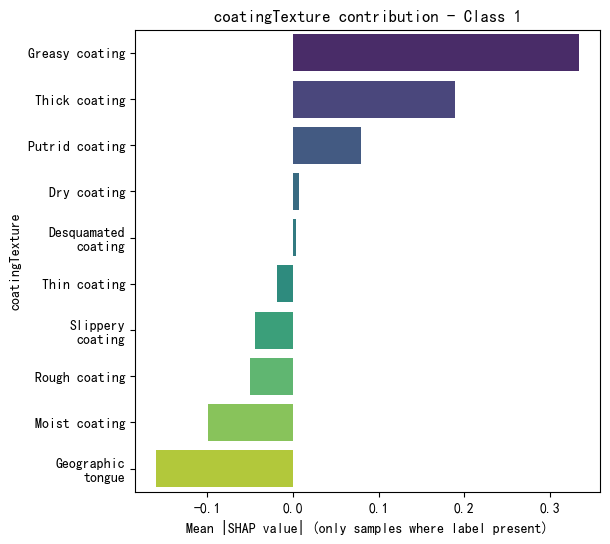

<Figure size 600x400 with 0 Axes>


=== coatingColor (slice=102:109) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


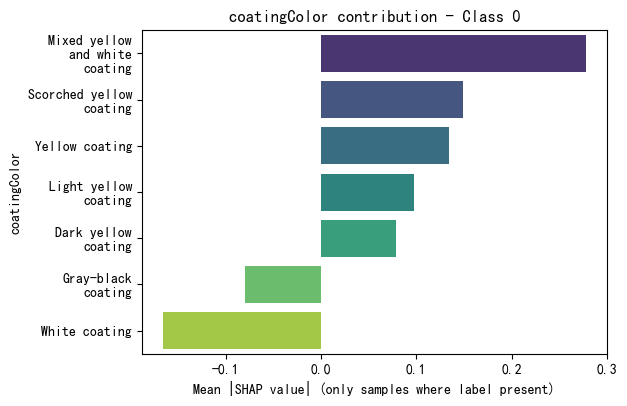

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


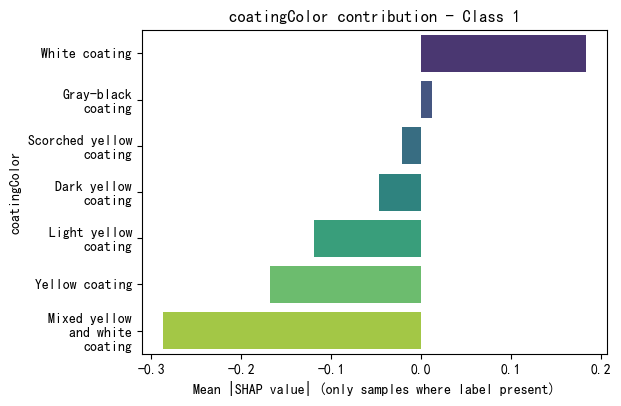

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== lipColor (slice=44:52) ===


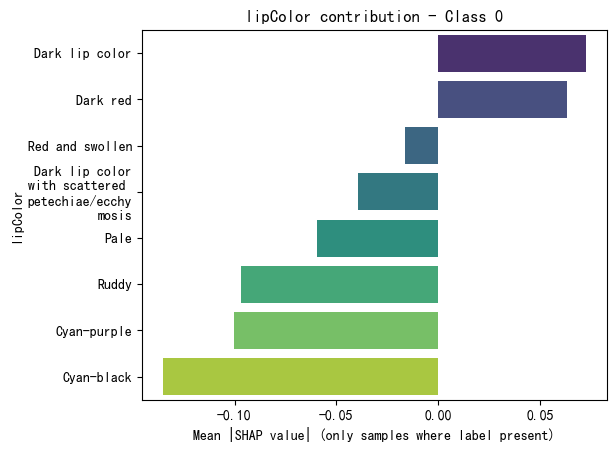

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_19252\1066339612.py:1165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


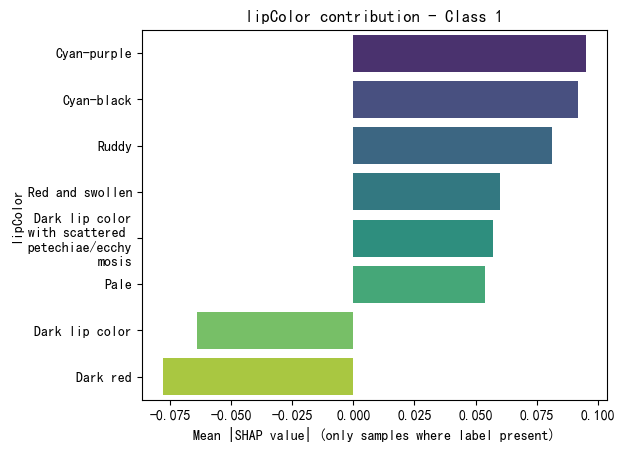

<Figure size 600x400 with 0 Axes>


----------------------------------------------------------------------------------------------------
当前实验为 M3，开始计算规则激活率和违反率...
----------------------------------------------------------------------------------------------------
M3_logic_rules 已保存：.\M3_logic_rules_activation_violation.xlsx

M3_logic_rules
       report_name  rule_id                                   rule_name  \
0   M3_logic_rules        0                     L0_age_high_to_abnormal   
1   M3_logic_rules        1                        L1_smoke_to_abnormal   
2   M3_logic_rules        2         L2_age_high_shortbreath_to_abnormal   
3   M3_logic_rules        3                      L3_biofuel_to_abnormal   
4   M3_logic_rules        4                    L4_copd_sq_low_to_normal   
5   M3_logic_rules        5          L5_cough_white_coating_to_abnormal   
6   M3_logic_rules        6              L6_fat_teeth_white_to_abnormal   
7   M3_logic_rules        7  L7_fat_teeth_white_shortbreath_to_abnormal   
8   M3_logic_rules

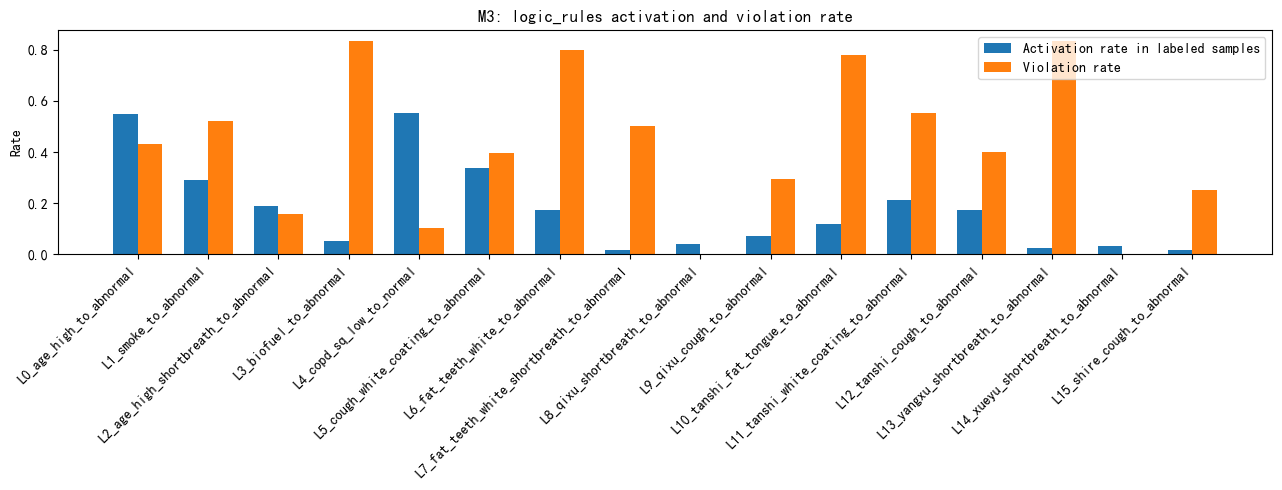

M3_get_rule_truths2 已保存：.\M3_get_rule_truths2_activation_violation.xlsx

M3_get_rule_truths2
           report_name  rule_id         rule_name    target  mean_activation  \
0  M3_get_rule_truths2        0       T0_age_high  abnormal         0.399345   
1  M3_get_rule_truths2        1          T1_smoke  abnormal         0.265018   
2  M3_get_rule_truths2        2   T2_short_breath  abnormal         0.225564   
3  M3_get_rule_truths2        3        T3_biofuel  abnormal         0.152397   
4  M3_get_rule_truths2        4    T4_copd_sq_low    normal         0.774683   
5  M3_get_rule_truths2        5          T5_cough  abnormal         0.265070   
6  M3_get_rule_truths2        6     T6_tongue_fat  abnormal         0.467597   
7  M3_get_rule_truths2        7  T7_coating_white  abnormal         0.517867   
8  M3_get_rule_truths2        8   T8_tongue_teeth  abnormal         0.755284   

   activation_rate_all  activation_rate_labeled  n_active_all  \
0             0.405770                 0.

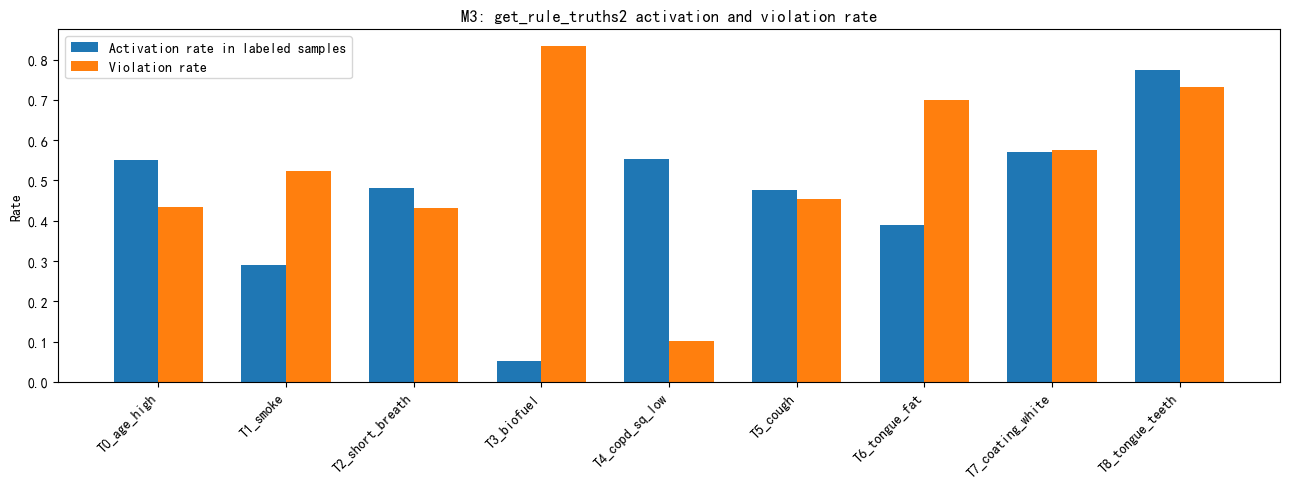


两套规则统计完成
logic_rules 报告：.\M3_logic_rules_activation_violation.xlsx
get_rule_truths2 报告：.\M3_get_rule_truths2_activation_violation.xlsx
合并报告：.\M3_dual_rule_reports.xlsx

===== M1/M2/M3 最小改动版结果 =====
   实验       特征   规则 训练/测试方式            ACC            AUC             F1  \
0  M1     现代医学    无   新数据5折  0.805 ± 0.046  0.880 ± 0.053  0.793 ± 0.045   
1  M2  现代医学+中医    无   新数据5折  0.857 ± 0.051  0.951 ± 0.031  0.844 ± 0.058   
2  M3  现代医学+中医  有规则   新数据5折  0.853 ± 0.043  0.951 ± 0.021  0.844 ± 0.044   

            Sens           Spec  
0  0.833 ± 0.064  0.790 ± 0.076  
1  0.848 ± 0.121  0.863 ± 0.032  
2  0.924 ± 0.073  0.817 ± 0.044  

===== Paired stratified bootstrap AUC comparisons (pooled OOF predictions) =====
Comparison   N  N_positive  N_negative  Threshold  Bootstrap_iterations  AUC_first  AUC_second  Delta_AUC  AUC_CI_95_low  AUC_CI_95_high  AUC_P_two_sided  ACC_first  ACC_second  Delta_ACC  ACC_CI_95_low  ACC_CI_95_high  ACC_P_two_sided  Sensitivity_first  Sensitivity_second  De

In [8]:
#深度神经网络
import shap
import matplotlib.pyplot as plt
import torch.optim as optim
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from itertools import cycle
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from copy import deepcopy
import os, random
import numpy as np
import textwrap

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # 让 CUDA 尽量 deterministic（会稍慢一点）
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

categorical_features = ["faceColor", "constitution", "tongueColor", "tongueShape", "coatingTexture", "coatingColor", "lipColor"]
feature_mappings = {
    "faceColor": 面色_mapping,
    "constitution": 体质_mapping,
    "tongueColor": 舌色_mapping,
    "tongueShape": 舌形_mapping,
    "coatingTexture": 苔质_mapping,  # 或者根据你数据命名
    "coatingColor" : 苔色_mapping,
    "lipColor" : 唇色_mapping
}
feature_names = [
    "gender", "age",  "BMI", "smokingHistory", "FHRD", "biofuelsHistory", "shortnessOfBreath", 'cough', #"COPD-SQ Score",#
    "constitution", "faceColor", "lipColor", "localFeat", "faceGloss", "tongueColor", "tongueShape", 'tongueCondition', "coatingTexture", "coatingColor"
]

bins_dict = {'BMI':[0,18.5,24,28,100],
             'smokingHistory':[1,2,3,4]
            } 

plt.rcParams['font.sans-serif'] = ['SimHei']   # 或者 ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示问题

from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, kruskal

categorical_mappings = {
    'constitution': 体质_mapping,
    'faceColor': 面色_mapping,
    'lipColor': 唇色_mapping,
    'localFeat': 局部特征_mapping,
    'faceGloss': 面部光泽_mapping,
    'tongueColor': 舌色_mapping,
    'tongueShape': 舌形_mapping,
    'tongueCondition': 舌态_mapping,
    'coatingTexture': 苔质_mapping,
    'coatingColor': 苔色_mapping,
}

def generate_baseline_table_multilabel_with_significance(dataset,
                                                         categorical_features_mapping,
                                                         group_label='isCopd'):
    """
    生成带组间显著性检验的基线表（Table 1）

    参数：
    - dataset: list，每个元素是包含特征字典的样本
    - categorical_features_mapping: dict，key=特征名, value=映射字典（用于decode）
    - group_label: 分组标签列名（默认 isCopd）
    """

    all_data = []
    for i in range(len(dataset)):
        item = dataset[i]
        row = {}

        # 连续特征
        row['age'] = item['age'].item()
        row['BMI'] = item['BMI'].item()
        #row['COPD-SQ Score'] = item['copdSQ'].item()
        row['FHRD'] = item['FHRD'].item()
        
        row['smokingHistory'] = item['smokingHistory'].item()
        row['biofuelsHistory'] = item['biofuelsHistory'].item()
        row['shortnessOfBreath'] = item['shortnessOfBreath'].item()

        # 分类特征（bitwise编码）
        row['gender'] = item['gender'].item()
        for feat, mapping in categorical_features_mapping.items():
            row[feat] = multihot_to_bitmask(item[feat], mapping) #item[feat].item()

        # 标签
        ##row[group_label] = item[group_label].item()

        # 标签：原始 isCopd ∈ {-1,0,1,2,3} → 新标签 ∈ {-1,0,1}
        raw_label = item[group_label].item()
        if raw_label < 0:
            new_label = -1      # 无肺功能/未标注
        elif raw_label == 0:
            new_label = 0       # 正常
        else:
            new_label = 1       # 1/2/3 统统归为「有通气功能障碍」
        row[group_label] = new_label
        
        all_data.append(row)

    df = pd.DataFrame(all_data)
    total = len(df)
    print("df.columns", df.columns)

    # --- 定义变量类型 ---
    continuous_features = ['age', 'BMI']#, 'COPD-SQ Score']
    categorical_basic = ['gender', 'smokingHistory', 'FHRD', 'biofuelsHistory', 'shortnessOfBreath']

    summary = {}

    # --- 各组分开 ---
    groups = sorted(df[group_label].unique())
    group_names = [f"{group_label}={g}" for g in groups]

    for feat in df.columns:
        if feat == group_label:
            continue

        if feat in continuous_features:
            # 连续特征：报告均值±标准差
            descs = []
            values_by_group = []
            for g in groups:
                vals = df.loc[df[group_label]==g, feat].dropna()
                if len(vals) > 0:
                    descs.append(f"{vals.mean():.1f} ± {vals.std():.1f}")
                    values_by_group.append(vals)
                else:
                    descs.append("NA")

            # 多组 -> ANOVA，二组 -> t 检验
            if len(groups) > 2:
                stat, p = f_oneway(*values_by_group)
            else:
                p = stats.ttest_ind(values_by_group[0], values_by_group[1], equal_var=False)[1]

        elif feat in categorical_basic:
            # 生成列联表
            contingency = pd.crosstab(df[feat], df[group_label])
            # 卡方检验
            try:
                chi2, p, dof, ex = chi2_contingency(contingency)
            except:
                p = 1.0

            # 统计频率
            label_counts = {}
            for g in groups:
                sub = df[df[group_label] == g]
                total_g = len(sub)
                counts = sub[feat].value_counts()
                label_counts[g] = " | ".join([
                    f"{lbl} {cnt}({cnt/total_g*100:.1f}%)"
                    for lbl, cnt in counts.items()
                ])

        else:
            # 分类特征
            mapping = categorical_features_mapping.get(feat, None)
            if mapping is None:
                continue

            # 解码 bitwise
            decoded_lists = df[feat].apply(lambda x: decode_labels(int(x), mapping))
            df_decoded = df.copy()
            df_decoded[feat] = decoded_lists

            # 计算各标签频率
            label_counts = {}
            for g in groups:
                sub = df_decoded[df_decoded[group_label]==g]
                flat = [l for L in sub[feat] for l in L]
                total_g = len(sub)
                counts = pd.Series(flat).value_counts()
                label_counts[g] = " | ".join([
                    f"{lbl} {cnt}({cnt/total_g*100:.1f}%)"
                    for lbl, cnt in counts.items()
                ])

            # 构造列联表
            contingency = []
            labels_union = sorted({l for L in df_decoded[feat] for l in L})
            for lbl in labels_union:
                row_ct = []
                for g in groups:
                    sub = df_decoded[df_decoded[group_label]==g]
                    flat = [l for L in sub[feat] for l in L]
                    row_ct.append(flat.count(lbl))
                contingency.append(row_ct)

            # 卡方检验
            try:
                chi2, p, dof, ex = chi2_contingency(contingency)
            except:
                p = 1.0

        # ========= 显著性星号 =========
        if p < 0.001:
            p_str = f"{p:.3e} ***"
        elif p < 0.01:
            p_str = f"{p:.3f} **"
        elif p < 0.05:
            p_str = f"{p:.3f} *"
        else:
            p_str = f"{p:.3f}"

        # ========= 汇总 =========
        if feat in continuous_features:
            row_summary = descs + [p_str]
        else:
            row_summary = [label_counts.get(g, 'NA') for g in groups] + [p_str]

        summary[feat] = row_summary

    # 组装结果 DataFrame
    columns = group_names + ['p值']
    summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=columns)
    summary_df = summary_df.reset_index().rename(columns={'index': '特征'})

    return summary_df

def generate_baseline_with_significance(dataset, feature_mappings=None):
    """
    根据 df（包含 isCopd 标签）生成含显著性检验的 Table 1。
    feature_mappings: dict，可选，映射分类特征标签到中文名称。
    返回：pandas.DataFrame，可直接输出或保存为 CSV
    """
    df = get_all_data_df(dataset)

    results = []
    # COPD vs 非COPD 分组
    copd_group = df[df['isCopd'] > 0]
    noncopd_group = df[df['isCopd'] == 0]

    for feat in df.columns:
        if feat == 'isCopd':
            continue

        col_data = df[feat].dropna()

        # --- 连续变量（年龄、BMI、COPD-SQ） ---
        if np.issubdtype(col_data.dtype, np.number) and col_data.nunique() > 5:
            # 正态性检验（Shapiro-Wilk）
            stat1, p1 = stats.shapiro(copd_group[feat]) if len(copd_group[feat])>=3 else (0,1)
            stat2, p2 = stats.shapiro(noncopd_group[feat]) if len(noncopd_group[feat])>=3 else (0,1)
            normal = (p1>0.05 and p2>0.05)
            if normal:
                stat, pval = stats.ttest_ind(copd_group[feat], noncopd_group[feat], equal_var=False)
            else:
                stat, pval = stats.mannwhitneyu(copd_group[feat], noncopd_group[feat])
            mean1, std1 = copd_group[feat].mean(), copd_group[feat].std()
            mean2, std2 = noncopd_group[feat].mean(), noncopd_group[feat].std()
            results.append({
                "Feature": feat,
                "COPD组": f"{mean1:.1f} ± {std1:.1f}",
                "非COPD组": f"{mean2:.1f} ± {std2:.1f}",
                "p值": format_pval(pval)
            })

        # --- 分类变量（性别、舌色等） ---
        else:
            contingency = pd.crosstab(df[feat], df['isCopd'])
            if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                chi2, pval, _, _ = stats.chi2_contingency(contingency)
            else:
                pval = np.nan
            # 转换为 label 文字
            if feature_mappings and feat in feature_mappings:
                mapping = feature_mappings[feat]
                labels = [mapping.get(int(k), k) for k in contingency.index]
            else:
                labels = contingency.index
            results.append({
                "Feature": feat,
                "COPD组": summarize_category(contingency.iloc[:,1] if contingency.shape[1]>1 else contingency.iloc[:,0], labels),
                "非COPD组": summarize_category(contingency.iloc[:,0], labels),
                "p值": format_pval(pval)
            })

    table1 = pd.DataFrame(results)
    return table1


def summarize_category(series, labels):
    """将分类统计结果转为 'A(%) | B(%)' 字符串"""
    total = series.sum()
    parts = [f"{lbl} {cnt}({cnt/total*100:.1f}%)" for lbl, cnt in zip(labels, series)]
    return " | ".join(parts)


def format_pval(p):
    """返回带显著性标记的p值"""
    if pd.isna(p):
        return "-"
    if p < 0.001:
        return "<0.001 ***"
    elif p < 0.01:
        return f"{p:.3f} **"
    elif p < 0.05:
        return f"{p:.3f} *"
    else:
        return f"{p:.3f}"

def get_all_data_df(dataset):
    all_data = []
    for i in range(len(dataset)):
        item = dataset[i]
        row = {
            'age': item['age'].item(),
            'BMI': item['BMI'].item(),
            #'COPD-SQ Score': item.get('copdSQ', torch.tensor(0)).item() if isinstance(item.get('copdSQ', None), torch.Tensor) else (item['copdSQ'].item() if 'copdSQ' in item else np.nan),
            'gender': item['gender'].item(),
            'smokingHistory': item['smokingHistory'].item(),
            'FHRD': item['FHRD'].item(),
            'biofuelsHistory': item['biofuelsHistory'].item(),
            'shortnessOfBreath': item['shortnessOfBreath'].item(),

            'isCopd': item['isCopd'].item(),
        }

        # 多标签 / TCM 特征：multi-hot → bitmask
        multilabel_fields = {
            'constitution': 体质_mapping,
            'faceColor': 面色_mapping,
            'lipColor': 唇色_mapping,
            'localFeat': 局部特征_mapping,
            'faceGloss': 面部光泽_mapping,
            'tongueColor': 舌色_mapping,
            'tongueShape': 舌形_mapping,
            'tongueCondition': 舌态_mapping,
            'coatingTexture': 苔质_mapping,
            'coatingColor': 苔色_mapping,
        }

        for feat, mapping in multilabel_fields.items():
            row[feat] = multihot_to_bitmask(item[feat], mapping)
        
        all_data.append(row)

    df = pd.DataFrame(all_data)
    return df

def multihot_to_bitmask(tensor, mapping):
    """
    将 multi-hot 向量压缩回 bitmask 整数，便于后续 decode_labels 和统计使用。
    - tensor: 形如 [num_classes] 的 0/1 或概率向量
    - mapping: dict, label -> index（比如 体质_mapping）
    """
    if not torch.is_tensor(tensor):
        # 已经是标量，直接返回
        return int(tensor)

    t = tensor.detach().cpu().view(-1)  # 展成一维
    if t.numel() == 1:
        # 还是标量
        return int(t.item())

    # 假设 multi-hot 中 >0.5 的位置表示“该标签存在”
    idxs = (t > 0.5).nonzero(as_tuple=False).view(-1).tolist()
    if len(idxs) == 0:
        return 0  # 没有任何标签，就当 0

    bitmask = 0
    for i in idxs:
        bitmask |= (1 << i)
    return int(bitmask)

def generate_baseline_text(dataset, bins_dict=None, save_txt=None):
    """
    为 MultimodalDataset 生成可拷贝的分块文本输出。
    - bins_dict: dict, 如 {'BMI':[0,18.5,24,28,100], 'COPD-SQ Score':[0,16,100]}
    - save_txt: 若给出路径，则把结果写到该 txt 文件
    返回：字符串（可打印或保存）
    """
    df = get_all_data_df(dataset)
    total = len(df)

    # 哪些特征按区间显示（每个区间一行）
    if bins_dict is None:
        bins_dict = {'BMI':[0,18.5,24,28,100], 'COPD-SQ Score':[0,16,100]}

    # 指定哪些是“普通单值分类” vs “bitmask 多标签”（仅对多标签字段用 decode_labels）
    single_value_cats = {
        'gender': {1:'Male', 0:'Female'},
        'smokingHistory': {1:'从不抽烟', 2:'1~<15包*年', 3:'15~<30包*年', 4:'≥30包*年'},
        'FHRD': {1:'无', 2:'有'},
        'biofuelsHistory': {1:'无接触', 2:'有接触'},
        'shortnessOfBreath': {1:'没有气促', 2:'在平地急行或爬小坡时感觉气促', 3:'平地正常行走时感觉气促'},
        'isCopd': {0:'肺通气功能正常', 1:'轻度通气功能障碍', 2:'中度通气功能障碍', 3:'重度通气功能障碍'}  # 如果肺功能_mapping 是 label->index，注意下面会用 mapping.get(int(idx))
    }

    # 多标签 bitmask 字段及其 mapping（mapping 是 label->index）
    multilabel_fields = {
        'constitution': 体质_mapping,
        'faceColor': 面色_mapping,
        'lipColor': 唇色_mapping,
        'localFeat': 局部特征_mapping,
        'faceGloss': 面部光泽_mapping,
        'tongueColor': 舌色_mapping,
        'tongueShape': 舌形_mapping,
        'tongueCondition': 舌态_mapping,
        'coatingTexture': 苔质_mapping,
        'coatingColor': 苔色_mapping,
    }

    # 开始构造文本
    lines = []
    # 连续特征：mean ± std 或按区间
    continuous_feats = ['age', 'BMI']#, 'COPD-SQ Score']
    for feat in continuous_feats:
        if feat in bins_dict:
            bins = bins_dict[feat]
            # 构造标签文本
            bin_labels = []
            for i in range(len(bins)-1):
                if i == 0:
                    lbl = f"<{bins[i+1]}"
                elif i == len(bins)-2:
                    lbl = f"{bins[i]} ≤ {feat} < {bins[i+1]}"
                else:
                    lbl = f"{bins[i]} ≤ {feat} < {bins[i+1]}"
                bin_labels.append(lbl)
            # pd.cut 并统计
            df['_bin'] = pd.cut(df[feat], bins=bins, labels=bin_labels, right=False)
            counts = df['_bin'].value_counts().reindex(bin_labels, fill_value=0)
            lines.append(f"{feat}")
            for lbl, cnt in counts.items():
                lines.append(f"{lbl}|{cnt}({cnt/total*100:.1f}%)")
            lines.append("")  # 空行分隔
        else:
            mean, std = df[feat].mean(), df[feat].std()
            #lines.append(f"{feat}")
            lines.append(f"{feat} | {mean:.1f} ± {std:.1f}")
            lines.append("")

    # 单值分类逐行打印
    for feat, mapping in single_value_cats.items():
        lines.append(f"{feat}")
        counts = df[feat].value_counts().sort_index()
        for idx, cnt in counts.items():
            # mapping 可能是 {int:label} 或 {label:int}，我们先尝试用 get(int(idx))
            name = mapping.get(int(idx), mapping.get(str(idx), str(idx)))
            lines.append(f"{name}|{cnt}({cnt/total*100:.1f}%)")
        lines.append("")

    # 多标签（bitmask）字段：逐标签统计并逐行打印（按出现次数降序）
    for feat, mapping in multilabel_fields.items():
        lines.append(f"{feat}")
        # 对每个样本 decode（注意 mapping 是 label->index）
        decoded_all = []
        for val in df[feat]:
            try:
                decoded = decode_labels(int(val), mapping)   # 你已有 decode_labels 实现
                decoded_all.extend(decoded)
            except Exception:
                # 忽略无法解码的（可能 NaN 或非法值）
                pass
        if len(decoded_all) == 0:
            lines.append(f"Unknown\t{total}({100.0:.1f}%)")
            lines.append("")
            continue
        # 统计
        s = pd.Series(decoded_all)
        counts = s.value_counts()
        for lbl, cnt in counts.items():
            lines.append(f"{lbl}|{cnt}({cnt/total*100:.1f}%)")
        lines.append("")

    out_text = "\n".join(lines)

    if save_txt:
        with open(save_txt, "w", encoding="utf-8") as f:
            f.write(out_text)

    return out_text


# ---- 特征值 SHAP 汇总函数 ----
def feature_value_shap_summary(shap_values, data, feature_names, feature_name, mapping):
    feat_idx = feature_names.index(feature_name)
    feat_vals = data[:, feat_idx]
    shap_feat = shap_values[:, feat_idx, :]  # shape: (n_samples, n_classes)

    summary = {}
    n_classes = shap_feat.shape[1]
    for class_idx in range(n_classes):
        df = pd.DataFrame({"encoded_value": feat_vals, "shap": shap_feat[:, class_idx]})
        # 解码特征值
        df["decoded_labels"] = df["encoded_value"].apply(lambda x: ", ".join(decode_labels(int(x), mapping)))
        grouped = df.groupby("decoded_labels")["shap"].mean().sort_values(ascending=False)
        summary[f"Class_{class_idx}"] = grouped
    return summary

# ---- 计算每折每分类的平均 SHAP ----
def compute_classwise_shap_avg(shap_values):
    """
    shap_values: np.array (n_samples, n_features, n_classes)
    返回: np.array (n_features, n_classes) 每个特征每个分类的平均 |SHAP|
    """
    return np.mean(np.abs(shap_values), axis=0)  # shape: (n_features, n_classes)

class RuleGuidedWrapper(nn.Module):
    """
    SHAP wrapper:
    输入 x 的格式是 [X_features, copdSQ]。
    修正原版本中先去掉最后一列、再取 copdSQ 导致错位的问题。
    """
    def __init__(self, base_model, feature_slices,  device):
        super().__init__()
        self.base_model = base_model
        self.feature_slices = feature_slices
        self.device = device

    def forward(self, x):
        x_feat = x[:, :-1]              # [B, D]
        copd_sq = x[:, -1]              # [B]
        logits, _ = self.base_model(x_feat, self.feature_slices, copd_sq, self.device)
        return logits


def loss_fn(criterion, logits, labels, sample_prior, lambda_prior=0.1, labeled_mask=None):
    """
    最小改动版：
    - lambda_prior=0 时完全跳过规则先验 KL loss；
    - M1/M2 因此是真正“无规则先验”。
    """
    if labeled_mask is None:
        labeled_mask = (labels >= 0)

    pred_loss = criterion(logits[labeled_mask], labels[labeled_mask]) if labeled_mask.any() else torch.tensor(0., device=logits.device)

    if lambda_prior > 0 and labeled_mask.any():
        prior_loss = nn.KLDivLoss(reduction="batchmean")(
            F.log_softmax(logits[labeled_mask], dim=1),
            sample_prior[labeled_mask]
        )
    else:
        prior_loss = torch.tensor(0., device=logits.device)

    total_loss = pred_loss + lambda_prior * prior_loss
    return total_loss, pred_loss, prior_loss

# ==== k-fold 训练 & 测试 ====
def train_eval_kfold_LTN_Rule(model_class, dataset, feature_names, modal_slices, feature_slices, n_splits=5,
                              n_epochs=100, lr=0.0005, lambda_logic=2.0, lambda_prior=0.1,
                              batch_size=32, device="cuda", seed=42, val_ratio=0.15, n_heads=4, n_layers=1,
                              show_table1=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    set_seed(seed)

    # M1/M2/M3：规则向量开关由 dataset.use_rule 控制
    set_rule_features_enabled(getattr(dataset, "use_rule", True))
    print("Dataset name:", getattr(dataset, "name", "dataset"))
    print("USE_RULE_FEATURES:", USE_RULE_FEATURES)

    # ======= ① 输出 Table 1 =======
    # M1 会把中医变量置0，因此主实验默认不重复输出 Table 1；
    # 如需描述性统计，用原始 dataset 单独调用 show_table1=True。
    if show_table1:
        baseline_table = generate_baseline_text(dataset)
        print("===== Table 1. Baseline characteristics of participants =====")
        print(baseline_table)

        summary_df = generate_baseline_table_multilabel_with_significance(
            dataset=dataset,
            categorical_features_mapping=categorical_mappings,
            group_label='isCopd'
        )
        pd.set_option('display.max_columns', None)
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 2000)
        pd.set_option('display.max_colwidth', None)
        print(summary_df)
        summary_df.to_excel("baseline_table.xlsx", index=False)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_auc = []
    all_acc = []
    all_f1 = []
    all_sens = []
    all_spec = []
    all_shap_values = []
    all_data_list = []
    all_shap_explanations = []
    fold_shap_avg = []
    # 存储每折的 roc curve
    fold_fpr = []
    fold_tpr = []

    # 保存所有测试集
    X_tests, y_tests = [], []

    X = []
    y = []
    copd_sq_list = []
    for i in range(len(dataset)):
        sample = dataset[i]

        label = sample["isCopd"].item()

        # 不再 pop，避免修改原始样本；显式按 feature_names 拼接，保证字段顺序稳定
        if "copdSQ" in sample:
            copd_sq_val = float(sample["copdSQ"].item())
        else:
            copd_sq_val = np.nan

        feat_list = []
        for fname in feature_names:
            if fname not in sample:
                raise KeyError(f"样本 {i} 缺少字段: {fname}")
            v = sample[fname]
            if not torch.is_tensor(v):
                v = torch.tensor([v], dtype=torch.float32)
            feat_list.append(v.float().view(-1))

        x = torch.cat(feat_list, dim=0).numpy()
        X.append(x)

        # ===== 四分类 → 二分类 =====
        if label < 0:
            bin_label = -1
        else:
            bin_label = 0 if label == 0 else 1

        y.append(bin_label)
        copd_sq_list.append(copd_sq_val)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=int)
    copd_sq_array = np.array(copd_sq_list, dtype=float)
    print("X.shape", X.shape)
    print("y.shape", y.shape)
    print("label distribution:", pd.Series(y).value_counts().to_dict())

    # 患者级折外（OOF）预测：每名有标签受试者只保留其所在测试折的预测
    # 用于 M3-M1、M3-M2、M2-M1 的配对 bootstrap，不能用训练集内预测替代。
    oof_positive_prob = np.full(len(y), np.nan, dtype=float)
    oof_fold = np.full(len(y), -1, dtype=int)

    n_classes = 2   # 你是二分类
    value_shap_per_class = {c: {feat: {} for feat in categorical_features} 
                            for c in range(n_classes)}


    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        print(f"\n===== Fold {fold+1}/{n_splits} =====")
        # ===== 1) 外层固定 test =====
        X_test, y_test = X[test_idx], y[test_idx]
        copd_test = copd_sq_array[test_idx]
    
        # ===== 2) 从 train_idx 再切出 val（只在有标签样本上 stratify，避免 -1 干扰）=====
        y_train_all = y[train_idx]
    
        labeled_rel = np.where(y_train_all != -1)[0]     # train_idx 内相对下标：有标签
        unlabeled_rel = np.where(y_train_all == -1)[0]   # train_idx 内相对下标：无标签（可用于 logic loss）
    
        # val 比例
        val_ratio = 0.15
    
        if len(labeled_rel) >= 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed + fold)
            tr_rel_lab, val_rel_lab = next(sss.split(np.zeros(len(labeled_rel)), y_train_all[labeled_rel]))
    
            train2_rel_lab = labeled_rel[tr_rel_lab]   # 训练：有标签部分
            val_rel = labeled_rel[val_rel_lab]         # 验证：有标签部分
        else:
            # 极端情况：有标签样本太少，直接不用 val
            train2_rel_lab = labeled_rel
            val_rel = np.array([], dtype=int)
    
        # 训练集 = 有标签训练部分 +（可选）无标签样本（保持你 logic_rules 的用法）
        train2_rel_all = np.concatenate([train2_rel_lab, unlabeled_rel]) if len(unlabeled_rel) > 0 else train2_rel_lab
    
        train2_idx = train_idx[train2_rel_all]
        val_idx = train_idx[val_rel]
    
        X_train, y_train = X[train2_idx], y[train2_idx]
        copd_train = copd_sq_array[train2_idx]
    
        X_val, y_val = X[val_idx], y[val_idx]
        copd_val = copd_sq_array[val_idx]
    
      
        X_tests.append(X_test)
        y_tests.append(y_test)
        #copd_train, copd_test = copd_sq_array[train_idx], copd_sq_array[test_idx]
       
        model = model_class(
            input_dim=X.shape[1],
            hidden_dim=32,
            output_dim=2,
            modal_slices=modal_slices,
            rule_feat_dim=9,
            n_heads=n_heads,
            n_layers=n_layers
        ).to(device)
        #criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        from sklearn.utils.class_weight import compute_class_weight
        valid_train_y = y_train[y_train >= 0].astype(int)
        
        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.array([0, 1]),
            y=valid_train_y
        )
        
        class_weights = torch.tensor(
            class_weights,
            dtype=torch.float32,
            device=device
        )
        
        # 关键：额外提高阳性类别权重
        positive_weight_boost = 10
        class_weights[1] = class_weights[1] * positive_weight_boost
        
        print("class_weights:", class_weights)        
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        # ---- DataLoader ----
        train_dataset = torch.utils.data.TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long),
            torch.tensor(copd_train, dtype=torch.float32)
        )
        val_dataset = torch.utils.data.TensorDataset(
                torch.tensor(X_val, dtype=torch.float32),
                torch.tensor(y_val, dtype=torch.long),
                torch.tensor(copd_val, dtype=torch.float32)
        )
        test_dataset = torch.utils.data.TensorDataset(
            torch.tensor(X_test, dtype=torch.float32),
            torch.tensor(y_test, dtype=torch.long),
            torch.tensor(copd_test, dtype=torch.float32)
        )
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        alpha = 0.7
        patience = 320                # 连续 5 个 epoch 不提升就停
        best_score = -np.inf
        best_state = None
        patience_counter = 0

        # ---- Training ----
        for epoch in range(n_epochs):
            model.train()
            total_pred_loss, total_logic_loss = 0, 0
            for Xb, yb, copd_b in train_loader:
                Xb, yb, copd_b = Xb.to(device), yb.to(device), copd_b.to(device)

                logits, sample_prior  = model(Xb, feature_slices, copd_b, device)
                probs = F.softmax(logits, dim=1)

                # labeled mask
                labeled_mask = (yb >= 0)

                #---- 1. 预测损失 + 先验约束损失 ----
                pred_total_loss , pred_loss, prior_loss  = loss_fn(criterion, 
                    logits, yb, sample_prior, lambda_prior=lambda_prior, labeled_mask=labeled_mask
                )

                # logic loss：仅 M3 且 lambda_logic>0 时启用；M1/M2 完全跳过                
                logic_loss = torch.tensor(0., device=device)
                if lambda_logic > 0 and getattr(dataset, "use_rule", True):
                    unlabeled_mask = ~labeled_mask
                    if unlabeled_mask.any():
                        X_unlab = Xb[unlabeled_mask]
                        probs_unlab = probs[unlabeled_mask]
                        copd_sq_unlab = copd_b[unlabeled_mask]
                        logic_loss = logic_rules(probs_unlab, X_unlab, feature_slices, copd_sq_unlab, device)
                    else:
                        logic_loss = 0 * logits.sum()
                else:
                    logic_loss = 0 * logits.sum()
                '''
                logic_loss = logic_rules(
                    probs,
                    Xb,
                    feature_slices,
                    copd_b,
                    device
                )
                '''
                loss = pred_total_loss + lambda_logic * logic_loss
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_pred_loss += pred_total_loss.item()
                total_logic_loss += logic_loss.item()

            if (epoch+1) % 20 == 0:
                print(f"Epoch [{epoch+1}/{n_epochs}] | loss={loss:.4f} | pred_loss={pred_total_loss:.4f} | logic_loss={logic_loss:.4f}")

            # ========= 每个 epoch 结束后做一次验证 =========
            model.eval()
            all_probs = []
            all_labels = []

            with torch.no_grad():
                for xb, yb, cb in val_loader:      # 这里用当前 fold 的 val_loader  做“验证”
                    xb, yb, cb = xb.to(device), yb.to(device), cb.to(device)
                    logits, _ = model(xb, feature_slices, cb, device)
                    probs = F.softmax(logits, dim=1).cpu().numpy()
                    all_probs.append(probs)
                    all_labels.append(yb.cpu().numpy())
        
            all_probs = np.vstack(all_probs)
            all_labels = np.concatenate(all_labels)

            valid_mask = all_labels != -1
            all_probs = all_probs[valid_mask]
            all_labels = all_labels[valid_mask]

           
            # 只在有标签样本时计算 AUC
            if len(all_labels) > 0 :
                y_pred = np.argmax(all_probs, axis=1)
                val_acc = accuracy_score(all_labels, y_pred)           
                val_auc = roc_auc_score(all_labels, all_probs[:, 1])
                

                cm = confusion_matrix(all_labels, y_pred, labels=[0, 1])
                TN, FP, FN, TP = cm.ravel()
                
                val_sensitivity = TP / (TP + FN + 1e-8)
                val_specificity = TN / (TN + FP + 1e-8)
                
                val_score = 0.4 * val_auc + 0.3 * val_acc + 0.3 * val_sensitivity
            else:
                val_auc = 0.0  # 或者跳过这一折 / 这一 epoch 的早停判断
                val_score = 0.0

            if (epoch+1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{n_epochs}] "
                      f"loss={loss:.4f} pred_loss={pred_total_loss:.4f} logic_loss={logic_loss:.4f} "
                      f"val_auc={val_auc:.3f}  val_acc={val_acc:.3f}  val_score score={val_score:.3f}  best score={best_score:.3f}")
        
            # ========= 早停逻辑 =========
            if val_score  > best_score + 1e-4:   # 加一点小 margin 防止浮点抖动
                best_score = val_score
                best_state = deepcopy(model.state_dict())
                patience_counter = 0 
            else:
                patience_counter += 1
                #print(f"  No improvement, patience {patience_counter}/{patience}")
        
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}, val_auc={val_auc:.3f}  val_acc={val_acc:.3f},  best val score={best_score:.3f}")
                break

        # ========= 训练结束后，恢复到最佳参数 =========
        if best_state is not None:
            model.load_state_dict(best_state)
        print("Start validation ")

        # 保存模型
        torch.save(model.state_dict(), r'D:\code\copd\copd.bin')
        
        # ---- Evaluation ----
        model.eval()
        all_probs = []
        all_labels = []
        with torch.no_grad():
            for xb, yb, cb in test_loader:
                xb, yb, cb = xb.to(device), yb.to(device), cb.to(device)
                logits, _ = model(xb, feature_slices, cb, device)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(probs)
                all_labels.append(yb.cpu().numpy())
        all_probs = np.vstack(all_probs)
        all_labels = np.concatenate(all_labels)
        

        # ✅ 只取真实标签样本（去掉伪标签或占位符 -1）
        valid_mask = all_labels != -1
        valid_test_idx = test_idx[valid_mask]
        all_probs = all_probs[valid_mask]
        all_labels = all_labels[valid_mask]

        # 按原始受试者索引写回折外预测，保证三个模型可以逐患者配对。
        oof_positive_prob[valid_test_idx] = all_probs[:, 1]
        oof_fold[valid_test_idx] = fold + 1
        print("all_labels" , all_labels)

        # ---- Metrics ----
        if len(all_labels) > 0:
            y_pred = np.argmax(all_probs, axis=1)
            acc = accuracy_score(all_labels, y_pred)
            f1 = f1_score(all_labels, y_pred, average="macro")
            auc = roc_auc_score(
                all_labels, all_probs[:, 1]
            )

            cm = confusion_matrix(all_labels, y_pred, labels=[0, 1])
            TN, FP, FN, TP = cm.ravel()
            
            sensitivity = TP / (TP + FN + 1e-8)   # 阳性召回率（true positive rate）
            specificity = TN / (TN + FP + 1e-8)   # 阴性正确率（true negative rate）
        else:
            acc, f1, auc = 0, 0, 0  # 如果当前batch全是伪标签
            sensitivity, specificity = 0, 0

        '''
        cm = confusion_matrix(all_labels, y_pred, labels=[0, 1])
        sensitivity_list = []
        specificity_list = []
        for i in range(len(cm)):
            TP = cm[i, i]
            FN = np.sum(cm[i, :]) - TP
            FP = np.sum(cm[:, i]) - TP
            TN = np.sum(cm) - (TP + FP + FN)
            sensitivity = TP / (TP + FN + 1e-8)
            specificity = TN / (TN + FP + 1e-8)
            sensitivity_list.append(sensitivity)
            specificity_list.append(specificity)

        sensitivity_mean = np.mean(sensitivity_list)
        specificity_mean = np.mean(specificity_list)
        '''

        all_acc.append(acc)
        all_f1.append(f1)
        all_auc.append(auc)
        #all_sens = locals().get('all_sens', [])
        #all_spec = locals().get('all_spec', [])
        all_sens.append(sensitivity)
        all_spec.append(specificity)

        print(f"Fold {fold+1}: ACC={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}, "
              f"Sensitivity={sensitivity:.3f}, Specificity={specificity:.3f}")

        # ---- SHAP Values ----
        wrapped_model = RuleGuidedWrapper(model, feature_slices, device).to(device)
        wrapped_model.eval()

        background_x = torch.tensor(X_train[:100], dtype=torch.float32)
        background_c = torch.tensor(copd_train[:100], dtype=torch.float32).unsqueeze(1)
        background = torch.cat([background_x, background_c], dim=1).to(device)
        
        test_x = torch.tensor(X_test, dtype=torch.float32)
        test_c = torch.tensor(copd_test, dtype=torch.float32).unsqueeze(1)
        test_tensor = torch.cat([test_x, test_c], dim=1).to(device)   
        
        explainer = shap.GradientExplainer(wrapped_model, background)
        shap_exp = explainer(test_tensor)
        all_shap_explanations.append(shap_exp)
        shap_values = shap_exp.values
        #shap_values = shap_values[:, :-1, :]
        
        all_shap_values.append(shap_values)
        all_data_list.append(shap_exp.data)
        print("shap_exp.values =", shap_exp.values.shape)
        #print(np.allclose(shap_exp.values, explainer.shap_values(test_tensor))) 

        # ---- 每折每分类特征平均 SHAP (绝对值) ----
        classwise_shap_avg = compute_classwise_shap_avg(shap_values)  # shape: (n_features, n_classes)
        fold_shap_avg.append(classwise_shap_avg)
        print("classwise_shap_avg =", classwise_shap_avg.shape)

        #feat_names_for_shap = feature_names + ["copdSQ"]
        #print("feat_names_for_shap =", len(feat_names_for_shap))
        # ---- 每折每分类打印 ----
        for class_idx in range(classwise_shap_avg.shape[1]):
            group_sums = []
            for fname in feature_names:                 # 19 个逻辑特征
                s, e = feature_slices[fname]           # 比如 constitution: (9, 9+len(体质_labels))
                group_sum = classwise_shap_avg[s:e, class_idx].sum()
                group_sums.append(group_sum)
            
            shap_df = pd.DataFrame({
                "Feature": feature_names,
                "MeanSHAP": group_sums #classwise_shap_avg[:, class_idx]
            }).sort_values(by="MeanSHAP", ascending=False)
            print(f"\nFold {fold+1} Class {class_idx} Feature Importance:")
            print(shap_df)

        # ---- ROC curve per fold ----
        fpr = dict()
        tpr = dict()
        for i in range(2):
            fpr[i], tpr[i], _ = roc_curve(np.eye(2)[all_labels][:,i], all_probs[:,i])
        # macro-average
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(2)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(2):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= 2
        fold_fpr.append(all_fpr)
        fold_tpr.append(mean_tpr)

    print("\n===== K-Fold Final Results =====")
    print(f"Mean ACC={np.mean(all_acc):.3f} ± {np.std(all_acc):.3f}")
    print(f"Mean F1 ={np.mean(all_f1):.3f} ± {np.std(all_f1):.3f}")
    print(f"Mean AUC={np.mean(all_auc):.3f} ± {np.std(all_auc):.3f}")
    print(f"Mean Sensitivity={np.mean(all_sens):.3f} ± {np.std(all_sens):.3f}")
    print(f"Mean Specificity={np.mean(all_spec):.3f} ± {np.std(all_spec):.3f}")

    # ---- K-fold AUC 可视化 ----
    plt.figure(figsize=(8,6))
    colors = cycle(['b','g','r','c','m','y','k'])
    for i, (fpr_i, tpr_i) in enumerate(zip(fold_fpr, fold_tpr)):
        plt.plot(fpr_i, tpr_i, color=next(colors), lw=2, label=f'Fold {i+1} macro AUC={all_auc[i]:.3f}')
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("K-Fold Macro-Averaged ROC Curves")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

    # ---- 全折平均 SHAP ----
    avg_shap_all_folds = np.mean(fold_shap_avg, axis=(0,2))
    print("avg_shap_all_folds ", avg_shap_all_folds.shape)
    group_sums = []
    for fname in feature_names:
        s, e = feature_slices[fname]
        group_sums.append(avg_shap_all_folds[s:e].sum())
    shap_df_final = pd.DataFrame({"Feature": feature_names, "MeanSHAP": group_sums})
    shap_df_final = shap_df_final.sort_values(by="MeanSHAP", ascending=False)
    print("\n===== Overall Feature Importance (Mean SHAP) =====")
    print(shap_df_final)
    # ---- 可视化 ----
    plt.figure(figsize=(10,6))
    plt.barh(shap_df_final["Feature"][::-1], shap_df_final["MeanSHAP"][::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title("Feature Importance based on SHAP (Average over folds)")
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---- 全折按类别平均 SHAP ----
    avg_shap_per_class = np.mean(fold_shap_avg, axis=0)
    shap_df_final_per_class = {} 
    for class_idx in range(2):
        group_sums = []
        for fname in feature_names:
            s, e = feature_slices[fname]
            group_sums.append(avg_shap_per_class[s:e, class_idx].sum())
        
        shap_df_final = pd.DataFrame({
            "Feature": feature_names,
            "MeanSHAP": group_sums #avg_shap_per_class[:, class_idx]
        }).sort_values(by="MeanSHAP", ascending=False)
        print(f"\n===== Overall Feature Importance (Class {class_idx}) =====")
        print(shap_df_final)
        shap_df_final_per_class[class_idx] = shap_df_final

        # ---- 可视化全折平均 ----
        plt.figure(figsize=(10,6))
        plt.barh(shap_df_final["Feature"][::-1], shap_df_final["MeanSHAP"][::-1])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Feature Importance (Average over folds) - Class {class_idx}")
        plt.tight_layout()
        plt.show()

    # ---- 特征值贡献排序图 (每分类) ----
    shap_values_all = np.concatenate(all_shap_values, axis=0)  # 合并所有折样本
    print("shap_values_all ", shap_values_all.shape)
    #all_data = np.concatenate(all_data_list, axis=0) 适配GPU 与 CPU
    all_data = np.concatenate([d.detach().cpu().numpy() if torch.is_tensor(d) else d
                           for d in all_data_list], axis=0)
    print("all_data ", all_data.shape)
    '''
    for feat in categorical_features:
        mapping = feature_mappings[feat]
        s, e = feature_slices[feat]  
        #feat_idx = feature_names.index(feat)
        shap_feat = shap_values_all[:, s:e, :]  # shape=(n_samples, n_classes)
        feat_vals = all_data[:, s:e]

        # 按分类统计每个特征取值平均 SHAP
        for class_idx in range(shap_feat.shape[1]):
            df = pd.DataFrame({"encoded_value": feat_vals, "shap": shap_feat[:, class_idx]})
            df["decoded_labels"] = df["encoded_value"].apply(lambda x: ", ".join(decode_labels(int(x), mapping)))
            grouped = df.groupby("decoded_labels")["shap"].mean().sort_values(ascending=False)

            plt.figure(figsize=(6,4))
            sns.barplot(x=grouped.values, y=grouped.index, hue=grouped.index, palette="viridis")
            plt.title(f"{feat} contribution - Class {class_idx}")
            plt.xlabel("Mean SHAP value")
            plt.ylabel(feat)
            plt.tight_layout()
            plt.show()
            plt.close()
    '''
    n_classes = shap_values_all.shape[2]
    
    for feat in categorical_features:
        mapping = feature_mappings[feat]        # 例如 舌色_mapping, label -> index
        s, e = feature_slices[feat]             # 这个特征在 X 里的起止位置
        print(f"\n=== {feat} (slice={s}:{e}) ===")
    
        for class_idx in range(n_classes):
            rows = []
            for label, code in mapping.items():
                dim_idx = s + code              # 该标签对应的具体维度
    
                # 防止切片出界（调试方便）
                if dim_idx >= shap_values_all.shape[1]:
                    print(f"[WARN] {feat} label='{label}' code={code} -> dim_idx={dim_idx} 越界，跳过")
                    continue
    
                # 这一维对当前类别的 SHAP：shape [N_total]
                shap_dim = shap_values_all[:, dim_idx, class_idx]
    
                # 这一维的取值（0/1），判断“该标签在这个样本中是否存在”
                vals_dim = all_data[:, dim_idx]
                presence_mask = vals_dim > 0.5   # 或 (vals_dim == 1)
    
                # 如果没有任何样本出现过这个标签，就跳过
                if presence_mask.sum() == 0:
                    continue
    
                # 只在“标签存在”的样本上取 |SHAP| 平均
                shap_dim_value = shap_dim[presence_mask]
                #print("shap_dim_value" , shap_dim_value)
                #print("shap_dim_value" , shap_dim_value.shape)
                mean_shap = shap_dim_value.mean()
                #print("mean_shap" , mean_shap)

                label_en = label_zh2en.get(feat, {}).get(label)
                rows.append((label_en, mean_shap))
    
            # 该特征在这个类别上完全没出现标签，就略过
            if not rows:
                continue
    
            df = pd.DataFrame(rows, columns=["decoded_labels", "shap"])
            df = df.sort_values("shap", ascending=False)

            value_shap_per_class[class_idx][feat] = dict(
                zip(df["decoded_labels"].values, df["shap"].values)
            )

            max_width = 15   # 每行最多几个字符
            df["decoded_labels_wrapped"] = df["decoded_labels"].apply(
                lambda s: "\n".join(textwrap.wrap(str(s), max_width))
            )

            n_cat = len(df)
            fig_height = max(3, 0.6 * n_cat)   # 每个类别大概预留 0.6 inch 高度            
            fig, ax = plt.subplots(figsize=(6, fig_height))
    
            plt.figure(figsize=(6, 4))
            sns.barplot(
                x=df["shap"].values,
                y=df["decoded_labels_wrapped"].values,
                #hue=df["decoded_labels"].values,
                dodge=False,
                palette="viridis",
                ax = ax
            )

            ax.set_title(f"{feat} contribution - Class {class_idx}")
            ax.set_xlabel("Mean |SHAP value| (only samples where label present)")
            ax.set_ylabel(feat)            
            #plt.title(f"{feat} contribution - Class {class_idx}")
            #plt.xlabel("Mean |SHAP value| (only samples where label present)")
            #plt.ylabel(feat)
            plt.tight_layout()
            plt.show()
            
            plt.close()


    oof_mask = np.isfinite(oof_positive_prob) & (y >= 0)
    oof_results = {
        "indices": np.where(oof_mask)[0],
        "y_true": y[oof_mask].astype(int),
        "y_prob": oof_positive_prob[oof_mask].astype(float),
        "fold": oof_fold[oof_mask].astype(int),
    }
    if len(oof_results["indices"]) != int(np.sum(y >= 0)):
        raise RuntimeError("OOF predictions are incomplete for labeled participants.")

    return all_acc, all_f1, all_auc, all_sens, all_spec, all_shap_values, shap_df_final, all_shap_explanations, value_shap_per_class, shap_df_final_per_class, oof_results

# -----------------------
# 5) 训练调用示例
# -----------------------

feature_dims = {
    "gender": 1,
    "age": 1,
    "BMI": 1,
    "smokingHistory": 1,
    "FHRD": 1,
    "biofuelsHistory": 1,
    "shortnessOfBreath": 1,
    "cough": 1,
    #"copdSQ": 1,

    "constitution": len(体质_labels),
    "faceColor": len(面色_labels),
    "lipColor": len(唇色_labels),
    "localFeat": len(局部特征_labels),
    "faceGloss": len(面部光泽_labels),

    "tongueColor": len(舌色_labels),
    "tongueShape": len(舌形_labels),
    "tongueCondition": len(舌态_labels),
    "coatingTexture": len(苔质_labels),
    "coatingColor": len(苔色_labels),
}

feature_slices = {}
start = 0
for name in feature_names:
    dim = feature_dims[name]
    feature_slices[name] = (start, start + dim)
    start += dim

input_dim = start   # 这个就是 X 的特征总维度，也就是模型的 input_dim
print("input_dim:", input_dim)
print("feature_slices:", feature_slices)


modal_slices_example = {
    "clinical": (feature_slices["gender"][0], feature_slices["BMI"][1]),

    "copdSQ": (feature_slices["smokingHistory"][0], feature_slices["cough"][1]),

    # 体质（整体一块）
    "tcm_const": feature_slices["constitution"],

    # 面部相关：面色 + 唇色 + 局部特征 + 光泽
    "tcm_face": (feature_slices["faceColor"][0], feature_slices["faceGloss"][1]),

    # 舌相关：舌色 + 舌形 + 舌态 + 苔质 + 苔色
    "tcm_tongue": (feature_slices["tongueColor"][0], feature_slices["coatingColor"][1]),
}

'''
modal_slices_example = {
    "clinical": (feature_slices["gender"][0], feature_slices["BMI"][1]),

    "copdSQ": (feature_slices["smokingHistory"][0], feature_slices["cough"][1]),

    # 舌相关：舌色 + 舌形 + 舌态 + 苔质 + 苔色
    "tcm": (feature_slices["constitution"][0], feature_slices["coatingColor"][1]),
}'''
print("modal_slices_example:", modal_slices_example)



# =========================================================
# M1 / M2 / M3 最小改动实验：通过 dataset 控制变量
# =========================================================
import copy
from torch.utils.data import Dataset

TCM_FEATURES = [
    "constitution", "faceColor", "lipColor", "localFeat", "faceGloss",
    "tongueColor", "tongueShape", "tongueCondition", "coatingTexture", "coatingColor"
]

class ControlledFeatureDataset(Dataset):
    """
    use_tcm=False: 中医特征全部置0，仅保留现代医学变量，对应 M1。
    use_tcm=True : 保留全部变量，对应 M2/M3。
    use_rule=False: 关闭规则向量、规则先验和逻辑损失，对应 M1/M2。
    use_rule=True : 开启规则向量、规则先验和逻辑损失，对应 M3。
    """
    def __init__(self, base_dataset, use_tcm=True, use_rule=True, name="dataset"):
        self.base_dataset = base_dataset
        self.use_tcm = use_tcm
        self.use_rule = use_rule
        self.name = name

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]
        new_sample = {}
        for k, v in sample.items():
            if torch.is_tensor(v):
                new_sample[k] = v.clone()
            else:
                new_sample[k] = copy.deepcopy(v)

        if not self.use_tcm:
            for feat in TCM_FEATURES:
                if feat in new_sample:
                    new_sample[feat] = torch.zeros_like(new_sample[feat]).float()
        return new_sample


def check_controlled_dataset(original_dataset, controlled_dataset, idx=0):
    print("=" * 80)
    print(f"Checking controlled dataset: {getattr(controlled_dataset, 'name', '')}")
    print("=" * 80)
    ori = original_dataset[idx]
    con = controlled_dataset[idx]

    print("\nModern features:")
    for k in ["gender", "age", "BMI", "smokingHistory", "shortnessOfBreath", "cough", "copdSQ"]:
        if k in ori:
            print(f"{k:20s} original={ori[k]} controlled={con[k]}")

    print("\nTCM feature sums:")
    for feat in TCM_FEATURES:
        if feat in ori:
            print(f"{feat:20s} original_sum={ori[feat].float().sum().item():.1f} controlled_sum={con[feat].float().sum().item():.1f}")


def summarize_metrics(name, feature_desc, rule_desc, accs, f1s, aucs, sens, spec):
    return {
        "实验": name,
        "特征": feature_desc,
        "规则": rule_desc,
        "训练/测试方式": "新数据5折",
        "ACC": f"{np.mean(accs):.3f} ± {np.std(accs):.3f}",
        "AUC": f"{np.mean(aucs):.3f} ± {np.std(aucs):.3f}",
        "F1": f"{np.mean(f1s):.3f} ± {np.std(f1s):.3f}",        
        "Sens": f"{np.mean(sens):.3f} ± {np.std(sens):.3f}",
        "Spec": f"{np.mean(spec):.3f} ± {np.std(spec):.3f}",
        "AUC_mean": float(np.mean(aucs)),
        "AUC_std": float(np.std(aucs)),
        "F1_mean": float(np.mean(f1s)),
        "F1_std": float(np.std(f1s)),
        "Sens_mean": float(np.mean(sens)),
        "Sens_std": float(np.std(sens)),
        "Spec_mean": float(np.mean(spec)),
        "Spec_std": float(np.std(spec)),
    }


def paired_stratified_bootstrap_metrics(oof_a, oof_b, comparison_name, n_boot=5000, seed=20260922, threshold=0.5):
    """
    计算 A-B 的患者级配对、按结局分层 bootstrap 指标差值。

    指标包括 AUC、ACC、Sensitivity、Specificity 和 macro-F1。
    95% CI：bootstrap 百分位法；P 值：以观测差值为中心构造零假设分布的双侧 bootstrap P 值。
    threshold=0.5 与二分类 softmax 的 argmax 判定一致。
    oof_a 和 oof_b 必须来自相同受试者、相同外层折划分的折外预测。
    """
    idx_a = np.asarray(oof_a["indices"])
    idx_b = np.asarray(oof_b["indices"])
    y_a = np.asarray(oof_a["y_true"]).astype(int)
    y_b = np.asarray(oof_b["y_true"]).astype(int)
    prob_a = np.asarray(oof_a["y_prob"], dtype=float)
    prob_b = np.asarray(oof_b["y_prob"], dtype=float)

    if not np.array_equal(idx_a, idx_b):
        raise ValueError(f"{comparison_name}: the paired models do not contain identical participant indices.")
    if not np.array_equal(y_a, y_b):
        raise ValueError(f"{comparison_name}: true labels are not identical between the paired models.")
    if len(np.unique(y_a)) != 2:
        raise ValueError(f"{comparison_name}: both outcome classes are required.")

    def calculate_metrics(y_true, probability):
        y_pred = (probability > threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        return {
            "AUC": roc_auc_score(y_true, probability),
            "ACC": accuracy_score(y_true, y_pred),
            "Sensitivity": tp / (tp + fn),
            "Specificity": tn / (tn + fp),
            "F1": f1_score(y_true, y_pred, average="macro"),
        }

    metrics_a = calculate_metrics(y_a, prob_a)
    metrics_b = calculate_metrics(y_a, prob_b)
    metric_names = ["AUC", "ACC", "Sensitivity", "Specificity", "F1"]
    observed_delta = {name: metrics_a[name] - metrics_b[name] for name in metric_names}

    pos = np.where(y_a == 1)[0]
    neg = np.where(y_a == 0)[0]
    rng = np.random.default_rng(seed)
    boot_delta = {name: np.empty(n_boot, dtype=float) for name in metric_names}

    for i in range(n_boot):
        # 分层有放回抽样，保持每次重抽样的阳性和阴性数量不变。
        sample_pos = rng.choice(pos, size=len(pos), replace=True)
        sample_neg = rng.choice(neg, size=len(neg), replace=True)
        sample_idx = np.concatenate([sample_pos, sample_neg])
        y_bs = y_a[sample_idx]
        metrics_a_bs = calculate_metrics(y_bs, prob_a[sample_idx])
        metrics_b_bs = calculate_metrics(y_bs, prob_b[sample_idx])
        for name in metric_names:
            boot_delta[name][i] = metrics_a_bs[name] - metrics_b_bs[name]

    result = {
        "Comparison": comparison_name,
        "N": int(len(y_a)),
        "N_positive": int(np.sum(y_a == 1)),
        "N_negative": int(np.sum(y_a == 0)),
        "Threshold": float(threshold),
        "Bootstrap_iterations": int(n_boot),
    }

    for name in metric_names:
        ci_low, ci_high = np.percentile(boot_delta[name], [2.5, 97.5])
        # 将 bootstrap 差值平移到 H0: delta=0 后计算双侧 P 值。
        null_delta = boot_delta[name] - observed_delta[name]
        p_value = (
            np.sum(np.abs(null_delta) >= abs(observed_delta[name])) + 1
        ) / (n_boot + 1)
        result[f"{name}_first"] = float(metrics_a[name])
        result[f"{name}_second"] = float(metrics_b[name])
        result[f"Delta_{name}"] = float(observed_delta[name])
        result[f"{name}_CI_95_low"] = float(ci_low)
        result[f"{name}_CI_95_high"] = float(ci_high)
        result[f"{name}_P_two_sided"] = float(min(p_value, 1.0))

    return result


def run_m1_m2_m3_minchange():
    dataset_M1 = ControlledFeatureDataset(dataset, use_tcm=False, use_rule=False, name="M1_modern_no_rule")
    dataset_M2 = ControlledFeatureDataset(dataset, use_tcm=True,  use_rule=False, name="M2_modern_tcm_no_rule")
    dataset_M3 = ControlledFeatureDataset(dataset, use_tcm=True,  use_rule=True,  name="M3_modern_tcm_rule")

    check_controlled_dataset(dataset, dataset_M1, idx=0)
    check_controlled_dataset(dataset, dataset_M2, idx=0)

    results = []
    raw_results = {}

    experiments = [
        ("M1", "现代医学", "无", dataset_M1, 0.0, 0.0),
        ("M2", "现代医学+中医", "无", dataset_M2, 0.0, 0.0),
        ("M3", "现代医学+中医", "有规则", dataset_M3, 0.8, 0.7),
    ]

    for exp_name, feature_desc, rule_desc, ds, l_logic, l_prior in experiments:
        print("\n" + "=" * 100)
        print(f"Running {exp_name}: {feature_desc} | 规则={rule_desc} | lambda_logic={l_logic}, lambda_prior={l_prior}")
        print("=" * 100)

        accs, f1s, aucs, all_sens, all_spec, all_shap_values, shap_df_final, all_shap_explanations, value_shap_per_class, shap_df_final_per_class, oof_results = train_eval_kfold_LTN_Rule(
            model_class=COPDMultiModel_RuleGuided,
            dataset=ds,
            feature_names=feature_names,
            modal_slices=modal_slices_example,
            feature_slices=feature_slices,
            n_splits=5,
            n_epochs=320,
            lr=0.0005,
            lambda_logic=l_logic,
            lambda_prior=l_prior,
            batch_size=32,
            device="cuda",
            n_heads=4,
            n_layers=1,
            show_table1=False,
        )

        results.append(summarize_metrics(exp_name, feature_desc, rule_desc, accs, f1s, aucs, all_sens, all_spec))
        raw_results[exp_name] = {
            "accs": accs, "f1s": f1s, "aucs": aucs, "sens": all_sens, "spec": all_spec,
            "oof": oof_results
        }

        # =====================================================
        # M3 跑完后，自动计算规则激活率和违反率
        # =====================================================
        if exp_name == "M3":
            print("\n" + "-" * 100)
            print("当前实验为 M3，开始计算规则激活率和违反率...")
            print("-" * 100)
    
            rule_report_m3 = run_dual_rule_activation_violation_report(
                dataset=ds,
                feature_names=feature_names,
                feature_slices=feature_slices,
                threshold=0.5,
                device="cuda" if torch.cuda.is_available() else "cpu",
                output_prefix="M3",
                output_dir="."
            )

    result_df = pd.DataFrame(results)
    print("\n===== M1/M2/M3 最小改动版结果 =====")
    print(result_df[["实验", "特征", "规则", "训练/测试方式", "ACC", "AUC", "F1", "Sens", "Spec"]])
    result_df.to_excel("M1_M2_M3_minimal_change_results.xlsx", index=False)

    # =====================================================
    # 患者级 OOF 配对 bootstrap：M3-M1、M3-M2 与 M2-M1
    # =====================================================
    paired_results = [
        paired_stratified_bootstrap_metrics(
            raw_results["M3"]["oof"], raw_results["M1"]["oof"],
            comparison_name="M3 - M1", n_boot=5000, seed=20260922, threshold=0.5
        ),
        paired_stratified_bootstrap_metrics(
            raw_results["M3"]["oof"], raw_results["M2"]["oof"],
            comparison_name="M3 - M2", n_boot=5000, seed=20260923, threshold=0.5
        ),
        paired_stratified_bootstrap_metrics(
            raw_results["M2"]["oof"], raw_results["M1"]["oof"],
            comparison_name="M2 - M1", n_boot=5000, seed=20260924, threshold=0.5
        ),
    ]
    bootstrap_comparison_df = pd.DataFrame(paired_results)
    print("\n===== Paired stratified bootstrap AUC comparisons (pooled OOF predictions) =====")
    print(bootstrap_comparison_df.to_string(index=False))
    bootstrap_comparison_df.to_excel("M1_M2_M3_paired_bootstrap_all_metrics.xlsx", index=False)

    metric_names = ["AUC", "ACC", "Sensitivity", "Specificity", "F1"]
    print("\n===== Manuscript-ready paired comparisons =====")
    for row in paired_results:
        print(f"\n{row['Comparison']} (first model - second model):")
        for metric_name in metric_names:
            p_value = row[f"{metric_name}_P_two_sided"]
            p_text = "P<0.001" if p_value < 0.001 else f"P={p_value:.4f}"
            print(
                f"  Delta {metric_name}={row[f'Delta_{metric_name}']:.3f}, "
                f"95% CI [{row[f'{metric_name}_CI_95_low']:.3f}, "
                f"{row[f'{metric_name}_CI_95_high']:.3f}], {p_text}"
            )

    return result_df, raw_results, bootstrap_comparison_df


# 运行 M1/M2/M3
result_df, raw_results, bootstrap_comparison_df = run_m1_m2_m3_minchange()
